In [1]:
!pip install numpy pandas scipy scikit-learn tensorflow matplotlib

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import tensorflow as tf
from google.colab import files

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
WINDOW_SIZE = 128

CLASS_FILES = {
    "circle": "Circle.csv",
    "left_right": "Left-right.csv",
    "rest": "Rest.csv",
    "up_down": "Up-down.csv"
}

In [4]:
import os

for label, fname in CLASS_FILES.items():
    print(label, "->", fname, "exists:", os.path.exists(fname))

circle -> Circle.csv exists: True
left_right -> Left-right.csv exists: True
rest -> Rest.csv exists: True
up_down -> Up-down.csv exists: True


In [5]:
# ============================================================
# Check dataset files
# ============================================================

for label, fname in CLASS_FILES.items():
    print(
        label,
        "->",
        fname,
        "exists:",
        os.path.exists(fname)
    )


# ============================================================
# Load CSV and create non-overlapping windows
# ============================================================

def load_windows_from_csv(
    filepath,
    window_size=WINDOW_SIZE
):

    df = pd.read_csv(filepath)

    # --------------------------------------------------------
    # Handle CSV stored as a single comma-separated column
    # --------------------------------------------------------

    if len(df.columns) == 1:

        col = df.columns[0]

        df = df[col].str.split(
            ",",
            expand=True
        )

    # --------------------------------------------------------
    # Validate expected number of IMU channels
    # --------------------------------------------------------

    if df.shape[1] != 6:

        raise ValueError(
            f"{filepath}: expected 6 columns, "
            f"got {df.shape[1]}"
        )

    # Expected channel order:
    # accelerometer X/Y/Z + gyroscope X/Y/Z

    df.columns = [
        "aX",
        "aY",
        "aZ",
        "gX",
        "gY",
        "gZ"
    ]

    # --------------------------------------------------------
    # Convert values to numeric
    # --------------------------------------------------------

    df = df.apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Remove invalid rows
    df = (
        df
        .dropna()
        .reset_index(drop=True)
    )

    values = df.to_numpy(
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Keep only complete non-overlapping windows
    # --------------------------------------------------------

    num_windows = (
        len(values) // window_size
    )

    usable_samples = (
        num_windows * window_size
    )

    dropped_samples = (
        len(values) - usable_samples
    )

    values = values[:usable_samples]

    # --------------------------------------------------------
    # Reshape to:
    # (num_windows, window_size, 6)
    # --------------------------------------------------------

    windows = values.reshape(
        num_windows,
        window_size,
        6
    )

    print(
        f"{filepath}: "
        f"{len(values)} usable samples, "
        f"{num_windows} windows, "
        f"{dropped_samples} samples dropped"
    )

    return windows

circle -> Circle.csv exists: True
left_right -> Left-right.csv exists: True
rest -> Rest.csv exists: True
up_down -> Up-down.csv exists: True


In [6]:
# ============================================================
# Load all gesture classes
# ============================================================

all_data = {}

for label, filepath in CLASS_FILES.items():

    windows = load_windows_from_csv(
        filepath,
        WINDOW_SIZE
    )

    all_data[label] = windows

    print(
        f"{label:12s} -> "
        f"{windows.shape}"
    )

Circle.csv: 10240 usable samples, 80 windows, 0 samples dropped
circle       -> (80, 128, 6)
Left-right.csv: 10240 usable samples, 80 windows, 0 samples dropped
left_right   -> (80, 128, 6)
Rest.csv: 10240 usable samples, 80 windows, 0 samples dropped
rest         -> (80, 128, 6)
Up-down.csv: 10240 usable samples, 80 windows, 0 samples dropped
up_down      -> (80, 128, 6)


In [7]:
def extract_features_configurable(
    window,
    mode="combined",
    fs=100,
    fft_bins=8
):
    """
    Feature extraction for TinyML gesture classification.

    Modes:
        rms:
            RMS only
            1 feature per axis -> 6 total

        time:
            Mean, Std, RMS, Min, Max
            5 features per axis -> 30 total

        frequency:
            Dominant Frequency, Peak PSD
            2 features per axis -> 12 total

        fft:
            First 8 non-DC FFT magnitude bins
            8 features per axis -> 48 total

        combined:
            Time + Frequency
            7 features per axis -> 42 total

        tiny:
            Std, RMS, Max
            3 features per axis -> 18 total
    """

    valid_modes = {
        "rms",
        "time",
        "frequency",
        "fft",
        "combined",
        "tiny"
    }

    if mode not in valid_modes:
        raise ValueError(
            "mode must be one of: "
            "'rms', 'time', 'frequency', "
            "'fft', 'combined', 'tiny'"
        )

    features = []

    for axis in range(window.shape[1]):

        signal = window[:, axis]

        # ----------------------------------------------------
        # RMS-only
        # ----------------------------------------------------

        if mode == "rms":

            rms_val = np.sqrt(
                np.mean(signal ** 2)
            )

            axis_features = [
                rms_val
            ]

        # ----------------------------------------------------
        # FFT magnitude representation
        # ----------------------------------------------------

        elif mode == "fft":

            fft_values = np.fft.rfft(
                signal
            )

            fft_magnitude = (
                np.abs(fft_values)
                / len(signal)
            )

            # Remove DC component (bin 0)
            fft_magnitude = fft_magnitude[1:]

            if len(fft_magnitude) < fft_bins:
                raise ValueError(
                    "Not enough FFT bins for "
                    f"fft_bins={fft_bins}"
                )

            axis_features = fft_magnitude[
                :fft_bins
            ]

        else:

            # ------------------------------------------------
            # Time-domain features
            # ------------------------------------------------

            mean_val = np.mean(signal)
            std_val = np.std(signal)

            rms_val = np.sqrt(
                np.mean(signal ** 2)
            )

            min_val = np.min(signal)
            max_val = np.max(signal)

            if mode == "time":

                axis_features = [
                    mean_val,
                    std_val,
                    rms_val,
                    min_val,
                    max_val
                ]

            elif mode == "tiny":

                axis_features = [
                    std_val,
                    rms_val,
                    max_val
                ]

            else:

                # --------------------------------------------
                # Spectral features using Welch PSD
                # --------------------------------------------

                freqs, psd = welch(
                    signal,
                    fs=fs,
                    nperseg=min(
                        len(signal),
                        64
                    )
                )

                dominant_freq = (
                    freqs[np.argmax(psd)]
                )

                peak_psd = np.max(psd)

                if mode == "frequency":

                    axis_features = [
                        dominant_freq,
                        peak_psd
                    ]

                else:  # combined

                    axis_features = [
                        mean_val,
                        std_val,
                        rms_val,
                        min_val,
                        max_val,
                        dominant_freq,
                        peak_psd
                    ]

        features.extend(
            axis_features
        )

    return np.asarray(
        features,
        dtype=np.float32
    )

In [8]:
sample_window = all_data["circle"][0]

for mode in [
    "rms",
    "fft",
    "time",
    "frequency",
    "combined",
    "tiny"
]:

    features = extract_features_configurable(
        sample_window,
        mode=mode
    )

    print(
        f"{mode.capitalize():10s}: "
        f"{features.shape}"
    )

Rms       : (6,)
Fft       : (48,)
Time      : (30,)
Frequency : (12,)
Combined  : (42,)
Tiny      : (18,)


In [9]:
class_names = ["circle", "left_right", "rest", "up_down"]

In [10]:
# ============================================================
# Build Feature-Based Datasets
# ============================================================

feature_modes = [
    "rms",
    "fft",
    "time",
    "frequency",
    "combined",
    "tiny"
]

datasets = {}

for mode in feature_modes:

    X = []
    y = []

    for label_idx, label in enumerate(class_names):

        for window in all_data[label]:

            features = extract_features_configurable(
                window,
                mode=mode,
                fs=100
            )

            X.append(features)
            y.append(label_idx)

    X = np.asarray(
        X,
        dtype=np.float32
    )

    y = np.asarray(
        y,
        dtype=np.int32
    )

    datasets[mode] = {
        "X": X,
        "y": y
    }

    print(
        f"{mode.upper():10s} -> "
        f"X shape: {X.shape}, "
        f"y shape: {y.shape}"
    )

RMS        -> X shape: (320, 6), y shape: (320,)
FFT        -> X shape: (320, 48), y shape: (320,)
TIME       -> X shape: (320, 30), y shape: (320,)
FREQUENCY  -> X shape: (320, 12), y shape: (320,)
COMBINED   -> X shape: (320, 42), y shape: (320,)
TINY       -> X shape: (320, 18), y shape: (320,)


In [11]:
# ============================================================
# Shared Train / Validation / Test Split
# Same indices are used for ALL feature configurations
# ============================================================

y = datasets["combined"]["y"]
indices = np.arange(len(y))

# Reserve 20% for final test
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# 25% of remaining 80% = 20% of total for validation
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.25,
    random_state=SEED,
    stratify=y[train_val_idx]
)

print("Total samples:     ", len(indices))
print("Train samples:     ", len(train_idx))
print("Validation samples:", len(val_idx))
print("Test samples:      ", len(test_idx))

print()
print("Train ratio:      ", len(train_idx) / len(indices))
print("Validation ratio: ", len(val_idx) / len(indices))
print("Test ratio:       ", len(test_idx) / len(indices))

Total samples:      320
Train samples:      192
Validation samples: 64
Test samples:       64

Train ratio:       0.6
Validation ratio:  0.2
Test ratio:        0.2


In [12]:
# ============================================================
# Prepare Scaled Train / Validation / Test Data
# Same split indices are used for ALL feature configurations
# ============================================================

prepared_data = {}
scalers = {}

for mode in feature_modes:

    X = datasets[mode]["X"]
    y = datasets[mode]["y"]

    # --------------------------------------------------------
    # Apply shared split indices
    # --------------------------------------------------------

    X_train = X[train_idx]
    y_train = y[train_idx]

    X_val = X[val_idx]
    y_val = y[val_idx]

    X_test = X[test_idx]
    y_test = y[test_idx]

    # --------------------------------------------------------
    # Standardization
    # Fit ONLY on training data
    # --------------------------------------------------------

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train
    )

    X_val_scaled = scaler.transform(
        X_val
    )

    X_test_scaled = scaler.transform(
        X_test
    )

    # --------------------------------------------------------
    # Store scaler and prepared data
    # --------------------------------------------------------

    scalers[mode] = scaler

    prepared_data[mode] = {
        "X_train": X_train_scaled.astype(np.float32),
        "y_train": y_train.astype(np.int32),

        "X_val": X_val_scaled.astype(np.float32),
        "y_val": y_val.astype(np.int32),

        "X_test": X_test_scaled.astype(np.float32),
        "y_test": y_test.astype(np.int32)
    }

    print(
        f"{mode.upper():10s} -> "
        f"Train: {X_train_scaled.shape}, "
        f"Val: {X_val_scaled.shape}, "
        f"Test: {X_test_scaled.shape}"
    )

RMS        -> Train: (192, 6), Val: (64, 6), Test: (64, 6)
FFT        -> Train: (192, 48), Val: (64, 48), Test: (64, 48)
TIME       -> Train: (192, 30), Val: (64, 30), Test: (64, 30)
FREQUENCY  -> Train: (192, 12), Val: (64, 12), Test: (64, 12)
COMBINED   -> Train: (192, 42), Val: (64, 42), Test: (64, 42)
TINY       -> Train: (192, 18), Val: (64, 18), Test: (64, 18)


In [13]:
def build_dense_model(
    input_dim,
    num_classes=4
):

    model = Sequential([
        tf.keras.Input(
            shape=(input_dim,)
        ),

        Dense(
            64,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        Dense(
            32,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("build_dense_model is ready.")

build_dense_model is ready.


In [14]:
# ============================================================
# Dense Baseline Model
# ============================================================

def build_dense_model(
    input_dim,
    num_classes=4
):

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(input_dim,)
        ),

        tf.keras.layers.Dense(
            64,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            32,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [15]:
models = {}
histories = {}
test_results = {}

for mode in [
    "rms",
    "fft",
    "time",
    "frequency",
    "combined",
    "tiny"
]:

    print("\n" + "=" * 60)
    print(
        f"Training DENSE model with "
        f"{mode.upper()} features"
    )
    print("=" * 60)

    data = prepared_data[mode]

    # Reproducibility
    tf.keras.utils.set_random_seed(SEED)

    model = build_dense_model(
        input_dim=data["X_train"].shape[1],
        num_classes=len(class_names)
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        data["X_train"],
        data["y_train"],

        validation_data=(
            data["X_val"],
            data["y_val"]
        ),

        epochs=150,
        batch_size=16,
        shuffle=True,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        data["X_test"],
        data["y_test"],
        verbose=0
    )

    models[mode] = model
    histories[mode] = history

    test_results[mode] = {
        "loss": float(test_loss),
        "accuracy": float(test_accuracy),
        "epochs": len(
            history.history["loss"]
        ),
        "params": int(
            model.count_params()
        )
    }

    print(
        f"Input features: "
        f"{data['X_train'].shape[1]}"
    )

    print(
        f"Parameters:     "
        f"{model.count_params():,}"
    )

    print(
        f"Epochs:         "
        f"{len(history.history['loss'])}"
    )

    print(
        f"Test loss:      "
        f"{test_loss:.4f}"
    )

    print(
        f"Test accuracy:  "
        f"{test_accuracy:.4f}"
    )


Training DENSE model with RMS features
Input features: 6
Parameters:     2,660
Epochs:         150
Test loss:      0.0002
Test accuracy:  1.0000

Training DENSE model with FFT features
Input features: 48
Parameters:     5,348
Epochs:         150
Test loss:      0.0002
Test accuracy:  1.0000

Training DENSE model with TIME features
Input features: 30
Parameters:     4,196
Epochs:         150
Test loss:      0.0001
Test accuracy:  1.0000

Training DENSE model with FREQUENCY features
Input features: 12
Parameters:     3,044
Epochs:         150
Test loss:      0.0406
Test accuracy:  0.9844

Training DENSE model with COMBINED features
Input features: 42
Parameters:     4,964
Epochs:         150
Test loss:      0.0012
Test accuracy:  1.0000

Training DENSE model with TINY features
Input features: 18
Parameters:     3,428
Epochs:         150
Test loss:      0.0001
Test accuracy:  1.0000


In [16]:
comparison_results = {}

for mode in ["time", "frequency", "combined", "tiny"]:

    model = models[mode]
    data = prepared_data[mode]

    y_prob = model.predict(
        data["X_test"],
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    f1 = f1_score(
        data["y_test"],
        y_pred,
        average="macro"
    )

    params = model.count_params()

    comparison_results[mode] = {
        "accuracy": float(
            test_results[mode]["accuracy"]
        ),
        "f1_macro": float(f1),
        "params": int(params),
        "epochs": int(
            test_results[mode]["epochs"]
        )
    }

    print("\n" + "=" * 60)
    print(f"{mode.upper()} FEATURES")
    print("=" * 60)

    print(
        f"Accuracy:   "
        f"{comparison_results[mode]['accuracy']:.4f}"
    )

    print(
        f"Macro F1:   "
        f"{comparison_results[mode]['f1_macro']:.4f}"
    )

    print(
        f"Parameters: "
        f"{params:,}"
    )

    print(
        f"Epochs:     "
        f"{test_results[mode]['epochs']}"
    )

    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            data["y_test"],
            y_pred
        )
    )

    print("\nClassification Report:")

    print(
        classification_report(
            data["y_test"],
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


TIME FEATURES
Accuracy:   1.0000
Macro F1:   1.0000
Parameters: 4,196
Epochs:     150

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64


FREQUENCY FEATURES
Accuracy:   0.9844
Macro F1:   0.9844
Parameters: 3,044
Epochs:     150

Confusion Matrix:
[[16  0  0  0]
 [ 1 15  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.9412    1.0000    0.9697        16
  left_right     1.0000    0.9375    0.9677        16
        rest   

In [17]:
feature_counts = {
    "rms": 6,
    "fft": 48,
    "time": 30,
    "frequency": 12,
    "combined": 42,
    "tiny": 18
}

In [18]:
# ============================================================
# Optimized Dense Models
# ============================================================

def build_optimized_dense_model(
    mode,
    num_classes=4
):

    hidden_config = {
        "rms": (8, 4),
        "fft": (48, 24),
        "time": (48, 24),
        "frequency": (16, 8),
        "combined": (64, 32),
        "tiny": (16, 8)
    }

    if mode not in hidden_config:
        raise ValueError(
            "mode must be one of: "
            "'rms', 'fft', 'time', "
            "'frequency', 'combined', 'tiny'"
        )

    input_dim = feature_counts[mode]
    hidden1, hidden2 = hidden_config[mode]

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(input_dim,)
        ),

        tf.keras.layers.Dense(
            hidden1,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            hidden2,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [19]:
for mode in [
    "rms",
    "fft",
    "combined",
    "time",
    "frequency",
    "tiny"
]:

    model = build_optimized_dense_model(
        mode,
        num_classes=len(class_names)
    )

    print(
        f"{mode.upper():10s} -> "
        f"Parameters: {model.count_params():,}"
    )

RMS        -> Parameters: 112
FFT        -> Parameters: 3,628
COMBINED   -> Parameters: 4,964
TIME       -> Parameters: 2,764
FREQUENCY  -> Parameters: 380
TINY       -> Parameters: 476


In [20]:
# ============================================================
# Train Optimized Dense Models
# ============================================================

optimized_models = {}
optimized_histories = {}
optimized_results = {}

for mode in [
    "rms",
    "fft",
    "combined",
    "time",
    "frequency",
    "tiny"
]:

    print("\n" + "=" * 60)
    print(
        f"Training OPTIMIZED "
        f"{mode.upper()} model"
    )
    print("=" * 60)

    data = prepared_data[mode]

    # Reproducibility
    tf.keras.utils.set_random_seed(SEED)

    model = build_optimized_dense_model(
        mode,
        num_classes=len(class_names)
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    history = model.fit(
        data["X_train"],
        data["y_train"],

        validation_data=(
            data["X_val"],
            data["y_val"]
        ),

        epochs=150,
        batch_size=16,
        shuffle=True,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    test_loss, test_accuracy = model.evaluate(
        data["X_test"],
        data["y_test"],
        verbose=0
    )

    optimized_models[mode] = model
    optimized_histories[mode] = history

    optimized_results[mode] = {
        "loss": float(test_loss),
        "accuracy": float(test_accuracy),
        "epochs": len(
            history.history["loss"]
        ),
        "params": int(
            model.count_params()
        )
    }

    print(
        f"Input features: "
        f"{data['X_train'].shape[1]}"
    )

    print(
        f"Parameters:     "
        f"{model.count_params():,}"
    )

    print(
        f"Epochs:         "
        f"{len(history.history['loss'])}"
    )

    print(
        f"Test loss:      "
        f"{test_loss:.4f}"
    )

    print(
        f"Test accuracy:  "
        f"{test_accuracy:.4f}"
    )


Training OPTIMIZED RMS model
Input features: 6
Parameters:     112
Epochs:         150
Test loss:      0.4230
Test accuracy:  0.7500

Training OPTIMIZED FFT model
Input features: 48
Parameters:     3,628
Epochs:         150
Test loss:      0.0004
Test accuracy:  1.0000

Training OPTIMIZED COMBINED model
Input features: 42
Parameters:     4,964
Epochs:         150
Test loss:      0.0012
Test accuracy:  1.0000

Training OPTIMIZED TIME model
Input features: 30
Parameters:     2,764
Epochs:         150
Test loss:      0.0009
Test accuracy:  1.0000

Training OPTIMIZED FREQUENCY model
Input features: 12
Parameters:     380
Epochs:         150
Test loss:      0.0265
Test accuracy:  0.9844

Training OPTIMIZED TINY model
Input features: 18
Parameters:     476
Epochs:         150
Test loss:      0.0005
Test accuracy:  1.0000


In [21]:
optimized_comparison = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    model = optimized_models[mode]
    data = prepared_data[mode]

    y_prob = model.predict(
        data["X_test"],
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    f1 = f1_score(
        data["y_test"],
        y_pred,
        average="macro"
    )

    optimized_comparison[mode] = {
        "features": int(data["X_test"].shape[1]),
        "params": int(model.count_params()),
        "accuracy": float(
            optimized_results[mode]["accuracy"]
        ),
        "f1_macro": float(f1),
        "epochs": int(
            optimized_results[mode]["epochs"]
        )
    }

    print("\n" + "=" * 60)
    print(f"OPTIMIZED {mode.upper()} MODEL")
    print("=" * 60)

    print(
        f"Features:   {data['X_test'].shape[1]}"
    )

    print(
        f"Parameters: {model.count_params():,}"
    )

    print(
        f"Accuracy:   "
        f"{optimized_results[mode]['accuracy']:.4f}"
    )

    print(
        f"Macro F1:   {f1:.4f}"
    )

    print("\nConfusion Matrix:")

    print(
        confusion_matrix(
            data["y_test"],
            y_pred
        )
    )

    print("\nClassification Report:")

    print(
        classification_report(
            data["y_test"],
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


OPTIMIZED COMBINED MODEL
Features:   42
Parameters: 4,964
Accuracy:   1.0000
Macro F1:   1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64




OPTIMIZED TIME MODEL
Features:   30
Parameters: 2,764
Accuracy:   1.0000
Macro F1:   1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64


OPTIMIZED FREQUENCY MODEL
Features:   12
Parameters: 380
Accuracy:   0.9844
Macro F1:   0.9844

Confusion Matrix:
[[16  0  0  0]
 [ 1 15  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.9412    1.0000    0.9697        16
  left_right     1.0000    0.9375    0.9677        16
     

In [22]:
tflite_float_models = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    model = optimized_models[mode]

    converter = tf.lite.TFLiteConverter.from_keras_model(
        model
    )

    tflite_model = converter.convert()

    filename = f"{mode}_float32.tflite"

    with open(filename, "wb") as f:
        f.write(tflite_model)

    size_bytes = os.path.getsize(filename)
    size_kb = size_bytes / 1024

    tflite_float_models[mode] = {
        "model": tflite_model,
        "filename": filename,
        "size_bytes": int(size_bytes),
        "size_kb": float(size_kb)
    }

    print(
        f"{mode.upper():10s} -> "
        f"{filename} | "
        f"{size_kb:.2f} KB"
    )

Saved artifact at '/tmp/tmp_r05ls9e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor_56')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217134569488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134569680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134567568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134571984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134572944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134563728: TensorSpec(shape=(), dtype=tf.resource, name=None)
COMBINED   -> combined_float32.tflite | 21.50 KB
Saved artifact at '/tmp/tmpylq1zlru'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='keras_tensor_60')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float

In [23]:
def representative_dataset(
    mode,
    num_samples=100
):
    X_train = prepared_data[mode]["X_train"]

    rng = np.random.default_rng(SEED)

    sample_count = min(
        num_samples,
        len(X_train)
    )

    selected_indices = rng.choice(
        len(X_train),
        size=sample_count,
        replace=False
    )

    for idx in selected_indices:

        sample = X_train[
            idx:idx + 1
        ].astype(np.float32)

        yield [sample]

In [24]:
tflite_int8_models = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    model = optimized_models[mode]

    converter = tf.lite.TFLiteConverter.from_keras_model(
        model
    )

    # Enable post-training quantization
    converter.optimizations = [
        tf.lite.Optimize.DEFAULT
    ]

    # Representative training samples for calibration
    converter.representative_dataset = (
        lambda mode=mode: representative_dataset(mode)
    )

    # Force fully INT8 operators
    converter.target_spec.supported_ops = [
        tf.lite.OpsSet.TFLITE_BUILTINS_INT8
    ]

    # INT8 input and output
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    # Convert
    tflite_model = converter.convert()

    filename = f"{mode}_int8.tflite"

    with open(filename, "wb") as f:
        f.write(tflite_model)

    size_bytes = os.path.getsize(filename)
    size_kb = size_bytes / 1024

    tflite_int8_models[mode] = {
        "model": tflite_model,
        "filename": filename,
        "size_bytes": int(size_bytes),
        "size_kb": float(size_kb)
    }

    print(
        f"{mode.upper():10s} -> "
        f"{filename} | "
        f"{size_kb:.2f} KB"
    )

Saved artifact at '/tmp/tmpx3c8bt1k'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 42), dtype=tf.float32, name='keras_tensor_56')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217134569488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134569680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134567568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134571984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134572944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134563728: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


COMBINED   -> combined_int8.tflite | 9.88 KB
Saved artifact at '/tmp/tmpl6gyl7ds'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30), dtype=tf.float32, name='keras_tensor_60')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217413016912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217413017296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134574864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134566992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134571600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134575440: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


TIME       -> time_int8.tflite | 7.09 KB
Saved artifact at '/tmp/tmpzfeqir12'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor_64')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217134574096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217134573136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122013008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122022224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122022992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122022800: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


FREQUENCY  -> frequency_int8.tflite | 3.50 KB
Saved artifact at '/tmp/tmpsuwvqic_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 18), dtype=tf.float32, name='keras_tensor_68')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217134575248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122018384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122017616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122016464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122023184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217122022032: TensorSpec(shape=(), dtype=tf.resource, name=None)
TINY       -> tiny_int8.tflite | 3.59 KB


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [25]:
for mode in ["combined", "time", "frequency", "tiny"]:

    float_size = tflite_float_models[mode]["size_kb"]
    int8_size = tflite_int8_models[mode]["size_kb"]

    reduction = 100 * (
        1 - int8_size / float_size
    )

    print(
        f"{mode.upper():10s} | "
        f"Float32: {float_size:.2f} KB | "
        f"INT8: {int8_size:.2f} KB | "
        f"Reduction: {reduction:.1f}%"
    )

COMBINED   | Float32: 21.50 KB | INT8: 9.88 KB | Reduction: 54.1%
TIME       | Float32: 12.91 KB | INT8: 7.09 KB | Reduction: 45.1%
FREQUENCY  | Float32: 3.60 KB | INT8: 3.50 KB | Reduction: 2.7%
TINY       | Float32: 3.97 KB | INT8: 3.59 KB | Reduction: 9.5%


In [26]:
def evaluate_int8_tflite(
    model_content,
    X_test,
    y_test
):

    interpreter = tf.lite.Interpreter(
        model_content=model_content
    )

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = (
        input_details["quantization"]
    )

    output_scale, output_zero_point = (
        output_details["quantization"]
    )

    print("Input dtype:", input_details["dtype"])
    print("Output dtype:", output_details["dtype"])

    print(
        "Input quantization:",
        input_scale,
        input_zero_point
    )

    print(
        "Output quantization:",
        output_scale,
        output_zero_point
    )

    if input_scale == 0:
        raise ValueError(
            "Invalid input quantization scale = 0"
        )

    if output_scale == 0:
        raise ValueError(
            "Invalid output quantization scale = 0"
        )

    predictions = []

    for sample in X_test:

        sample = (
            sample
            .reshape(1, -1)
            .astype(np.float32)
        )

        # Float -> INT8
        sample_quantized = (
            sample / input_scale
            + input_zero_point
        )

        sample_quantized = np.clip(
            np.round(sample_quantized),
            -128,
            127
        ).astype(np.int8)

        interpreter.set_tensor(
            input_details["index"],
            sample_quantized
        )

        interpreter.invoke()

        output = interpreter.get_tensor(
            output_details["index"]
        )

        # INT8 -> Float
        output_float = (
            (
                output.astype(np.float32)
                - output_zero_point
            )
            * output_scale
        )

        predictions.append(
            np.argmax(output_float[0])
        )

    predictions = np.asarray(
        predictions,
        dtype=np.int32
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    return float(accuracy), predictions

In [27]:
int8_results = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    print("\n" + "=" * 60)
    print(f"INT8 {mode.upper()}")
    print("=" * 60)

    accuracy, predictions = evaluate_int8_tflite(
        tflite_int8_models[mode]["model"],
        prepared_data[mode]["X_test"],
        prepared_data[mode]["y_test"]
    )

    f1 = f1_score(
        prepared_data[mode]["y_test"],
        predictions,
        average="macro"
    )

    int8_results[mode] = {
        "accuracy": float(accuracy),
        "f1_macro": float(f1),
        "predictions": predictions
    }

    print(f"INT8 Test Accuracy: {accuracy:.4f}")
    print(f"INT8 Macro F1:      {f1:.4f}")


INT8 COMBINED
Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.043283022940158844 -50
Output quantization: 0.00390625 -128
INT8 Test Accuracy: 1.0000
INT8 Macro F1:      1.0000

INT8 TIME
Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.031794920563697815 -22
Output quantization: 0.00390625 -128
INT8 Test Accuracy: 1.0000
INT8 Macro F1:      1.0000

INT8 FREQUENCY
Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.035319652408361435 -90
Output quantization: 0.00390625 -128
INT8 Test Accuracy: 0.9844
INT8 Macro F1:      0.9844

INT8 TINY
Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.01711815968155861 -39
Output quantization: 0.00390625 -128
INT8 Test Accuracy: 1.0000
INT8 Macro F1:      1.0000


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use 

In [28]:
final_results = []

for mode in ["combined", "time", "frequency", "tiny"]:

    final_results.append({
        "model": mode,
        "features": int(
            prepared_data[mode]["X_train"].shape[1]
        ),
        "parameters": int(
            optimized_models[mode].count_params()
        ),

        "float32_size_kb": float(
            tflite_float_models[mode]["size_kb"]
        ),

        "int8_size_kb": float(
            tflite_int8_models[mode]["size_kb"]
        ),

        "float_accuracy": float(
            optimized_results[mode]["accuracy"]
        ),

        "int8_accuracy": float(
            int8_results[mode]["accuracy"]
        ),

        "float_macro_f1": float(
            optimized_comparison[mode]["f1_macro"]
        ),

        "int8_macro_f1": float(
            int8_results[mode]["f1_macro"]
        )
    })


final_benchmark_df = pd.DataFrame(
    final_results
)


# ============================================================
# Baseline = COMBINED feature model
# ============================================================

baseline_params = final_benchmark_df.loc[
    final_benchmark_df["model"] == "combined",
    "parameters"
].iloc[0]

baseline_features = final_benchmark_df.loc[
    final_benchmark_df["model"] == "combined",
    "features"
].iloc[0]


# ============================================================
# Feature reduction vs Combined
# ============================================================

final_benchmark_df[
    "feature_reduction_vs_combined_%"
] = (
    100
    * (
        1
        - final_benchmark_df["features"]
        / baseline_features
    )
)


# ============================================================
# Parameter reduction vs Combined
# ============================================================

final_benchmark_df[
    "parameter_reduction_vs_combined_%"
] = (
    100
    * (
        1
        - final_benchmark_df["parameters"]
        / baseline_params
    )
)


# ============================================================
# Float32 -> INT8 model-size reduction
# ============================================================

final_benchmark_df[
    "quantization_size_reduction_%"
] = (
    100
    * (
        1
        - final_benchmark_df["int8_size_kb"]
        / final_benchmark_df["float32_size_kb"]
    )
)


# ============================================================
# Accuracy change after INT8 quantization
# Positive = accuracy drop
# Negative = INT8 slightly better
# ============================================================

final_benchmark_df[
    "accuracy_drop_after_int8"
] = (
    final_benchmark_df["float_accuracy"]
    - final_benchmark_df["int8_accuracy"]
)


# ============================================================
# Macro-F1 change after INT8 quantization
# ============================================================

final_benchmark_df[
    "f1_drop_after_int8"
] = (
    final_benchmark_df["float_macro_f1"]
    - final_benchmark_df["int8_macro_f1"]
)


final_benchmark_df

,model,features,parameters,float32_size_kb,int8_size_kb,float_accuracy,int8_accuracy,float_macro_f1,int8_macro_f1,feature_reduction_vs_combined_%,parameter_reduction_vs_combined_%,quantization_size_reduction_%,accuracy_drop_after_int8,f1_drop_after_int8
0,combined,42,4964,21.503906,9.87500,1.000000,1.000000,1.00000,1.00000,0.000000,0.000000,54.078111,0.0,0.0
1,time,30,2764,12.910156,7.09375,1.000000,1.000000,1.00000,1.00000,28.571429,44.319098,45.052950,0.0,0.0
2,frequency,12,380,3.597656,3.50000,0.984375,0.984375,0.98436,0.98436,71.428571,92.344883,2.714441,0.0,0.0
3,tiny,18,476,3.972656,3.59375,1.000000,1.000000,1.00000,1.00000,57.142857,90.410959,9.537856,0.0,0.0


In [29]:
final_benchmark_df.to_csv(
    "offline_model_benchmark.csv",
    index=False
)

print("Saved: offline_model_benchmark.csv")

Saved: offline_model_benchmark.csv


In [30]:
# ============================================================
# PART 2 — Raw-Signal TinyML Architecture Benchmark
# Idea 1: Dense vs CNN vs Quantized CNN vs Depthwise CNN
# Idea 3: Raw Signal vs Engineered Features
# ============================================================

In [31]:
# ============================================================
# Build RAW IMU dataset
# Shape: (samples, 128, 6)
# ============================================================

X_raw = []
y_raw = []

for label_idx, label in enumerate(class_names):

    for window in all_data[label]:
        X_raw.append(window)
        y_raw.append(label_idx)

X_raw = np.asarray(
    X_raw,
    dtype=np.float32
)

y_raw = np.asarray(
    y_raw,
    dtype=np.int32
)

print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)

print("\nClass distribution:")

for idx, label in enumerate(class_names):

    count = np.sum(
        y_raw == idx
    )

    print(
        f"{label:12s}: {count}"
    )

X_raw shape: (320, 128, 6)
y_raw shape: (320,)

Class distribution:
circle      : 80
left_right  : 80
rest        : 80
up_down     : 80


In [32]:
# ============================================================
# Apply the SAME train / validation / test split to RAW data
# ============================================================

X_raw_train = X_raw[train_idx]
y_raw_train = y_raw[train_idx]

X_raw_val = X_raw[val_idx]
y_raw_val = y_raw[val_idx]

X_raw_test = X_raw[test_idx]
y_raw_test = y_raw[test_idx]

print("RAW dataset split")
print("-" * 40)

print("Train:", X_raw_train.shape, y_raw_train.shape)
print("Val:  ", X_raw_val.shape, y_raw_val.shape)
print("Test: ", X_raw_test.shape, y_raw_test.shape)

print("\nClass distribution:")

for name, labels in [
    ("Train", y_raw_train),
    ("Val", y_raw_val),
    ("Test", y_raw_test)
]:

    counts = np.bincount(
        labels,
        minlength=len(class_names)
    )

    print(f"{name:5s}:", counts)

RAW dataset split
----------------------------------------
Train: (192, 128, 6) (192,)
Val:   (64, 128, 6) (64,)
Test:  (64, 128, 6) (64,)

Class distribution:
Train: [48 48 48 48]
Val  : [16 16 16 16]
Test : [16 16 16 16]


In [33]:
# ============================================================
# Normalize RAW IMU data
# Statistics are computed ONLY from the training set
# ============================================================

raw_mean = X_raw_train.mean(
    axis=(0, 1),
    keepdims=True
)

raw_std = X_raw_train.std(
    axis=(0, 1),
    keepdims=True
)

# Numerical safety
raw_std = np.where(
    raw_std < 1e-8,
    1.0,
    raw_std
)

X_raw_train_scaled = (
    (X_raw_train - raw_mean) / raw_std
).astype(np.float32)

X_raw_val_scaled = (
    (X_raw_val - raw_mean) / raw_std
).astype(np.float32)

X_raw_test_scaled = (
    (X_raw_test - raw_mean) / raw_std
).astype(np.float32)

print("Channel means:")
print(raw_mean.reshape(-1))

print("\nChannel standard deviations:")
print(raw_std.reshape(-1))

print("\nScaled shapes:")
print("Train:", X_raw_train_scaled.shape)
print("Val:  ", X_raw_val_scaled.shape)
print("Test: ", X_raw_test_scaled.shape)

print("\nTraining data after normalization:")

print(
    "Mean:",
    X_raw_train_scaled.mean(
        axis=(0, 1)
    )
)

print(
    "Std: ",
    X_raw_train_scaled.std(
        axis=(0, 1)
    )
)

Channel means:
[-0.00392063 -0.09010717 -0.13027927 -1.5915517   0.14677145 -0.04352759]

Channel standard deviations:
[ 0.25857764  0.60423815  0.75048846 18.721096   17.978252   56.139603  ]

Scaled shapes:
Train: (192, 128, 6)
Val:   (64, 128, 6)
Test:  (64, 128, 6)

Training data after normalization:
Mean: [-3.0015752e-08  3.6146471e-07  5.6770722e-07  2.3605924e-06
 -1.8298790e-07  1.4931720e-07]
Std:  [1.0000021  1.0000206  1.0000086  0.99999213 0.99999934 0.9999991 ]


In [34]:
# ============================================================
# Raw-Signal 1D CNN Baseline
# ============================================================

def build_raw_cnn(num_classes=4):

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(WINDOW_SIZE, 6)
        ),

        tf.keras.layers.Conv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),

        tf.keras.layers.Conv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(
            16,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


tf.keras.utils.set_random_seed(SEED)

raw_cnn = build_raw_cnn(
    num_classes=len(class_names)
)

raw_cnn.summary()

print(
    "\nTotal parameters:",
    raw_cnn.count_params()
)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 2660


In [35]:
# ============================================================
# Train Raw CNN
# ============================================================

tf.keras.utils.set_random_seed(SEED)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

raw_cnn_history = raw_cnn.fit(
    X_raw_train_scaled,
    y_raw_train,

    validation_data=(
        X_raw_val_scaled,
        y_raw_val
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        early_stop
    ],

    verbose=0
)

raw_cnn_test_loss, raw_cnn_test_accuracy = (
    raw_cnn.evaluate(
        X_raw_test_scaled,
        y_raw_test,
        verbose=0
    )
)

print(
    "Epochs:",
    len(
        raw_cnn_history.history["loss"]
    )
)

print(
    f"Test loss: "
    f"{raw_cnn_test_loss:.4f}"
)

print(
    f"Test accuracy: "
    f"{raw_cnn_test_accuracy:.4f}"
)

Epochs: 150
Test loss: 0.0000
Test accuracy: 1.0000


In [36]:
# ============================================================
# Evaluate Raw CNN
# ============================================================

raw_cnn_prob = raw_cnn.predict(
    X_raw_test_scaled,
    verbose=0
)

raw_cnn_pred = np.argmax(
    raw_cnn_prob,
    axis=1
)

raw_cnn_f1 = f1_score(
    y_raw_test,
    raw_cnn_pred,
    average="macro"
)

raw_cnn_cm = confusion_matrix(
    y_raw_test,
    raw_cnn_pred
)

print("RAW CNN RESULTS")
print("=" * 50)

print(
    f"Accuracy: {raw_cnn_test_accuracy:.4f}"
)

print(
    f"Macro F1: {raw_cnn_f1:.4f}"
)

print("\nConfusion Matrix:")
print(raw_cnn_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_raw_test,
        raw_cnn_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

RAW CNN RESULTS
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



In [37]:
# ============================================================
# Convert Raw CNN to Float32 TFLite
# ============================================================

raw_cnn_converter = tf.lite.TFLiteConverter.from_keras_model(
    raw_cnn
)

raw_cnn_float_tflite = raw_cnn_converter.convert()

raw_cnn_float_filename = "raw_cnn_float32.tflite"

with open(raw_cnn_float_filename, "wb") as f:
    f.write(raw_cnn_float_tflite)

raw_cnn_float_size_bytes = os.path.getsize(
    raw_cnn_float_filename
)

raw_cnn_float_size_kb = (
    raw_cnn_float_size_bytes / 1024
)

print("RAW CNN Float32 TFLite")
print("=" * 40)

print(
    f"Model size: {raw_cnn_float_size_kb:.2f} KB"
)

print(
    f"Parameters: {raw_cnn.count_params():,}"
)

Saved artifact at '/tmp/tmpdrmp7pqn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_72')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217109580816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109582928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217124940880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109580240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109583504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109582352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109583888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109583696: TensorSpec(shape=(), dtype=tf.resource, name=None)
RAW CNN Float32 TFLite
Model size: 15.10 KB
Parameters: 2,660


In [38]:
# ============================================================
# Full INT8 Quantization of Raw CNN
# ============================================================

def raw_cnn_representative_dataset(
    num_samples=100
):

    rng = np.random.default_rng(SEED)

    sample_count = min(
        num_samples,
        len(X_raw_train_scaled)
    )

    selected_indices = rng.choice(
        len(X_raw_train_scaled),
        size=sample_count,
        replace=False
    )

    for idx in selected_indices:

        sample = X_raw_train_scaled[
            idx:idx + 1
        ].astype(np.float32)

        yield [sample]


raw_cnn_int8_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        raw_cnn
    )
)

raw_cnn_int8_converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

raw_cnn_int8_converter.representative_dataset = (
    raw_cnn_representative_dataset
)

raw_cnn_int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

raw_cnn_int8_converter.inference_input_type = tf.int8
raw_cnn_int8_converter.inference_output_type = tf.int8

raw_cnn_int8_tflite = (
    raw_cnn_int8_converter.convert()
)

raw_cnn_int8_filename = "raw_cnn_int8.tflite"

with open(raw_cnn_int8_filename, "wb") as f:
    f.write(raw_cnn_int8_tflite)

raw_cnn_int8_size_bytes = os.path.getsize(
    raw_cnn_int8_filename
)

raw_cnn_int8_size_kb = (
    raw_cnn_int8_size_bytes / 1024
)

size_reduction = 100 * (
    1
    - raw_cnn_int8_size_kb
    / raw_cnn_float_size_kb
)

print("RAW CNN INT8 TFLite")
print("=" * 40)

print(
    f"Float32 size: {raw_cnn_float_size_kb:.2f} KB"
)

print(
    f"INT8 size:    {raw_cnn_int8_size_kb:.2f} KB"
)

print(
    f"Size reduction: {size_reduction:.2f}%"
)

Saved artifact at '/tmp/tmpf7vjm6nz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_72')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217109580816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109582928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217124940880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109580240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109583504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109582352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109583888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109583696: TensorSpec(shape=(), dtype=tf.resource, name=None)
RAW CNN INT8 TFLite
Float32 size: 15.10 KB
INT8 size:    9.77 KB
Size reduction: 35.27%


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [39]:
# ============================================================
# Evaluate Raw CNN INT8
# ============================================================

def evaluate_raw_int8(
    model_content,
    X_test,
    y_test
):

    interpreter = tf.lite.Interpreter(
        model_content=model_content
    )

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = (
        input_details["quantization"]
    )

    output_scale, output_zero_point = (
        output_details["quantization"]
    )

    print("Input dtype:", input_details["dtype"])
    print("Output dtype:", output_details["dtype"])

    print(
        "Input quantization:",
        input_scale,
        input_zero_point
    )

    print(
        "Output quantization:",
        output_scale,
        output_zero_point
    )

    if input_scale == 0:
        raise ValueError(
            "Invalid input quantization scale = 0"
        )

    if output_scale == 0:
        raise ValueError(
            "Invalid output quantization scale = 0"
        )

    predictions = []

    for sample in X_test:

        # Shape -> (1, 128, 6)
        sample = sample[
            np.newaxis, ...
        ].astype(np.float32)

        # Float32 -> INT8
        sample_q = (
            sample / input_scale
            + input_zero_point
        )

        sample_q = np.clip(
            np.round(sample_q),
            -128,
            127
        ).astype(np.int8)

        interpreter.set_tensor(
            input_details["index"],
            sample_q
        )

        interpreter.invoke()

        output_q = interpreter.get_tensor(
            output_details["index"]
        )

        # INT8 -> Float32
        output_float = (
            output_q.astype(np.float32)
            - output_zero_point
        ) * output_scale

        predictions.append(
            np.argmax(output_float[0])
        )

    predictions = np.asarray(
        predictions,
        dtype=np.int32
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    return (
        float(accuracy),
        float(f1),
        predictions
    )

In [40]:
raw_cnn_int8_accuracy, raw_cnn_int8_f1, raw_cnn_int8_pred = (
    evaluate_raw_int8(
        raw_cnn_int8_tflite,
        X_raw_test_scaled,
        y_raw_test
    )
)

print("\nRAW CNN INT8 RESULTS")
print("=" * 40)

print(
    f"Accuracy: {raw_cnn_int8_accuracy:.4f}"
)

print(
    f"Macro F1: {raw_cnn_int8_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_raw_test,
        raw_cnn_int8_pred
    )
)

Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.04553470015525818 13
Output quantization: 0.00390625 -128

RAW CNN INT8 RESULTS
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [41]:
# ============================================================
# Depthwise-Separable 1D CNN
# ============================================================

def build_raw_depthwise_cnn(num_classes=4):

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(WINDOW_SIZE, 6)
        ),

        tf.keras.layers.SeparableConv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu",
            depthwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                ),
            pointwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),

        tf.keras.layers.SeparableConv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu",
            depthwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                ),
            pointwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(
            16,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


tf.keras.utils.set_random_seed(SEED)

raw_depthwise_cnn = build_raw_depthwise_cnn(
    num_classes=len(class_names)
)

raw_depthwise_cnn.summary()

print(
    "\nTotal parameters:",
    raw_depthwise_cnn.count_params()
)

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d                │ (None, 128, 16)        │           142 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 64, 32)         │           592 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330 (5.20 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1330


In [42]:
# ============================================================
# Depthwise-Separable 1D CNN
# ============================================================

def build_raw_depthwise_cnn(num_classes=4):

    model = tf.keras.Sequential([
        tf.keras.Input(
            shape=(WINDOW_SIZE, 6)
        ),

        tf.keras.layers.SeparableConv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu",
            depthwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                ),
            pointwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.MaxPooling1D(
            pool_size=2
        ),

        tf.keras.layers.SeparableConv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu",
            depthwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                ),
            pointwise_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.GlobalAveragePooling1D(),

        tf.keras.layers.Dense(
            16,
            activation="relu",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        ),

        tf.keras.layers.Dense(
            num_classes,
            activation="softmax",
            kernel_initializer=
                tf.keras.initializers.GlorotUniform(
                    seed=SEED
                )
        )
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


tf.keras.utils.set_random_seed(SEED)

raw_depthwise_cnn = build_raw_depthwise_cnn(
    num_classes=len(class_names)
)

raw_depthwise_cnn.summary()

print(
    "\nTotal parameters:",
    raw_depthwise_cnn.count_params()
)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d_2              │ (None, 128, 16)        │           142 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_3              │ (None, 64, 32)         │           592 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330 (5.20 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1330


In [43]:
# ============================================================
# Evaluate Depthwise-Separable CNN
# ============================================================

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

raw_depthwise_prob = raw_depthwise_cnn.predict(
    X_raw_test_scaled,
    verbose=0
)

raw_depthwise_pred = np.argmax(
    raw_depthwise_prob,
    axis=1
)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

raw_depthwise_accuracy = (
    np.mean(
        raw_depthwise_pred == y_raw_test
    )
)

raw_depthwise_f1 = (
    tf.keras.metrics.SparseCategoricalAccuracy()
)

# sklearn metrics
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report
)

raw_depthwise_f1_score = f1_score(
    y_raw_test,
    raw_depthwise_pred,
    average="macro"
)

raw_depthwise_cm = confusion_matrix(
    y_raw_test,
    raw_depthwise_pred
)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(
    "DEPTHWISE CNN RESULTS"
)

print(
    "=" * 50
)

print(
    f"Accuracy: "
    f"{raw_depthwise_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{raw_depthwise_f1_score:.4f}"
)

print(
    "\nConfusion Matrix:"
)

print(
    raw_depthwise_cm
)

print(
    "\nClassification Report:"
)

print(
    classification_report(
        y_raw_test,
        raw_depthwise_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

DEPTHWISE CNN RESULTS
Accuracy: 0.1250
Macro F1: 0.1111

Confusion Matrix:
[[ 0  0 16  0]
 [ 0  0  4 12]
 [16  0  0  0]
 [ 8  0  0  8]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.0000    0.0000    0.0000        16
  left_right     0.0000    0.0000    0.0000        16
        rest     0.0000    0.0000    0.0000        16
     up_down     0.4000    0.5000    0.4444        16

    accuracy                         0.1250        64
   macro avg     0.1000    0.1250    0.1111        64
weighted avg     0.1000    0.1250    0.1111        64



In [44]:
# ============================================================
# Evaluate Depthwise-Separable CNN
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# Predictions
# ------------------------------------------------------------

raw_depthwise_prob = raw_depthwise_cnn.predict(
    X_raw_test_scaled,
    verbose=0
)

raw_depthwise_pred = np.argmax(
    raw_depthwise_prob,
    axis=1
)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

raw_depthwise_accuracy = accuracy_score(
    y_raw_test,
    raw_depthwise_pred
)

raw_depthwise_f1 = f1_score(
    y_raw_test,
    raw_depthwise_pred,
    average="macro"
)

raw_depthwise_cm = confusion_matrix(
    y_raw_test,
    raw_depthwise_pred
)

# Keep compatibility with older notebook cells
raw_depthwise_test_accuracy = float(
    raw_depthwise_accuracy
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("DEPTHWISE CNN RESULTS")
print("=" * 50)

print(
    f"Accuracy: {raw_depthwise_accuracy:.4f}"
)

print(
    f"Macro F1: {raw_depthwise_f1:.4f}"
)

print("\nConfusion Matrix:")
print(raw_depthwise_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_raw_test,
        raw_depthwise_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

DEPTHWISE CNN RESULTS
Accuracy: 0.1250
Macro F1: 0.1111

Confusion Matrix:
[[ 0  0 16  0]
 [ 0  0  4 12]
 [16  0  0  0]
 [ 8  0  0  8]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.0000    0.0000    0.0000        16
  left_right     0.0000    0.0000    0.0000        16
        rest     0.0000    0.0000    0.0000        16
     up_down     0.4000    0.5000    0.4444        16

    accuracy                         0.1250        64
   macro avg     0.1000    0.1250    0.1111        64
weighted avg     0.1000    0.1250    0.1111        64



In [45]:
# ============================================================
# Export Depthwise CNN Float32 TFLite + measure model size
# ============================================================

depthwise_float_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        raw_depthwise_cnn
    )
)

depthwise_float_tflite = (
    depthwise_float_converter.convert()
)

depthwise_float_filename = (
    "raw_depthwise_float32.tflite"
)

with open(depthwise_float_filename, "wb") as f:
    f.write(depthwise_float_tflite)

depthwise_float_size_bytes = os.path.getsize(
    depthwise_float_filename
)

depthwise_float_size_kb = (
    depthwise_float_size_bytes / 1024
)

print("DEPTHWISE CNN FLOAT32 TFLite")
print("=" * 40)

print(
    f"Model size: "
    f"{depthwise_float_size_kb:.2f} KB"
)

Saved artifact at '/tmp/tmpu68c8ybx'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_86')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217109580432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105197200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105196048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105198544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105194704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105189712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105198352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105198736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105195088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105195280: TensorSpec(shape=(), dtype=tf.resource, name=None)
DEPTHWISE CNN FLOA

In [46]:
# ============================================================
# Full INT8 Quantization of Depthwise CNN
# ============================================================

def depthwise_representative_dataset(
    num_samples=100
):

    rng = np.random.default_rng(SEED)

    sample_count = min(
        num_samples,
        len(X_raw_train_scaled)
    )

    selected_indices = rng.choice(
        len(X_raw_train_scaled),
        size=sample_count,
        replace=False
    )

    for idx in selected_indices:

        sample = X_raw_train_scaled[
            idx:idx + 1
        ].astype(np.float32)

        yield [sample]


depthwise_int8_converter = (
    tf.lite.TFLiteConverter.from_keras_model(
        raw_depthwise_cnn
    )
)

depthwise_int8_converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

depthwise_int8_converter.representative_dataset = (
    depthwise_representative_dataset
)

depthwise_int8_converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

depthwise_int8_converter.inference_input_type = tf.int8
depthwise_int8_converter.inference_output_type = tf.int8

depthwise_int8_tflite = (
    depthwise_int8_converter.convert()
)

depthwise_int8_filename = (
    "raw_depthwise_int8.tflite"
)

with open(depthwise_int8_filename, "wb") as f:
    f.write(depthwise_int8_tflite)

depthwise_int8_size_bytes = os.path.getsize(
    depthwise_int8_filename
)

depthwise_int8_size_kb = (
    depthwise_int8_size_bytes / 1024
)

quantization_reduction = 100 * (
    1
    - depthwise_int8_size_kb
    / depthwise_float_size_kb
)

reduction_vs_standard_float = 100 * (
    1
    - depthwise_int8_size_kb
    / raw_cnn_float_size_kb
)

print("DEPTHWISE CNN INT8 TFLite")
print("=" * 40)

print(
    f"Float32 size: {depthwise_float_size_kb:.2f} KB"
)

print(
    f"INT8 size:    {depthwise_int8_size_kb:.2f} KB"
)

print(
    f"Quantization reduction: "
    f"{quantization_reduction:.2f}%"
)

print(
    f"Reduction vs Standard CNN Float32: "
    f"{reduction_vs_standard_float:.2f}%"
)

Saved artifact at '/tmp/tmpdw4buzzo'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor_86')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217109580432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105197200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105196048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105198544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105194704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105189712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105198352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105198736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105195088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105195280: TensorSpec(shape=(), dtype=tf.resource, name=None)
DEPTHWISE CNN INT8

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


In [47]:
# ============================================================
# Evaluate Depthwise CNN INT8
# ============================================================

depthwise_int8_accuracy, depthwise_int8_f1, depthwise_int8_pred = (
    evaluate_raw_int8(
        depthwise_int8_tflite,
        X_raw_test_scaled,
        y_raw_test
    )
)

print("\nDEPTHWISE CNN INT8 RESULTS")
print("=" * 40)

print(
    f"Accuracy: {depthwise_int8_accuracy:.4f}"
)

print(
    f"Macro F1: {depthwise_int8_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_raw_test,
        depthwise_int8_pred
    )
)

Input dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>
Input quantization: 0.04553470015525818 13
Output quantization: 0.00390625 -128

DEPTHWISE CNN INT8 RESULTS
Accuracy: 0.0469
Macro F1: 0.0390

Confusion Matrix:
[[ 2  0 14  0]
 [ 9  0  1  6]
 [16  0  0  0]
 [15  0  0  1]]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [48]:
# ============================================================
# Estimate MACs for Conv1D / SeparableConv1D / Dense models
# ============================================================

def estimate_macs(model):

    total_macs = 0

    for layer in model.layers:

        # ----------------------------------------------------
        # Standard Conv1D
        # ----------------------------------------------------
        if isinstance(
            layer,
            tf.keras.layers.Conv1D
        ):

            input_shape = layer.input.shape
            output_shape = layer.output.shape

            input_channels = int(
                input_shape[-1]
            )

            output_length = int(
                output_shape[1]
            )

            output_channels = int(
                output_shape[-1]
            )

            kernel_size = int(
                layer.kernel_size[0]
            )

            macs = (
                output_length
                * output_channels
                * kernel_size
                * input_channels
            )

            total_macs += macs

            print(
                f"{layer.name:25s} "
                f"{macs:,} MACs"
            )

        # ----------------------------------------------------
        # Depthwise-Separable Conv1D
        # ----------------------------------------------------
        elif isinstance(
            layer,
            tf.keras.layers.SeparableConv1D
        ):

            input_shape = layer.input.shape
            output_shape = layer.output.shape

            input_channels = int(
                input_shape[-1]
            )

            output_length = int(
                output_shape[1]
            )

            output_channels = int(
                output_shape[-1]
            )

            kernel_size = int(
                layer.kernel_size[0]
            )

            # Depthwise stage
            depthwise_macs = (
                output_length
                * input_channels
                * kernel_size
            )

            # Pointwise 1x1 stage
            pointwise_macs = (
                output_length
                * input_channels
                * output_channels
            )

            macs = (
                depthwise_macs
                + pointwise_macs
            )

            total_macs += macs

            print(
                f"{layer.name:25s} "
                f"{macs:,} MACs "
                f"(DW={depthwise_macs:,}, "
                f"PW={pointwise_macs:,})"
            )

        # ----------------------------------------------------
        # Dense
        # ----------------------------------------------------
        elif isinstance(
            layer,
            tf.keras.layers.Dense
        ):

            input_dim = int(
                layer.input.shape[-1]
            )

            output_dim = int(
                layer.output.shape[-1]
            )

            macs = (
                input_dim
                * output_dim
            )

            total_macs += macs

            print(
                f"{layer.name:25s} "
                f"{macs:,} MACs"
            )

    return int(total_macs)

In [49]:
print("STANDARD CNN")
print("=" * 50)

raw_cnn_macs = estimate_macs(
    raw_cnn
)

print(
    f"\nTotal MACs: {raw_cnn_macs:,}"
)


print("\n" + "=" * 50)

print("DEPTHWISE CNN")
print("=" * 50)

raw_depthwise_macs = estimate_macs(
    raw_depthwise_cnn
)

print(
    f"\nTotal MACs: {raw_depthwise_macs:,}"
)


print("\n" + "=" * 50)

mac_reduction = 100 * (
    1
    - raw_depthwise_macs
    / raw_cnn_macs
)

print(
    f"MAC reduction with Depthwise: "
    f"{mac_reduction:.2f}%"
)

STANDARD CNN
conv1d                    61,440 MACs
conv1d_1                  98,304 MACs
dense_54                  512 MACs
dense_55                  64 MACs

Total MACs: 160,320

DEPTHWISE CNN
separable_conv1d_2        16,128 MACs (DW=3,840, PW=12,288)
separable_conv1d_3        35,840 MACs (DW=3,072, PW=32,768)
dense_58                  512 MACs
dense_59                  64 MACs

Total MACs: 52,544

MAC reduction with Depthwise: 67.23%


In [50]:
# ============================================================
# TFLite Host Inference Latency Benchmark
# ============================================================

import time


def benchmark_tflite_latency(
    model_content,
    sample,
    warmup_runs=20,
    benchmark_runs=200
):

    interpreter = tf.lite.Interpreter(
        model_content=model_content,
        num_threads=1
    )

    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]

    input_index = input_details["index"]
    input_dtype = input_details["dtype"]

    # Add batch dimension
    sample = sample[
        np.newaxis, ...
    ].astype(np.float32)

    # --------------------------------------------------------
    # Prepare input
    # --------------------------------------------------------

    if input_dtype == np.int8:

        scale, zero_point = (
            input_details["quantization"]
        )

        if scale == 0:
            raise ValueError(
                "Invalid input quantization scale = 0"
            )

        input_data = (
            sample / scale
            + zero_point
        )

        input_data = np.clip(
            np.round(input_data),
            -128,
            127
        ).astype(np.int8)

    else:

        input_data = sample.astype(
            input_dtype
        )

    interpreter.set_tensor(
        input_index,
        input_data
    )

    # --------------------------------------------------------
    # Warm-up
    # --------------------------------------------------------

    for _ in range(warmup_runs):
        interpreter.invoke()

    # --------------------------------------------------------
    # Benchmark
    # --------------------------------------------------------

    times_ms = []

    for _ in range(benchmark_runs):

        start = time.perf_counter()

        interpreter.invoke()

        end = time.perf_counter()

        times_ms.append(
            (end - start) * 1000
        )

    times_ms = np.asarray(
        times_ms,
        dtype=np.float64
    )

    return {
        "mean_ms": float(np.mean(times_ms)),
        "median_ms": float(np.median(times_ms)),
        "std_ms": float(np.std(times_ms)),
        "min_ms": float(np.min(times_ms)),
        "max_ms": float(np.max(times_ms))
    }

In [51]:
# ============================================================
# Benchmark all four TFLite variants
# ============================================================

latency_results = {}

sample = X_raw_test_scaled[0].astype(np.float32)

models_for_latency = {
    "CNN Float32": raw_cnn_float_tflite,
    "CNN INT8": raw_cnn_int8_tflite,
    "Depthwise Float32": depthwise_float_tflite,
    "Depthwise INT8": depthwise_int8_tflite
}

for name, model_content in models_for_latency.items():

    result = benchmark_tflite_latency(
        model_content,
        sample,
        warmup_runs=20,
        benchmark_runs=200
    )

    latency_results[name] = result

    print("\n" + name)
    print("-" * 40)

    print(
        f"Mean:   {result['mean_ms']:.4f} ms"
    )

    print(
        f"Median: {result['median_ms']:.4f} ms"
    )

    print(
        f"Std:    {result['std_ms']:.4f} ms"
    )

    print(
        f"Min:    {result['min_ms']:.4f} ms"
    )

    print(
        f"Max:    {result['max_ms']:.4f} ms"
    )


CNN Float32
----------------------------------------
Mean:   0.0156 ms
Median: 0.0129 ms
Std:    0.0241 ms
Min:    0.0088 ms
Max:    0.2562 ms

CNN INT8
----------------------------------------
Mean:   0.0128 ms
Median: 0.0125 ms
Std:    0.0018 ms
Min:    0.0124 ms
Max:    0.0335 ms

Depthwise Float32
----------------------------------------
Mean:   0.0074 ms
Median: 0.0072 ms
Std:    0.0017 ms
Min:    0.0071 ms
Max:    0.0283 ms

Depthwise INT8
----------------------------------------
Mean:   0.0102 ms
Median: 0.0101 ms
Std:    0.0010 ms
Min:    0.0100 ms
Max:    0.0198 ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [52]:
# ============================================================
# Final Raw-Signal TinyML Benchmark Table
# ============================================================

raw_benchmark_results = [
    {
        "model": "CNN Float32",
        "architecture": "Standard CNN",
        "precision": "Float32",
        "parameters": int(raw_cnn.count_params()),
        "model_size_kb": float(raw_cnn_float_size_kb),
        "macs": int(raw_cnn_macs),
        "accuracy": float(raw_cnn_test_accuracy),
        "macro_f1": float(raw_cnn_f1),
        "mean_latency_ms": float(
            latency_results["CNN Float32"]["mean_ms"]
        ),
        "median_latency_ms": float(
            latency_results["CNN Float32"]["median_ms"]
        )
    },

    {
        "model": "CNN INT8",
        "architecture": "Standard CNN",
        "precision": "INT8",
        "parameters": int(raw_cnn.count_params()),
        "model_size_kb": float(raw_cnn_int8_size_kb),
        "macs": int(raw_cnn_macs),
        "accuracy": float(raw_cnn_int8_accuracy),
        "macro_f1": float(raw_cnn_int8_f1),
        "mean_latency_ms": float(
            latency_results["CNN INT8"]["mean_ms"]
        ),
        "median_latency_ms": float(
            latency_results["CNN INT8"]["median_ms"]
        )
    },

    {
        "model": "Depthwise Float32",
        "architecture": "Depthwise CNN",
        "precision": "Float32",
        "parameters": int(raw_depthwise_cnn.count_params()),
        "model_size_kb": float(depthwise_float_size_kb),
        "macs": int(raw_depthwise_macs),
        "accuracy": float(raw_depthwise_test_accuracy),
        "macro_f1": float(raw_depthwise_f1),
        "mean_latency_ms": float(
            latency_results["Depthwise Float32"]["mean_ms"]
        ),
        "median_latency_ms": float(
            latency_results["Depthwise Float32"]["median_ms"]
        )
    },

    {
        "model": "Depthwise INT8",
        "architecture": "Depthwise CNN",
        "precision": "INT8",
        "parameters": int(raw_depthwise_cnn.count_params()),
        "model_size_kb": float(depthwise_int8_size_kb),
        "macs": int(raw_depthwise_macs),
        "accuracy": float(depthwise_int8_accuracy),
        "macro_f1": float(depthwise_int8_f1),
        "mean_latency_ms": float(
            latency_results["Depthwise INT8"]["mean_ms"]
        ),
        "median_latency_ms": float(
            latency_results["Depthwise INT8"]["median_ms"]
        )
    }
]

raw_benchmark_df = pd.DataFrame(
    raw_benchmark_results
)

raw_benchmark_df

,model,architecture,precision,parameters,model_size_kb,macs,accuracy,macro_f1,mean_latency_ms,median_latency_ms
0,CNN Float32,Standard CNN,Float32,2660,15.097656,160320,1.000000,1.000000,0.015601,0.012851
1,CNN INT8,Standard CNN,INT8,2660,9.773438,160320,1.000000,1.000000,0.012848,0.012517
2,Depthwise Float32,Depthwise CNN,Float32,1330,10.195312,52544,0.125000,0.111111,0.007412,0.007170
3,Depthwise INT8,Depthwise CNN,INT8,1330,9.289062,52544,0.046875,0.038981,0.010209,0.010069


In [53]:
raw_benchmark_df.to_csv(
    "raw_signal_tinyml_benchmark.csv",
    index=False
)

print("Saved: raw_signal_tinyml_benchmark.csv")

Saved: raw_signal_tinyml_benchmark.csv


In [54]:
print("FEATURE-BASED BENCHMARK")
print("=" * 70)

display(final_benchmark_df)

FEATURE-BASED BENCHMARK


,model,features,parameters,float32_size_kb,int8_size_kb,float_accuracy,int8_accuracy,float_macro_f1,int8_macro_f1,feature_reduction_vs_combined_%,parameter_reduction_vs_combined_%,quantization_size_reduction_%,accuracy_drop_after_int8,f1_drop_after_int8
0,combined,42,4964,21.503906,9.87500,1.000000,1.000000,1.00000,1.00000,0.000000,0.000000,54.078111,0.0,0.0
1,time,30,2764,12.910156,7.09375,1.000000,1.000000,1.00000,1.00000,28.571429,44.319098,45.052950,0.0,0.0
2,frequency,12,380,3.597656,3.50000,0.984375,0.984375,0.98436,0.98436,71.428571,92.344883,2.714441,0.0,0.0
3,tiny,18,476,3.972656,3.59375,1.000000,1.000000,1.00000,1.00000,57.142857,90.410959,9.537856,0.0,0.0


In [55]:
# ============================================================
# MAC Count — Feature-Based Optimized Dense Models
# ============================================================

feature_macs = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    print("\n" + "=" * 60)
    print(f"{mode.upper()} OPTIMIZED DENSE")
    print("=" * 60)

    macs = estimate_macs(
        optimized_models[mode]
    )

    feature_macs[mode] = int(macs)

    print(
        f"\nTotal MACs: {macs:,}"
    )


COMBINED OPTIMIZED DENSE
dense_42                  2,688 MACs
dense_43                  2,048 MACs
dense_44                  128 MACs

Total MACs: 4,864

TIME OPTIMIZED DENSE
dense_45                  1,440 MACs
dense_46                  1,152 MACs
dense_47                  96 MACs

Total MACs: 2,688

FREQUENCY OPTIMIZED DENSE
dense_48                  192 MACs
dense_49                  128 MACs
dense_50                  32 MACs

Total MACs: 352

TINY OPTIMIZED DENSE
dense_51                  288 MACs
dense_52                  128 MACs
dense_53                  32 MACs

Total MACs: 448


In [56]:
# ============================================================
# Host TFLite Latency — Feature-Based Models
# ============================================================

feature_latency_results = {}

for mode in ["combined", "time", "frequency", "tiny"]:

    sample = prepared_data[mode]["X_test"][0].astype(
        np.float32
    )

    float_result = benchmark_tflite_latency(
        tflite_float_models[mode]["model"],
        sample,
        warmup_runs=20,
        benchmark_runs=200
    )

    int8_result = benchmark_tflite_latency(
        tflite_int8_models[mode]["model"],
        sample,
        warmup_runs=20,
        benchmark_runs=200
    )

    feature_latency_results[mode] = {
        "float32": float_result,
        "int8": int8_result
    }

    print("\n" + "=" * 60)
    print(mode.upper())
    print("=" * 60)

    print(
        f"Float32 median: "
        f"{float_result['median_ms']:.6f} ms"
    )

    print(
        f"INT8 median:    "
        f"{int8_result['median_ms']:.6f} ms"
    )

    print(
        f"Float32 mean:   "
        f"{float_result['mean_ms']:.6f} ms"
    )

    print(
        f"INT8 mean:      "
        f"{int8_result['mean_ms']:.6f} ms"
    )


COMBINED
Float32 median: 0.002574 ms
INT8 median:    0.001597 ms
Float32 mean:   0.002707 ms
INT8 mean:      0.002240 ms

TIME
Float32 median: 0.001505 ms
INT8 median:    0.001437 ms
Float32 mean:   0.001628 ms
INT8 mean:      0.001445 ms

FREQUENCY
Float32 median: 0.001154 ms
INT8 median:    0.001255 ms
Float32 mean:   0.001215 ms
INT8 mean:      0.001258 ms

TINY
Float32 median: 0.001167 ms
INT8 median:    0.001250 ms
Float32 mean:   0.001214 ms
INT8 mean:      0.001427 ms


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [57]:
# ============================================================
# MASTER BENCHMARK — Idea 1 + Idea 3
# ============================================================

master_results = []

# ------------------------------------------------------------
# Feature-based models
# ------------------------------------------------------------

for mode in ["combined", "time", "frequency", "tiny"]:

    row = final_benchmark_df[
        final_benchmark_df["model"] == mode
    ].iloc[0]

    # Float32
    master_results.append({
        "representation": mode,
        "architecture": "Dense",
        "precision": "Float32",
        "input_values": int(row["features"]),
        "parameters": int(row["parameters"]),
        "macs": int(feature_macs[mode]),
        "model_size_kb": float(row["float32_size_kb"]),
        "accuracy": float(row["float_accuracy"]),
        "macro_f1": float(row["float_macro_f1"]),
        "median_latency_ms": float(
            feature_latency_results[mode]["float32"]["median_ms"]
        )
    })

    # INT8
    master_results.append({
        "representation": mode,
        "architecture": "Dense",
        "precision": "INT8",
        "input_values": int(row["features"]),
        "parameters": int(row["parameters"]),
        "macs": int(feature_macs[mode]),
        "model_size_kb": float(row["int8_size_kb"]),
        "accuracy": float(row["int8_accuracy"]),
        "macro_f1": float(row["int8_macro_f1"]),
        "median_latency_ms": float(
            feature_latency_results[mode]["int8"]["median_ms"]
        )
    })


# ------------------------------------------------------------
# Raw-signal CNN models
# ------------------------------------------------------------

for _, row in raw_benchmark_df.iterrows():

    master_results.append({
        "representation": "raw",
        "architecture": row["architecture"],
        "precision": row["precision"],

        # 128 samples × 6 IMU channels
        "input_values": WINDOW_SIZE * 6,

        "parameters": int(row["parameters"]),
        "macs": int(row["macs"]),
        "model_size_kb": float(row["model_size_kb"]),
        "accuracy": float(row["accuracy"]),
        "macro_f1": float(row["macro_f1"]),
        "median_latency_ms": float(
            row["median_latency_ms"]
        )
    })


master_benchmark_df = pd.DataFrame(
    master_results
)

master_benchmark_df

,representation,architecture,precision,input_values,parameters,macs,model_size_kb,accuracy,macro_f1,median_latency_ms
0,combined,Dense,Float32,42,4964,4864,21.503906,1.000000,1.000000,0.002574
1,combined,Dense,INT8,42,4964,4864,9.875000,1.000000,1.000000,0.001597
2,time,Dense,Float32,30,2764,2688,12.910156,1.000000,1.000000,0.001505
3,time,Dense,INT8,30,2764,2688,7.093750,1.000000,1.000000,0.001437
4,frequency,Dense,Float32,12,380,352,3.597656,0.984375,0.984360,0.001154
5,frequency,Dense,INT8,12,380,352,3.500000,0.984375,0.984360,0.001255
6,tiny,Dense,Float32,18,476,448,3.972656,1.000000,1.000000,0.001167
7,tiny,Dense,INT8,18,476,448,3.593750,1.000000,1.000000,0.001250
8,raw,Standard CNN,Float32,768,2660,160320,15.097656,1.000000,1.000000,0.012851
9,raw,Standard CNN,INT8,768,2660,160320,9.773438,1.000000,1.000000,0.012517


In [58]:
# ============================================================
# Sort benchmark by computational cost
# ============================================================

master_benchmark_sorted = (
    master_benchmark_df
    .sort_values(
        by=["accuracy", "macs"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(master_benchmark_sorted)

,representation,architecture,precision,input_values,parameters,macs,model_size_kb,accuracy,macro_f1,median_latency_ms
0,tiny,Dense,Float32,18,476,448,3.972656,1.000000,1.000000,0.001167
1,tiny,Dense,INT8,18,476,448,3.593750,1.000000,1.000000,0.001250
2,time,Dense,Float32,30,2764,2688,12.910156,1.000000,1.000000,0.001505
3,time,Dense,INT8,30,2764,2688,7.093750,1.000000,1.000000,0.001437
4,combined,Dense,Float32,42,4964,4864,21.503906,1.000000,1.000000,0.002574
5,combined,Dense,INT8,42,4964,4864,9.875000,1.000000,1.000000,0.001597
6,raw,Standard CNN,Float32,768,2660,160320,15.097656,1.000000,1.000000,0.012851
7,raw,Standard CNN,INT8,768,2660,160320,9.773438,1.000000,1.000000,0.012517
8,frequency,Dense,Float32,12,380,352,3.597656,0.984375,0.984360,0.001154
9,frequency,Dense,INT8,12,380,352,3.500000,0.984375,0.984360,0.001255


In [59]:
master_benchmark_df.to_csv(
    "master_tinyml_benchmark.csv",
    index=False
)

print("Saved: master_tinyml_benchmark.csv")

Saved: master_tinyml_benchmark.csv


In [60]:
# ============================================================
# DATA LEAKAGE CHECK 1
# Exact duplicate windows between Train / Val / Test
# ============================================================

def window_key(window):
    return window.astype(np.float32).tobytes()


train_keys = {
    window_key(x)
    for x in X_raw_train
}

val_keys = {
    window_key(x)
    for x in X_raw_val
}

test_keys = {
    window_key(x)
    for x in X_raw_test
}

train_val_overlap = len(
    train_keys.intersection(val_keys)
)

train_test_overlap = len(
    train_keys.intersection(test_keys)
)

val_test_overlap = len(
    val_keys.intersection(test_keys)
)

print("EXACT DUPLICATE CHECK")
print("=" * 50)

print(
    "Train <-> Validation duplicates:",
    train_val_overlap
)

print(
    "Train <-> Test duplicates:",
    train_test_overlap
)

print(
    "Validation <-> Test duplicates:",
    val_test_overlap
)

EXACT DUPLICATE CHECK
Train <-> Validation duplicates: 0
Train <-> Test duplicates: 0
Validation <-> Test duplicates: 0


In [61]:
# ============================================================
# DATA LEAKAGE CHECK 2
# Nearest Train Window for Every Test Window
# ============================================================

from sklearn.metrics import pairwise_distances

train_flat = X_raw_train.reshape(
    len(X_raw_train),
    -1
)

test_flat = X_raw_test.reshape(
    len(X_raw_test),
    -1
)

distances = pairwise_distances(
    test_flat,
    train_flat,
    metric="euclidean"
)

nearest_train_idx = np.argmin(
    distances,
    axis=1
)

nearest_distances = np.min(
    distances,
    axis=1
)

nearest_train_labels = y_raw_train[
    nearest_train_idx
]

nearest_label_accuracy = accuracy_score(
    y_raw_test,
    nearest_train_labels
)

print("NEAREST-NEIGHBOR SANITY CHECK")
print("=" * 50)

print(
    f"Nearest-label agreement: "
    f"{nearest_label_accuracy:.4f}"
)

print(
    f"Minimum distance: "
    f"{nearest_distances.min():.6f}"
)

print(
    f"Median distance: "
    f"{np.median(nearest_distances):.6f}"
)

print(
    f"Mean distance: "
    f"{nearest_distances.mean():.6f}"
)

print(
    f"Maximum distance: "
    f"{nearest_distances.max():.6f}"
)

NEAREST-NEIGHBOR SANITY CHECK
Nearest-label agreement: 1.0000
Minimum distance: 1.117571
Median distance: 275.757874
Mean distance: 246.541351
Maximum distance: 516.019165


In [62]:
# ============================================================
# 1-NN BASELINE ON RAW SIGNAL
# ============================================================

from sklearn.neighbors import KNeighborsClassifier

# Flatten raw windows
X_knn_train = X_raw_train_scaled.reshape(
    len(X_raw_train_scaled),
    -1
)

X_knn_test = X_raw_test_scaled.reshape(
    len(X_raw_test_scaled),
    -1
)

# 1-Nearest Neighbor
knn = KNeighborsClassifier(
    n_neighbors=1,
    metric="euclidean"
)

knn.fit(
    X_knn_train,
    y_raw_train
)

knn_pred = knn.predict(
    X_knn_test
)

knn_accuracy = accuracy_score(
    y_raw_test,
    knn_pred
)

knn_f1 = f1_score(
    y_raw_test,
    knn_pred,
    average="macro"
)

print("1-NN RAW SIGNAL BASELINE")
print("=" * 50)

print(
    f"Accuracy: {knn_accuracy:.4f}"
)

print(
    f"Macro F1: {knn_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_raw_test,
        knn_pred
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_raw_test,
        knn_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

1-NN RAW SIGNAL BASELINE
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



In [63]:
# ============================================================
# TEMPORAL / RECORDING STRUCTURE SANITY CHECK
# ============================================================

print("Windows per class:")
print("=" * 50)

for label in class_names:
    print(
        f"{label:15s}: "
        f"{all_data[label].shape[0]} windows"
    )

# ------------------------------------------------------------
# Compare neighboring windows vs random same-class windows
# ------------------------------------------------------------

neighbor_distances = []
random_distances = []

rng = np.random.default_rng(SEED)

for label in class_names:

    windows = all_data[label].reshape(
        len(all_data[label]),
        -1
    )

    # Distance between consecutive windows
    for i in range(len(windows) - 1):

        distance = np.linalg.norm(
            windows[i] - windows[i + 1]
        )

        neighbor_distances.append(
            distance
        )

    # Random pairs from the same class
    for _ in range(200):

        i, j = rng.choice(
            len(windows),
            size=2,
            replace=False
        )

        distance = np.linalg.norm(
            windows[i] - windows[j]
        )

        random_distances.append(
            distance
        )

neighbor_distances = np.asarray(
    neighbor_distances,
    dtype=np.float32
)

random_distances = np.asarray(
    random_distances,
    dtype=np.float32
)

neighbor_median = np.median(
    neighbor_distances
)

random_median = np.median(
    random_distances
)

print("\nTEMPORAL SIMILARITY CHECK")
print("=" * 50)

print(
    f"Neighbor median distance: "
    f"{neighbor_median:.4f}"
)

print(
    f"Random same-class median: "
    f"{random_median:.4f}"
)

print(
    f"Neighbor mean distance: "
    f"{np.mean(neighbor_distances):.4f}"
)

print(
    f"Random same-class mean: "
    f"{np.mean(random_distances):.4f}"
)

print(
    "\nNeighbor / Random median ratio:",
    round(
        neighbor_median / random_median,
        4
    )
)

Windows per class:
circle         : 80 windows
left_right     : 80 windows
rest           : 80 windows
up_down        : 80 windows

TEMPORAL SIMILARITY CHECK
Neighbor median distance: 724.8784
Random same-class median: 630.3439
Neighbor mean distance: 765.3827
Random same-class mean: 719.7078

Neighbor / Random median ratio: 1.15


In [64]:
# ============================================================
# BLOCKED / TEMPORAL SPLIT
# 60% Train | 20% Validation | 20% Test
# ============================================================

X_block_train = []
y_block_train = []

X_block_val = []
y_block_val = []

X_block_test = []
y_block_test = []

for label_idx, label in enumerate(class_names):

    windows = all_data[label]

    n = len(windows)

    train_end = int(0.60 * n)
    val_end = int(0.80 * n)

    # Train
    X_block_train.append(
        windows[:train_end]
    )

    y_block_train.extend(
        [label_idx] * train_end
    )

    # Validation
    X_block_val.append(
        windows[train_end:val_end]
    )

    y_block_val.extend(
        [label_idx] * (
            val_end - train_end
        )
    )

    # Test
    X_block_test.append(
        windows[val_end:]
    )

    y_block_test.extend(
        [label_idx] * (
            n - val_end
        )
    )


X_block_train = np.concatenate(
    X_block_train,
    axis=0
).astype(np.float32)

X_block_val = np.concatenate(
    X_block_val,
    axis=0
).astype(np.float32)

X_block_test = np.concatenate(
    X_block_test,
    axis=0
).astype(np.float32)


y_block_train = np.asarray(
    y_block_train,
    dtype=np.int32
)

y_block_val = np.asarray(
    y_block_val,
    dtype=np.int32
)

y_block_test = np.asarray(
    y_block_test,
    dtype=np.int32
)


print("BLOCKED SPLIT")
print("=" * 50)

print(
    "Train:",
    X_block_train.shape,
    y_block_train.shape
)

print(
    "Val:",
    X_block_val.shape,
    y_block_val.shape
)

print(
    "Test:",
    X_block_test.shape,
    y_block_test.shape
)

print("\nClass distributions:")

for name, labels in [
    ("Train", y_block_train),
    ("Val", y_block_val),
    ("Test", y_block_test)
]:

    print(
        f"{name:5s}:",
        np.bincount(
            labels,
            minlength=len(class_names)
        )
    )

total_blocked = (
    len(y_block_train)
    + len(y_block_val)
    + len(y_block_test)
)

print("\nSplit ratios:")

print(
    f"Train: {len(y_block_train) / total_blocked:.2f}"
)

print(
    f"Val:   {len(y_block_val) / total_blocked:.2f}"
)

print(
    f"Test:  {len(y_block_test) / total_blocked:.2f}"
)

BLOCKED SPLIT
Train: (192, 128, 6) (192,)
Val: (64, 128, 6) (64,)
Test: (64, 128, 6) (64,)

Class distributions:
Train: [48 48 48 48]
Val  : [16 16 16 16]
Test : [16 16 16 16]

Split ratios:
Train: 0.60
Val:   0.20
Test:  0.20


In [65]:
# ============================================================
# NORMALIZE BLOCKED RAW DATA
# Fit statistics ONLY on training data
# ============================================================

block_mean = X_block_train.mean(
    axis=(0, 1),
    keepdims=True
)

block_std = X_block_train.std(
    axis=(0, 1),
    keepdims=True
)

# Avoid division by zero
block_std = np.where(
    block_std < 1e-8,
    1.0,
    block_std
)

X_block_train_scaled = (
    (X_block_train - block_mean) / block_std
).astype(np.float32)

X_block_val_scaled = (
    (X_block_val - block_mean) / block_std
).astype(np.float32)

X_block_test_scaled = (
    (X_block_test - block_mean) / block_std
).astype(np.float32)

print("BLOCKED NORMALIZATION")
print("=" * 50)

print(
    "Training mean:",
    X_block_train_scaled.mean(axis=(0, 1))
)

print(
    "Training std:",
    X_block_train_scaled.std(axis=(0, 1))
)

BLOCKED NORMALIZATION
Training mean: [ 1.9868216e-08  0.0000000e+00 -1.9868216e-08 -1.2417634e-08
  2.4835269e-09  4.9670539e-09]
Training std: [0.9999999  1.         0.99999994 1.         1.         0.99999994]


In [66]:
# ============================================================
# 1-NN — BLOCKED SPLIT
# ============================================================

X_knn_block_train = X_block_train_scaled.reshape(
    len(X_block_train_scaled),
    -1
)

X_knn_block_test = X_block_test_scaled.reshape(
    len(X_block_test_scaled),
    -1
)

knn_block = KNeighborsClassifier(
    n_neighbors=1,
    metric="euclidean"
)

knn_block.fit(
    X_knn_block_train,
    y_block_train
)

knn_block_pred = knn_block.predict(
    X_knn_block_test
)

knn_block_accuracy = accuracy_score(
    y_block_test,
    knn_block_pred
)

knn_block_f1 = f1_score(
    y_block_test,
    knn_block_pred,
    average="macro"
)

print("1-NN BLOCKED-SPLIT BASELINE")
print("=" * 50)

print(
    f"Accuracy: {knn_block_accuracy:.4f}"
)

print(
    f"Macro F1: {knn_block_f1:.4f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_block_test,
        knn_block_pred
    )
)

print("\nClassification Report:")

print(
    classification_report(
        y_block_test,
        knn_block_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

1-NN BLOCKED-SPLIT BASELINE
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



In [67]:
# ============================================================
# TINY FEATURES — BLOCKED SPLIT
# ============================================================

def extract_feature_matrix(
    windows,
    mode="tiny"
):
    return np.asarray(
        [
            extract_features_configurable(
                window,
                mode=mode
            )
            for window in windows
        ],
        dtype=np.float32
    )


X_tiny_block_train = extract_feature_matrix(
    X_block_train,
    mode="tiny"
)

X_tiny_block_val = extract_feature_matrix(
    X_block_val,
    mode="tiny"
)

X_tiny_block_test = extract_feature_matrix(
    X_block_test,
    mode="tiny"
)

print("TINY BLOCKED FEATURES")
print("=" * 50)

print(
    "Train:",
    X_tiny_block_train.shape
)

print(
    "Val:",
    X_tiny_block_val.shape
)

print(
    "Test:",
    X_tiny_block_test.shape
)

TINY BLOCKED FEATURES
Train: (192, 18)
Val: (64, 18)
Test: (64, 18)


In [68]:
# ============================================================
# SCALE TINY FEATURES — BLOCKED SPLIT
# ============================================================

tiny_block_scaler = StandardScaler()

X_tiny_block_train_scaled = (
    tiny_block_scaler.fit_transform(
        X_tiny_block_train
    )
).astype(np.float32)

X_tiny_block_val_scaled = (
    tiny_block_scaler.transform(
        X_tiny_block_val
    )
).astype(np.float32)

X_tiny_block_test_scaled = (
    tiny_block_scaler.transform(
        X_tiny_block_test
    )
).astype(np.float32)

print("Scaled shapes:")

print(
    "Train:",
    X_tiny_block_train_scaled.shape
)

print(
    "Val:",
    X_tiny_block_val_scaled.shape
)

print(
    "Test:",
    X_tiny_block_test_scaled.shape
)

print(
    "\nTraining mean:",
    np.round(
        X_tiny_block_train_scaled.mean(axis=0),
        4
    )
)

print(
    "Training std:",
    np.round(
        X_tiny_block_train_scaled.std(axis=0),
        4
    )
)

Scaled shapes:
Train: (192, 18)
Val: (64, 18)
Test: (64, 18)

Training mean: [-0.  0.  0.  0. -0.  0. -0.  0. -0. -0.  0. -0. -0.  0. -0. -0. -0.  0.]
Training std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [69]:
# ============================================================
# TRAIN TINY DENSE MODEL — BLOCKED SPLIT
# ============================================================

from sklearn.metrics import (
    f1_score,
    confusion_matrix
)

tf.keras.utils.set_random_seed(SEED)

tiny_block_model = build_optimized_dense_model(
    "tiny",
    num_classes=len(class_names)
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

tiny_block_history = tiny_block_model.fit(
    X_tiny_block_train_scaled,
    y_block_train,

    validation_data=(
        X_tiny_block_val_scaled,
        y_block_val
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        early_stop
    ],

    verbose=0
)

tiny_block_loss, tiny_block_accuracy = (
    tiny_block_model.evaluate(
        X_tiny_block_test_scaled,
        y_block_test,
        verbose=0
    )
)

tiny_block_prob = tiny_block_model.predict(
    X_tiny_block_test_scaled,
    verbose=0
)

tiny_block_pred = np.argmax(
    tiny_block_prob,
    axis=1
)

tiny_block_f1 = f1_score(
    y_block_test,
    tiny_block_pred,
    average="macro"
)

print(
    "TINY DENSE — BLOCKED SPLIT"
)

print(
    "=" * 50
)

print(
    f"Parameters: "
    f"{tiny_block_model.count_params():,}"
)

print(
    "Epochs:",
    len(
        tiny_block_history.history["loss"]
    )
)

print(
    f"Test loss: "
    f"{tiny_block_loss:.4f}"
)

print(
    f"Accuracy: "
    f"{tiny_block_accuracy:.4f}"
)

print(
    f"Macro F1: "
    f"{tiny_block_f1:.4f}"
)

print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_block_test,
        tiny_block_pred
    )
)

TINY DENSE — BLOCKED SPLIT
Parameters: 476
Epochs: 150
Test loss: 0.0003
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]


In [70]:
# ============================================================
# Robustness Summary
# Random Split vs Blocked Split
# ============================================================

robustness_results = [
    {
        "model": "1-NN Raw",
        "random_accuracy": float(knn_accuracy),
        "blocked_accuracy": float(knn_block_accuracy),
        "random_macro_f1": float(knn_f1),
        "blocked_macro_f1": float(knn_block_f1)
    },

    {
        "model": "Tiny Dense",

        "random_accuracy": float(
            final_benchmark_df.loc[
                final_benchmark_df["model"] == "tiny",
                "float_accuracy"
            ].iloc[0]
        ),

        "blocked_accuracy": float(
            tiny_block_accuracy
        ),

        "random_macro_f1": float(
            final_benchmark_df.loc[
                final_benchmark_df["model"] == "tiny",
                "float_macro_f1"
            ].iloc[0]
        ),

        "blocked_macro_f1": float(
            tiny_block_f1
        )
    }
]

robustness_df = pd.DataFrame(
    robustness_results
)

robustness_df

,model,random_accuracy,blocked_accuracy,random_macro_f1,blocked_macro_f1
0,1-NN Raw,1.0,1.0,1.0,1.0
1,Tiny Dense,1.0,1.0,1.0,1.0


In [71]:
robustness_df.to_csv(
    "robustness_random_vs_blocked.csv",
    index=False
)

print(
    "Saved: robustness_random_vs_blocked.csv"
)

Saved: robustness_random_vs_blocked.csv


In [72]:
# ============================================================
# Plot-ready benchmark table
# ============================================================

plot_df = master_benchmark_df.copy()

plot_df["label"] = (
    plot_df["representation"].str.capitalize()
    + " | "
    + plot_df["architecture"]
    + " | "
    + plot_df["precision"]
)

display(
    plot_df[
        [
            "label",
            "model_size_kb",
            "macs",
            "accuracy",
            "median_latency_ms"
        ]
    ]
)

,label,model_size_kb,macs,accuracy,median_latency_ms
0,Combined | Dense | Float32,21.503906,4864,1.000000,0.002574
1,Combined | Dense | INT8,9.875000,4864,1.000000,0.001597
2,Time | Dense | Float32,12.910156,2688,1.000000,0.001505
3,Time | Dense | INT8,7.093750,2688,1.000000,0.001437
4,Frequency | Dense | Float32,3.597656,352,0.984375,0.001154
5,Frequency | Dense | INT8,3.500000,352,0.984375,0.001255
6,Tiny | Dense | Float32,3.972656,448,1.000000,0.001167
7,Tiny | Dense | INT8,3.593750,448,1.000000,0.001250
8,Raw | Standard CNN | Float32,15.097656,160320,1.000000,0.012851
9,Raw | Standard CNN | INT8,9.773438,160320,1.000000,0.012517


In [73]:
# ============================================================
# PARETO ANALYSIS
# Accuracy ↑
# Model Size ↓
# MACs ↓
# ============================================================

pareto_df = master_benchmark_df.copy()


def is_dominated(i, df):

    current = df.iloc[i]

    for j in range(len(df)):

        if i == j:
            continue

        other = df.iloc[j]

        no_worse = (
            other["accuracy"] >= current["accuracy"]
            and
            other["model_size_kb"] <= current["model_size_kb"]
            and
            other["macs"] <= current["macs"]
        )

        strictly_better = (
            other["accuracy"] > current["accuracy"]
            or
            other["model_size_kb"] < current["model_size_kb"]
            or
            other["macs"] < current["macs"]
        )

        if no_worse and strictly_better:
            return True

    return False


pareto_df["dominated"] = [
    is_dominated(i, pareto_df)
    for i in range(len(pareto_df))
]

pareto_front = pareto_df[
    ~pareto_df["dominated"]
].copy()

pareto_front = pareto_front.sort_values(
    by=[
        "accuracy",
        "macs",
        "model_size_kb"
    ],
    ascending=[
        False,
        True,
        True
    ]
)

print("PARETO-OPTIMAL MODELS")
print("=" * 70)

display(
    pareto_front[
        [
            "representation",
            "architecture",
            "precision",
            "parameters",
            "macs",
            "model_size_kb",
            "accuracy",
            "macro_f1"
        ]
    ]
)

PARETO-OPTIMAL MODELS


,representation,architecture,precision,parameters,macs,model_size_kb,accuracy,macro_f1
7,tiny,Dense,INT8,476,448,3.59375,1.000000,1.00000
5,frequency,Dense,INT8,380,352,3.50000,0.984375,0.98436


In [74]:
# ============================================================
# FINAL QUANTITATIVE SUMMARY
# ============================================================

tiny = master_benchmark_df[
    (master_benchmark_df["representation"] == "tiny") &
    (master_benchmark_df["precision"] == "INT8")
].iloc[0]

depthwise = master_benchmark_df[
    (master_benchmark_df["representation"] == "raw") &
    (master_benchmark_df["architecture"] == "Depthwise CNN") &
    (master_benchmark_df["precision"] == "INT8")
].iloc[0]

standard = master_benchmark_df[
    (master_benchmark_df["representation"] == "raw") &
    (master_benchmark_df["architecture"] == "Standard CNN") &
    (master_benchmark_df["precision"] == "INT8")
].iloc[0]


def reduction(new, baseline):

    if baseline == 0:
        raise ValueError(
            "Baseline value cannot be zero."
        )

    return 100 * (
        1 - new / baseline
    )


summary = {
    "Tiny INT8 Accuracy": float(
        tiny["accuracy"]
    ),

    "MAC reduction vs Standard CNN (%)": float(
        reduction(
            tiny["macs"],
            standard["macs"]
        )
    ),

    "MAC reduction vs Depthwise CNN (%)": float(
        reduction(
            tiny["macs"],
            depthwise["macs"]
        )
    ),

    "Parameter reduction vs Standard CNN (%)": float(
        reduction(
            tiny["parameters"],
            standard["parameters"]
        )
    ),

    "Parameter reduction vs Depthwise CNN (%)": float(
        reduction(
            tiny["parameters"],
            depthwise["parameters"]
        )
    ),

    "Model-size reduction vs Standard CNN INT8 (%)": float(
        reduction(
            tiny["model_size_kb"],
            standard["model_size_kb"]
        )
    ),

    "Model-size reduction vs Depthwise CNN INT8 (%)": float(
        reduction(
            tiny["model_size_kb"],
            depthwise["model_size_kb"]
        )
    ),

    "Host-latency reduction vs Standard CNN INT8 (%)": float(
        reduction(
            tiny["median_latency_ms"],
            standard["median_latency_ms"]
        )
    ),

    "Host-latency reduction vs Depthwise CNN INT8 (%)": float(
        reduction(
            tiny["median_latency_ms"],
            depthwise["median_latency_ms"]
        )
    )
}


for key, value in summary.items():

    if "Accuracy" in key:

        print(
            f"{key}: {value * 100:.2f}%"
        )

    else:

        print(
            f"{key}: {value:.2f}%"
        )

Tiny INT8 Accuracy: 100.00%
MAC reduction vs Standard CNN (%): 99.72%
MAC reduction vs Depthwise CNN (%): 99.15%
Parameter reduction vs Standard CNN (%): 82.11%
Parameter reduction vs Depthwise CNN (%): 64.21%
Model-size reduction vs Standard CNN INT8 (%): 63.23%
Model-size reduction vs Depthwise CNN INT8 (%): 61.31%
Host-latency reduction vs Standard CNN INT8 (%): 90.01%
Host-latency reduction vs Depthwise CNN INT8 (%): 87.59%


In [75]:
# ============================================================
# FINAL REPORT TABLE
# ============================================================

report_models = [
    ("Tiny Dense INT8", "tiny", "Dense", "INT8"),
    ("Frequency Dense INT8", "frequency", "Dense", "INT8"),
    ("Raw Depthwise CNN INT8", "raw", "Depthwise CNN", "INT8"),
    ("Raw Standard CNN INT8", "raw", "Standard CNN", "INT8")
]

report_rows = []

for name, representation, architecture, precision in report_models:

    row = master_benchmark_df[
        (master_benchmark_df["representation"] == representation) &
        (master_benchmark_df["architecture"] == architecture) &
        (master_benchmark_df["precision"] == precision)
    ].iloc[0]

    report_rows.append({
        "Model": name,
        "Parameters": int(row["parameters"]),
        "MACs": int(row["macs"]),
        "TFLite Size (KB)": float(row["model_size_kb"]),
        "Accuracy (%)": float(row["accuracy"] * 100),
        "Macro F1": float(row["macro_f1"]),
        "Host Latency (ms)": float(
            row["median_latency_ms"]
        )
    })


final_report_df = pd.DataFrame(
    report_rows
)

final_report_df = final_report_df.round({
    "TFLite Size (KB)": 2,
    "Accuracy (%)": 2,
    "Macro F1": 4,
    "Host Latency (ms)": 6
})

display(final_report_df)

final_report_df.to_csv(
    "final_report_table.csv",
    index=False
)

print(
    "\nSaved: final_report_table.csv"
)

,Model,Parameters,MACs,TFLite Size (KB),Accuracy (%),Macro F1,Host Latency (ms)
0,Tiny Dense INT8,476,448,3.59,100.00,1.0000,0.001250
1,Frequency Dense INT8,380,352,3.50,98.44,0.9844,0.001255
2,Raw Depthwise CNN INT8,1330,52544,9.29,4.69,0.0390,0.010069
3,Raw Standard CNN INT8,2660,160320,9.77,100.00,1.0000,0.012517



Saved: final_report_table.csv


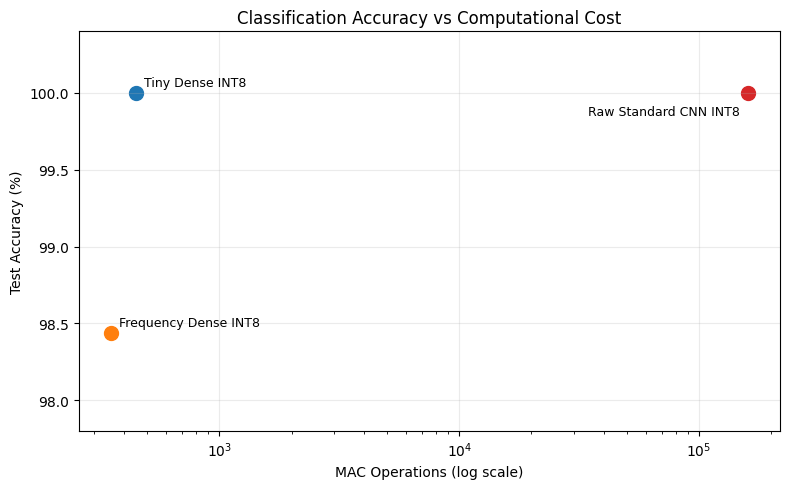

In [76]:
# ============================================================
# FINAL CLEAN FIGURE 1
# Accuracy vs Computational Cost
# ============================================================

fig_df = final_report_df.copy()

label_offsets_acc = {
    "Tiny Dense INT8": (6, 5),
    "Frequency Dense INT8": (6, 5),
    "Raw Depthwise CNN INT8": (6, 7),
    "Raw Standard CNN INT8": (-115, -16)
}

plt.figure(figsize=(8, 5))

for _, row in fig_df.iterrows():

    plt.scatter(
        row["MACs"],
        row["Accuracy (%)"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (
            row["MACs"],
            row["Accuracy (%)"]
        ),
        xytext=label_offsets_acc[row["Model"]],
        textcoords="offset points",
        fontsize=9
    )

plt.xscale("log")

plt.xlabel("MAC Operations (log scale)")
plt.ylabel("Test Accuracy (%)")
plt.title(
    "Classification Accuracy vs Computational Cost"
)

plt.ylim(97.8, 100.4)
plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "accuracy_vs_macs_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [77]:
fig_df = final_report_df.copy()

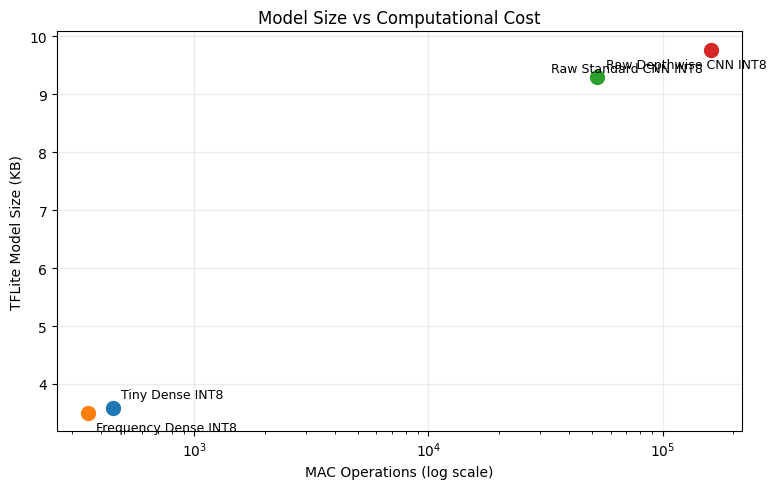

In [78]:
# ============================================================
# FINAL CLEAN FIGURE 2
# Model Size vs Computational Cost
# ============================================================

fig_df = final_report_df.copy()

label_offsets_size = {
    "Tiny Dense INT8": (6, 7),
    "Frequency Dense INT8": (6, -13),
    "Raw Depthwise CNN INT8": (6, 7),
    "Raw Standard CNN INT8": (-115, -16)
}

plt.figure(figsize=(8, 5))

for _, row in fig_df.iterrows():

    plt.scatter(
        row["MACs"],
        row["TFLite Size (KB)"],
        s=100
    )

    plt.annotate(
        row["Model"],
        (
            row["MACs"],
            row["TFLite Size (KB)"]
        ),
        xytext=label_offsets_size[row["Model"]],
        textcoords="offset points",
        fontsize=9
    )

plt.xscale("log")

plt.xlabel("MAC Operations (log scale)")
plt.ylabel("TFLite Model Size (KB)")
plt.title("Model Size vs Computational Cost")

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "model_size_vs_macs_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

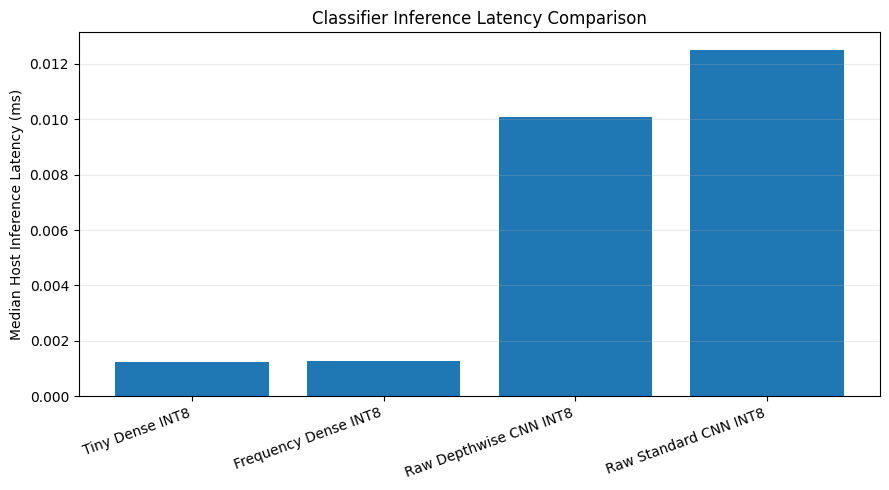

In [79]:
# ============================================================
# FINAL FIGURE 3
# Host Classifier Inference Latency
# ============================================================

fig_df = final_report_df.copy()

plt.figure(figsize=(9, 5))

plt.bar(
    fig_df["Model"],
    fig_df["Host Latency (ms)"]
)

plt.ylabel(
    "Median Host Inference Latency (ms)"
)

plt.title(
    "Classifier Inference Latency Comparison"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "host_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
# ============================================================
# TRAIN RMS-ONLY OPTIMIZED DENSE MODEL
# ============================================================

mode = "rms"

print("\n" + "=" * 60)
print("Training OPTIMIZED RMS model")
print("=" * 60)

data = prepared_data[mode]

tf.keras.utils.set_random_seed(SEED)

rms_model = build_optimized_dense_model(
    mode,
    num_classes=len(class_names)
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

rms_history = rms_model.fit(
    data["X_train"],
    data["y_train"],

    validation_data=(
        data["X_val"],
        data["y_val"]
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        early_stop
    ],

    verbose=0
)

rms_test_loss, rms_test_accuracy = (
    rms_model.evaluate(
        data["X_test"],
        data["y_test"],
        verbose=0
    )
)

print(
    f"Input features: "
    f"{data['X_train'].shape[1]}"
)

print(
    f"Parameters:     "
    f"{rms_model.count_params():,}"
)

print(
    f"Epochs:         "
    f"{len(rms_history.history['loss'])}"
)

print(
    f"Test loss:      "
    f"{rms_test_loss:.4f}"
)

print(
    f"Test accuracy:  "
    f"{rms_test_accuracy:.4f}"
)


Training OPTIMIZED RMS model
Input features: 6
Parameters:     112
Epochs:         150
Test loss:      0.4230
Test accuracy:  0.7500


In [81]:
# ============================================================
# EVALUATE RMS-ONLY MODEL
# ============================================================

rms_prob = rms_model.predict(
    prepared_data["rms"]["X_test"],
    verbose=0
)

rms_pred = np.argmax(
    rms_prob,
    axis=1
)

rms_f1 = f1_score(
    prepared_data["rms"]["y_test"],
    rms_pred,
    average="macro"
)

rms_cm = confusion_matrix(
    prepared_data["rms"]["y_test"],
    rms_pred
)

print("RMS-ONLY RESULTS")
print("=" * 50)

print(
    f"Accuracy: {rms_test_accuracy:.4f}"
)

print(
    f"Macro F1: {rms_f1:.4f}"
)

print("\nConfusion Matrix:")
print(rms_cm)

print("\nClassification Report:")

print(
    classification_report(
        prepared_data["rms"]["y_test"],
        rms_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

RMS-ONLY RESULTS
Accuracy: 0.7500
Macro F1: 0.6667

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [16  0  0  0]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.5000    1.0000    0.6667        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     0.0000    0.0000    0.0000        16

    accuracy                         0.7500        64
   macro avg     0.6250    0.7500    0.6667        64
weighted avg     0.6250    0.7500    0.6667        64



In [82]:
# ============================================================
# TRAIN FFT-BASED DENSE MODEL
# ============================================================

mode = "fft"

print("\n" + "=" * 60)
print("Training FFT-BASED DENSE model")
print("=" * 60)

data = prepared_data[mode]

# Reproducibility
tf.keras.utils.set_random_seed(SEED)

fft_model = build_optimized_dense_model(
    mode,
    num_classes=len(class_names)
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

fft_history = fft_model.fit(
    data["X_train"],
    data["y_train"],

    validation_data=(
        data["X_val"],
        data["y_val"]
    ),

    epochs=150,
    batch_size=16,
    shuffle=True,

    callbacks=[
        early_stop
    ],

    verbose=0
)

fft_test_loss, fft_test_accuracy = fft_model.evaluate(
    data["X_test"],
    data["y_test"],
    verbose=0
)

print(
    f"Input features: "
    f"{data['X_train'].shape[1]}"
)

print(
    f"Parameters:     "
    f"{fft_model.count_params():,}"
)

print(
    f"Epochs:         "
    f"{len(fft_history.history['loss'])}"
)

print(
    f"Test loss:      "
    f"{fft_test_loss:.4f}"
)

print(
    f"Test accuracy:  "
    f"{fft_test_accuracy:.4f}"
)


Training FFT-BASED DENSE model
Input features: 48
Parameters:     3,628
Epochs:         150
Test loss:      0.0004
Test accuracy:  1.0000


In [83]:
# ============================================================
# EVALUATE FFT-BASED DENSE MODEL
# ============================================================

fft_prob = fft_model.predict(
    prepared_data["fft"]["X_test"],
    verbose=0
)

fft_pred = np.argmax(
    fft_prob,
    axis=1
)

fft_f1 = f1_score(
    prepared_data["fft"]["y_test"],
    fft_pred,
    average="macro"
)

fft_cm = confusion_matrix(
    prepared_data["fft"]["y_test"],
    fft_pred
)

print("FFT-BASED RESULTS")
print("=" * 50)

print(
    f"Accuracy: {fft_test_accuracy:.4f}"
)

print(
    f"Macro F1: {fft_f1:.4f}"
)

print("\nConfusion Matrix:")
print(fft_cm)

print("\nClassification Report:")

print(
    classification_report(
        prepared_data["fft"]["y_test"],
        fft_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

FFT-BASED RESULTS
Accuracy: 1.0000
Macro F1: 1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        64
   macro avg     1.0000    1.0000    1.0000        64
weighted avg     1.0000    1.0000    1.0000        64



In [84]:
# ============================================================
# RMS + FFT FEATURES — BLOCKED SPLIT
# ============================================================

def extract_blocked_feature_matrix(
    windows,
    mode
):
    return np.asarray(
        [
            extract_features_configurable(
                window,
                mode=mode,
                fs=100
            )
            for window in windows
        ],
        dtype=np.float32
    )


blocked_feature_data = {}

for mode in ["rms", "fft"]:

    X_train_features = extract_blocked_feature_matrix(
        X_block_train,
        mode
    )

    X_val_features = extract_blocked_feature_matrix(
        X_block_val,
        mode
    )

    X_test_features = extract_blocked_feature_matrix(
        X_block_test,
        mode
    )

    blocked_feature_data[mode] = {
        "X_train": X_train_features,
        "X_val": X_val_features,
        "X_test": X_test_features
    }

    print("\n" + mode.upper())
    print("=" * 40)

    print(
        "Train:",
        X_train_features.shape
    )

    print(
        "Val:  ",
        X_val_features.shape
    )

    print(
        "Test: ",
        X_test_features.shape
    )


RMS
Train: (192, 6)
Val:   (64, 6)
Test:  (64, 6)

FFT
Train: (192, 48)
Val:   (64, 48)
Test:  (64, 48)


In [85]:
# ============================================================
# SCALE RMS + FFT FEATURES — BLOCKED SPLIT
# ============================================================

blocked_feature_scalers = {}

for mode in ["rms", "fft"]:

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        blocked_feature_data[mode]["X_train"]
    )

    X_val_scaled = scaler.transform(
        blocked_feature_data[mode]["X_val"]
    )

    X_test_scaled = scaler.transform(
        blocked_feature_data[mode]["X_test"]
    )

    blocked_feature_scalers[mode] = scaler

    blocked_feature_data[mode][
        "X_train_scaled"
    ] = X_train_scaled.astype(np.float32)

    blocked_feature_data[mode][
        "X_val_scaled"
    ] = X_val_scaled.astype(np.float32)

    blocked_feature_data[mode][
        "X_test_scaled"
    ] = X_test_scaled.astype(np.float32)

    print("\n" + mode.upper())
    print("=" * 40)

    print(
        "Training mean:",
        np.round(
            X_train_scaled.mean(axis=0),
            4
        )
    )

    print(
        "Training std:",
        np.round(
            X_train_scaled.std(axis=0),
            4
        )
    )


RMS
Training mean: [ 0. -0.  0.  0.  0. -0.]
Training std: [1. 1. 1. 1. 1. 1.]

FFT
Training mean: [-0. -0. -0.  0.  0. -0. -0.  0.  0. -0. -0. -0. -0. -0.  0.  0.  0. -0.
 -0.  0. -0. -0. -0. -0. -0. -0.  0.  0. -0.  0. -0. -0.  0. -0. -0. -0.
 -0. -0.  0. -0. -0. -0. -0. -0.  0.  0.  0.  0.]
Training std: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [86]:
# ============================================================
# TRAIN + EVALUATE RMS / FFT — BLOCKED SPLIT
# ============================================================

from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    classification_report
)

blocked_models = {}
blocked_histories = {}
blocked_results = {}

for mode in ["rms", "fft"]:

    print("\n" + "=" * 60)
    print(f"{mode.upper()} DENSE — BLOCKED SPLIT")
    print("=" * 60)

    data = blocked_feature_data[mode]

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    tf.keras.utils.set_random_seed(SEED)

    model = build_optimized_dense_model(
        mode,
        num_classes=len(class_names)
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    history = model.fit(
        data["X_train_scaled"],
        y_block_train,

        validation_data=(
            data["X_val_scaled"],
            y_block_val
        ),

        epochs=150,
        batch_size=16,
        shuffle=True,

        callbacks=[
            early_stop
        ],

        verbose=0
    )

    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------

    test_loss, test_accuracy = model.evaluate(
        data["X_test_scaled"],
        y_block_test,
        verbose=0
    )

    y_prob = model.predict(
        data["X_test_scaled"],
        verbose=0
    )

    y_pred = np.argmax(
        y_prob,
        axis=1
    )

    macro_f1 = f1_score(
        y_block_test,
        y_pred,
        average="macro"
    )

    cm = confusion_matrix(
        y_block_test,
        y_pred
    )

    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    blocked_models[mode] = model
    blocked_histories[mode] = history

    blocked_results[mode] = {
        "accuracy": float(test_accuracy),
        "macro_f1": float(macro_f1),
        "loss": float(test_loss),
        "epochs": len(
            history.history["loss"]
        ),
        "predictions": y_pred
    }

    # --------------------------------------------------------
    # Print
    # --------------------------------------------------------

    print(
        f"Features:   "
        f"{data['X_train_scaled'].shape[1]}"
    )

    print(
        f"Parameters: "
        f"{model.count_params():,}"
    )

    print(
        f"Epochs:     "
        f"{len(history.history['loss'])}"
    )

    print(
        f"Test loss:  "
        f"{test_loss:.4f}"
    )

    print(
        f"Accuracy:   "
        f"{test_accuracy:.4f}"
    )

    print(
        f"Macro F1:   "
        f"{macro_f1:.4f}"
    )

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")

    print(
        classification_report(
            y_block_test,
            y_pred,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


RMS DENSE — BLOCKED SPLIT
Features:   6
Parameters: 112
Epochs:     150
Test loss:  0.3952
Accuracy:   0.7500
Macro F1:   0.6667

Confusion Matrix:
[[ 0  0  0 16]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     0.0000    0.0000    0.0000        16
  left_right     1.0000    1.0000    1.0000        16
        rest     1.0000    1.0000    1.0000        16
     up_down     0.5000    1.0000    0.6667        16

    accuracy                         0.7500        64
   macro avg     0.6250    0.7500    0.6667        64
weighted avg     0.6250    0.7500    0.6667        64


FFT DENSE — BLOCKED SPLIT
Features:   48
Parameters: 3,628
Epochs:     150
Test loss:  0.0012
Accuracy:   1.0000
Macro F1:   1.0000

Confusion Matrix:
[[16  0  0  0]
 [ 0 16  0  0]
 [ 0  0 16  0]
 [ 0  0  0 16]]

Classification Report:
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.

In [87]:
# ============================================================
# FINAL ROBUSTNESS SUMMARY
# Random Split vs Blocked Split
# ============================================================

robustness_results = [
    {
        "model": "1-NN Raw",
        "random_accuracy": knn_accuracy,
        "blocked_accuracy": knn_block_accuracy,
        "random_macro_f1": knn_f1,
        "blocked_macro_f1": knn_block_f1
    },

    {
        "model": "RMS Dense",
        "random_accuracy": rms_test_accuracy,
        "blocked_accuracy":
            blocked_results["rms"]["accuracy"],
        "random_macro_f1": rms_f1,
        "blocked_macro_f1":
            blocked_results["rms"]["macro_f1"]
    },

    {
        "model": "FFT Dense",
        "random_accuracy": fft_test_accuracy,
        "blocked_accuracy":
            blocked_results["fft"]["accuracy"],
        "random_macro_f1": fft_f1,
        "blocked_macro_f1":
            blocked_results["fft"]["macro_f1"]
    },

    {
        "model": "Tiny Dense",
        "random_accuracy":
            final_benchmark_df.loc[
                final_benchmark_df["model"] == "tiny",
                "float_accuracy"
            ].iloc[0],

        "blocked_accuracy":
            tiny_block_accuracy,

        "random_macro_f1":
            final_benchmark_df.loc[
                final_benchmark_df["model"] == "tiny",
                "float_macro_f1"
            ].iloc[0],

        "blocked_macro_f1":
            tiny_block_f1
    }
]

robustness_df = pd.DataFrame(
    robustness_results
)

# Accuracy change:
# positive = performance decreased on blocked split
robustness_df["accuracy_drop"] = (
    robustness_df["random_accuracy"]
    - robustness_df["blocked_accuracy"]
)

robustness_df["macro_f1_drop"] = (
    robustness_df["random_macro_f1"]
    - robustness_df["blocked_macro_f1"]
)

display(
    robustness_df.round(4)
)

,model,random_accuracy,blocked_accuracy,random_macro_f1,blocked_macro_f1,accuracy_drop,macro_f1_drop
0,1-NN Raw,1.00,1.00,1.0000,1.0000,0.0,0.0
1,RMS Dense,0.75,0.75,0.6667,0.6667,0.0,0.0
2,FFT Dense,1.00,1.00,1.0000,1.0000,0.0,0.0
3,Tiny Dense,1.00,1.00,1.0000,1.0000,0.0,0.0


In [88]:
# ============================================================
# FINAL IDEA 3 — FEATURE ENGINEERING COMPARISON
# ============================================================

idea3_results = []

# ------------------------------------------------------------
# RMS-only
# ------------------------------------------------------------

idea3_results.append({
    "Representation": "RMS",
    "Input Features": 6,
    "Architecture": "Dense",
    "Parameters": rms_model.count_params(),
    "Accuracy (%)": rms_test_accuracy * 100,
    "Macro F1": rms_f1
})


# ------------------------------------------------------------
# FFT magnitude
# ------------------------------------------------------------

idea3_results.append({
    "Representation": "FFT",
    "Input Features": 48,
    "Architecture": "Dense",
    "Parameters": fft_model.count_params(),
    "Accuracy (%)": fft_test_accuracy * 100,
    "Macro F1": fft_f1
})


# ------------------------------------------------------------
# Existing engineered-feature models
# ------------------------------------------------------------

for mode in [
    "frequency",
    "tiny",
    "time",
    "combined"
]:

    row = final_benchmark_df[
        final_benchmark_df["model"] == mode
    ].iloc[0]

    idea3_results.append({
        "Representation": mode.capitalize(),
        "Input Features": int(row["features"]),
        "Architecture": "Dense",
        "Parameters": int(row["parameters"]),
        "Accuracy (%)": row["float_accuracy"] * 100,
        "Macro F1": row["float_macro_f1"]
    })


# ------------------------------------------------------------
# Raw signal — Standard CNN
# ------------------------------------------------------------

idea3_results.append({
    "Representation": "Raw Signal",
    "Input Features": 128 * 6,
    "Architecture": "Standard CNN",
    "Parameters": raw_cnn.count_params(),
    "Accuracy (%)": raw_cnn_test_accuracy * 100,
    "Macro F1": raw_cnn_f1
})


# ------------------------------------------------------------
# Raw signal — Depthwise CNN
# ------------------------------------------------------------

idea3_results.append({
    "Representation": "Raw Signal",
    "Input Features": 128 * 6,
    "Architecture": "Depthwise CNN",
    "Parameters": raw_depthwise_cnn.count_params(),
    "Accuracy (%)": raw_depthwise_test_accuracy * 100,
    "Macro F1": raw_depthwise_f1
})


# ------------------------------------------------------------
# Build final table
# ------------------------------------------------------------

idea3_df = pd.DataFrame(
    idea3_results
)

idea3_df = idea3_df.sort_values(
    by=[
        "Accuracy (%)",
        "Parameters"
    ],
    ascending=[
        False,
        True
    ]
).reset_index(drop=True)

idea3_df = idea3_df.round({
    "Accuracy (%)": 2,
    "Macro F1": 4
})

display(idea3_df)

,Representation,Input Features,Architecture,Parameters,Accuracy (%),Macro F1
0,Tiny,18,Dense,476,100.00,1.0000
1,Raw Signal,768,Standard CNN,2660,100.00,1.0000
2,Time,30,Dense,2764,100.00,1.0000
3,FFT,48,Dense,3628,100.00,1.0000
4,Combined,42,Dense,4964,100.00,1.0000
5,Frequency,12,Dense,380,98.44,0.9844
6,RMS,6,Dense,112,75.00,0.6667
7,Raw Signal,768,Depthwise CNN,1330,12.50,0.1111


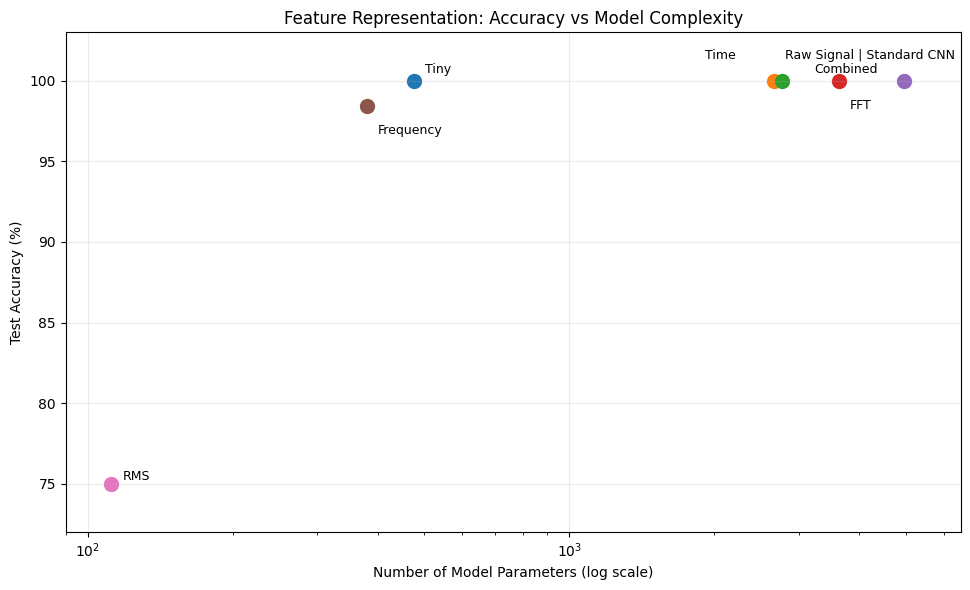

In [89]:
# ============================================================
# FINAL IDEA 3 FIGURE — REPORT VERSION
# Accuracy vs Model Parameters
# ============================================================

plt.figure(figsize=(10, 6))

label_positions = {
    "RMS": (8, 5),
    "Frequency": (8, -18),
    "Tiny": (8, 8),

    "Raw Signal | Depthwise CNN": (8, -18),
    "Raw Signal | Standard CNN": (8, 18),

    "Time": (-55, 18),
    "FFT": (8, -18),
    "Combined": (-65, 8)
}

for _, row in idea3_df.iterrows():

    if row["Representation"] == "Raw Signal":
        label = (
            f"Raw Signal | "
            f"{row['Architecture']}"
        )
    else:
        label = row["Representation"]

    plt.scatter(
        row["Parameters"],
        row["Accuracy (%)"],
        s=100
    )

    plt.annotate(
        label,
        (
            row["Parameters"],
            row["Accuracy (%)"]
        ),
        xytext=label_positions[label],
        textcoords="offset points",
        fontsize=9,
        va="center"
    )


plt.xscale("log")

plt.xlabel(
    "Number of Model Parameters (log scale)"
)

plt.ylabel(
    "Test Accuracy (%)"
)

plt.title(
    "Feature Representation: Accuracy vs Model Complexity"
)

# Give annotations more vertical room
plt.ylim(72, 103)

# Give Combined more room on the right
plt.xlim(90, 6500)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "idea3_accuracy_vs_parameters_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
# ============================================================
# SAVE FINAL IDEA 3 RESULTS
# ============================================================

idea3_df.to_csv(
    "idea3_feature_engineering_results.csv",
    index=False
)

robustness_df.to_csv(
    "idea3_robustness_results.csv",
    index=False
)

print("Saved:")
print("idea3_feature_engineering_results.csv")
print("idea3_robustness_results.csv")
print("idea3_accuracy_vs_parameters_final.png")

Saved:
idea3_feature_engineering_results.csv
idea3_robustness_results.csv
idea3_accuracy_vs_parameters_final.png


In [91]:
# ============================================================
# EXPORT TINY INT8 MODEL AS C HEADER
# ============================================================

model_bytes = tflite_int8_models["tiny"]["model"]

with open("tiny_model.h", "w") as f:

    f.write("#ifndef TINY_MODEL_H\n")
    f.write("#define TINY_MODEL_H\n\n")

    f.write(
        "const unsigned char tiny_model[] = {\n"
    )

    for i, byte in enumerate(model_bytes):

        if i % 12 == 0:
            f.write("    ")

        f.write(
            f"0x{byte:02x}"
        )

        if i != len(model_bytes) - 1:
            f.write(", ")

        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write("\n};\n\n")

    f.write(
        f"const unsigned int tiny_model_len = "
        f"{len(model_bytes)};\n"
    )

    f.write("\n#endif\n")


print("tiny_model.h created")
print("Model bytes:", len(model_bytes))

tiny_model.h created
Model bytes: 3680


In [92]:
# ============================================================
# EXPORT TINY STANDARD SCALER AS C HEADER
# ============================================================

tiny_scaler = scalers["tiny"]

num_features = len(
    tiny_scaler.mean_
)

with open("tiny_scaler.h", "w") as f:

    f.write("#ifndef TINY_SCALER_H\n")
    f.write("#define TINY_SCALER_H\n\n")

    f.write(
        f"const float tiny_mean[{num_features}] = {{\n"
    )

    for i, value in enumerate(
        tiny_scaler.mean_
    ):

        f.write(
            f"    {value:.10e}f"
        )

        if i < num_features - 1:
            f.write(",")

        f.write("\n")

    f.write("};\n\n")

    f.write(
        f"const float tiny_scale[{num_features}] = {{\n"
    )

    for i, value in enumerate(
        tiny_scaler.scale_
    ):

        f.write(
            f"    {value:.10e}f"
        )

        if i < num_features - 1:
            f.write(",")

        f.write("\n")

    f.write("};\n\n")

    f.write("#endif\n")


print("tiny_scaler.h created")
print(
    "Number of features:",
    num_features
)

tiny_scaler.h created
Number of features: 18


In [93]:
# ============================================================
# EXPORT RAW DEPTHWISE CNN INT8 FOR ARDUINO
# ============================================================

depthwise_int8_bytes = depthwise_int8_tflite

print(
    "Depthwise INT8 TFLite size:",
    len(depthwise_int8_bytes),
    "bytes"
)

with open(
    "depthwise_model.h",
    "w"
) as f:

    f.write(
        "#ifndef DEPTHWISE_MODEL_H\n"
    )

    f.write(
        "#define DEPTHWISE_MODEL_H\n\n"
    )

    f.write(
        "#include <stdint.h>\n\n"
    )

    f.write(
        "const unsigned char "
        "depthwise_model[] = {\n"
    )

    for i, byte in enumerate(
        depthwise_int8_bytes
    ):

        if i % 12 == 0:
            f.write("    ")

        f.write(
            f"0x{byte:02x}"
        )

        if i != len(
            depthwise_int8_bytes
        ) - 1:
            f.write(", ")

        if (i + 1) % 12 == 0:
            f.write("\n")

    f.write(
        "\n};\n\n"
    )

    f.write(
        "const unsigned int "
        "depthwise_model_len = "
        f"{len(depthwise_int8_bytes)};\n\n"
    )

    f.write(
        "#endif\n"
    )

print(
    "depthwise_model.h created"
)

print(
    "Model bytes:",
    len(depthwise_int8_bytes)
)

Depthwise INT8 TFLite size: 9512 bytes
depthwise_model.h created
Model bytes: 9512


In [94]:
# ============================================================
# INSPECT RAW DEPTHWISE CNN INT8 MODEL
# ============================================================

import tensorflow as tf
import numpy as np

depthwise_interpreter = tf.lite.Interpreter(
    model_content=depthwise_int8_tflite
)

depthwise_interpreter.allocate_tensors()

input_details = depthwise_interpreter.get_input_details()
output_details = depthwise_interpreter.get_output_details()

print("=" * 60)
print("RAW DEPTHWISE CNN INT8 — TENSOR DETAILS")
print("=" * 60)

print("\nINPUT")
print("-" * 60)

print(
    "Shape:",
    input_details[0]["shape"]
)

print(
    "dtype:",
    input_details[0]["dtype"]
)

print(
    "Quantization:",
    input_details[0]["quantization"]
)

print(
    "Scale:",
    input_details[0]["quantization"][0]
)

print(
    "Zero point:",
    input_details[0]["quantization"][1]
)

print("\nOUTPUT")
print("-" * 60)

print(
    "Shape:",
    output_details[0]["shape"]
)

print(
    "dtype:",
    output_details[0]["dtype"]
)

print(
    "Quantization:",
    output_details[0]["quantization"]
)

print(
    "Scale:",
    output_details[0]["quantization"][0]
)

print(
    "Zero point:",
    output_details[0]["quantization"][1]
)

print("\nMODEL")
print("-" * 60)

print(
    "Model bytes:",
    len(depthwise_int8_tflite)
)

print(
    "Input elements:",
    np.prod(input_details[0]["shape"])
)

print(
    "Output elements:",
    np.prod(output_details[0]["shape"])
)

RAW DEPTHWISE CNN INT8 — TENSOR DETAILS

INPUT
------------------------------------------------------------
Shape: [  1 128   6]
dtype: <class 'numpy.int8'>
Quantization: (0.04553470015525818, 13)
Scale: 0.04553470015525818
Zero point: 13

OUTPUT
------------------------------------------------------------
Shape: [1 4]
dtype: <class 'numpy.int8'>
Quantization: (0.00390625, -128)
Scale: 0.00390625
Zero point: -128

MODEL
------------------------------------------------------------
Model bytes: 9512
Input elements: 768
Output elements: 4


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [95]:
# ============================================================
# LIST TFLITE OPERATORS — RAW DEPTHWISE CNN INT8
# ============================================================

import tensorflow as tf

interpreter = tf.lite.Interpreter(
    model_content=depthwise_int8_tflite
)

interpreter.allocate_tensors()

ops = interpreter._get_ops_details()

print("=" * 60)
print("RAW DEPTHWISE CNN INT8 — OPERATORS")
print("=" * 60)

unique_ops = []

for i, op in enumerate(ops):

    op_name = op["op_name"]

    print(
        f"{i:2d} -> {op_name}"
    )

    if op_name not in unique_ops:
        unique_ops.append(op_name)


print("\n" + "=" * 60)
print("UNIQUE OPERATORS")
print("=" * 60)

for op_name in unique_ops:
    print(op_name)

print(
    "\nTotal operator nodes:",
    len(ops)
)

print(
    "Unique operator types:",
    len(unique_ops)
)

RAW DEPTHWISE CNN INT8 — OPERATORS
 0 -> EXPAND_DIMS
 1 -> DEPTHWISE_CONV_2D
 2 -> CONV_2D
 3 -> RESHAPE
 4 -> EXPAND_DIMS
 5 -> MAX_POOL_2D
 6 -> RESHAPE
 7 -> EXPAND_DIMS
 8 -> DEPTHWISE_CONV_2D
 9 -> CONV_2D
10 -> RESHAPE
11 -> MEAN
12 -> FULLY_CONNECTED
13 -> FULLY_CONNECTED
14 -> SOFTMAX
15 -> DELEGATE
16 -> DELEGATE
17 -> DELEGATE

UNIQUE OPERATORS
EXPAND_DIMS
DEPTHWISE_CONV_2D
CONV_2D
RESHAPE
MAX_POOL_2D
MEAN
FULLY_CONNECTED
SOFTMAX
DELEGATE

Total operator nodes: 18
Unique operator types: 9


In [96]:
# ============================================================
# EXPORT RAW-SIGNAL TRAINING NORMALIZATION FOR ARDUINO
# ============================================================

import numpy as np

raw_mean_deploy = X_raw_train.mean(
    axis=(0, 1)
).astype(np.float32)

raw_std_deploy = X_raw_train.std(
    axis=(0, 1)
).astype(np.float32)

raw_std_deploy = np.where(
    raw_std_deploy < 1e-8,
    1.0,
    raw_std_deploy
).astype(np.float32)

print("RAW MEAN:")
print(raw_mean_deploy)

print("\nRAW STD:")
print(raw_std_deploy)

with open("raw_scaler.h", "w") as f:

    f.write("#ifndef RAW_SCALER_H\n")
    f.write("#define RAW_SCALER_H\n\n")

    f.write("const float raw_mean[6] = {\n")

    for i, value in enumerate(raw_mean_deploy):
        comma = "," if i < 5 else ""
        f.write(
            f"    {value:.10e}f{comma}\n"
        )

    f.write("};\n\n")

    f.write("const float raw_std[6] = {\n")

    for i, value in enumerate(raw_std_deploy):
        comma = "," if i < 5 else ""
        f.write(
            f"    {value:.10e}f{comma}\n"
        )

    f.write("};\n\n")
    f.write("#endif\n")

print("\nSaved: raw_scaler.h")

RAW MEAN:
[-0.00392063 -0.09010717 -0.13027927 -1.5915517   0.14677145 -0.04352759]

RAW STD:
[ 0.25857764  0.60423815  0.75048846 18.721096   17.978252   56.139603  ]

Saved: raw_scaler.h


Upload these 5 files:

1. Circle(6).csv
2. Left-right(6).csv
3. Rest(6).csv
4. Up-down(6).csv
5. depthwise_model_extracted.tflite



Saving Circle.csv to Circle (1).csv
Saving depthwise_model_extracted.tflite to depthwise_model_extracted (1).tflite
Saving Left-right.csv to Left-right (1).csv
Saving Rest.csv to Rest (1).csv
Saving Up-down.csv to Up-down (1).csv

Detected files:
------------------------------
Circle     : Circle (1).csv
Left-right : Left-right (1).csv
Rest       : Rest (1).csv
Up-down    : Up-down (1).csv
Model      : depthwise_model_extracted (1).tflite

DATASET SHAPES
Circle     : (10240, 6)
Left-right : (10240, 6)
Rest       : (10240, 6)
Up-down    : (10240, 6)

WINDOW COUNTS
Circle     : 80
Left-right : 80
Rest       : 80
Up-down    : 80
TOTAL      : 320

MODEL INFORMATION
Input shape: [  1 128   6]
Input dtype: <class 'numpy.int8'>
Output shape: [1 4]
Output dtype: <class 'numpy.int8'>

Input scale: 0.04553470015525818
Input zero point: 13
Output scale: 0.00390625
Output zero point: -128


TEST 8A RESULTS
Overall Accuracy: 100.00%

PER-CLASS ACCURACY
----------------------------------------
circl

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


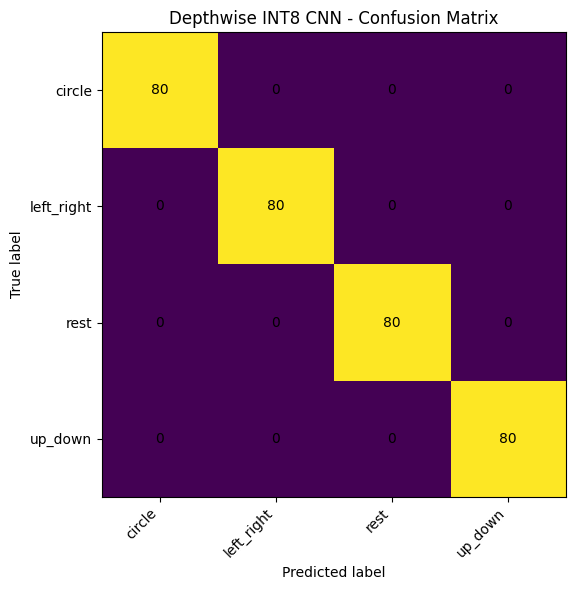


DEPTHWISE INT8 BENCHMARK SUMMARY
Windows evaluated: 320
Correct predictions: 320
Incorrect predictions: 0
Accuracy: 100.00%
Average confidence: 0.996094

Arduino measured inference latency from Test 7:
~20.2 ms per inference

TEST 8A COMPLETE


In [97]:
# ============================================================
# TEST 8A
# FULL DATASET ACCURACY BENCHMARK
# Depthwise CNN INT8
#
# Dataset:
# Circle
# Left-right
# Rest
# Up-down
#
# Window:
# 128 x 6
#
# Output:
# - Overall accuracy
# - Per-class accuracy
# - Confusion matrix
# - Average confidence
# ============================================================

import numpy as np
import pandas as pd
import tensorflow as tf

from google.colab import files
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


# ============================================================
# CONFIGURATION
# ============================================================

WINDOW_SIZE = 128
NUM_CHANNELS = 6
NUM_CLASSES = 4

CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]

EXPECTED_COLUMNS = [
    "aX",
    "aY",
    "aZ",
    "gX",
    "gY",
    "gZ"
]


# ============================================================
# SAME RAW SCALER USED ON ARDUINO
# ============================================================

RAW_MEAN = np.array([
    -3.9206347428e-03,
    -9.0107172728e-02,
    -1.3027927279e-01,
    -1.5915516615e+00,
     1.4677144587e-01,
    -4.3527591974e-02
], dtype=np.float32)


RAW_STD = np.array([
    2.5857764482e-01,
    6.0423815250e-01,
    7.5048846006e-01,
    1.8721096039e+01,
    1.7978252411e+01,
    5.6139602661e+01
], dtype=np.float32)


# ============================================================
# UPLOAD FILES
# ============================================================

print("Upload these 5 files:")
print()
print("1. Circle(6).csv")
print("2. Left-right(6).csv")
print("3. Rest(6).csv")
print("4. Up-down(6).csv")
print("5. depthwise_model_extracted.tflite")
print()

uploaded = files.upload()


# ============================================================
# FIND FILENAMES AUTOMATICALLY
# ============================================================

def find_uploaded_file(keyword, extension):
    for filename in uploaded.keys():
        if (
            keyword.lower() in filename.lower()
            and filename.lower().endswith(extension)
        ):
            return filename

    raise FileNotFoundError(
        f"Could not find {keyword} {extension}"
    )


circle_file = find_uploaded_file(
    "circle",
    ".csv"
)

left_right_file = find_uploaded_file(
    "left-right",
    ".csv"
)

rest_file = find_uploaded_file(
    "rest",
    ".csv"
)

up_down_file = find_uploaded_file(
    "up-down",
    ".csv"
)

model_file = find_uploaded_file(
    "depthwise",
    ".tflite"
)


print()
print("Detected files:")
print("------------------------------")
print("Circle     :", circle_file)
print("Left-right :", left_right_file)
print("Rest       :", rest_file)
print("Up-down    :", up_down_file)
print("Model      :", model_file)


# ============================================================
# ROBUST CSV READER
#
# Circle / Left-right:
#
# aX,aY,aZ,gX,gY,gZ
# ...
#
# Rest / Up-down currently contain lines like:
#
# "aX,aY,aZ,gX,gY,gZ"
# "0.01,..."
#
# This function handles BOTH formats.
# ============================================================

def load_imu_csv(filename):

    # --------------------------------------------------------
    # First try normal CSV parsing
    # --------------------------------------------------------

    df = pd.read_csv(filename)

    if (
        df.shape[1] == 6
        and list(df.columns) == EXPECTED_COLUMNS
    ):
        result = df.copy()

    else:

        # ----------------------------------------------------
        # Handle quoted single-column representation
        # ----------------------------------------------------

        rows = []

        with open(
            filename,
            "r",
            encoding="utf-8-sig"
        ) as f:

            lines = f.readlines()

        for line in lines:

            line = line.strip()

            if not line:
                continue

            # Remove outer quotation marks
            if (
                line.startswith('"')
                and
                line.endswith('"')
            ):
                line = line[1:-1]

            parts = line.split(",")

            if len(parts) != 6:
                continue

            # Skip header
            if parts[0] == "aX":
                continue

            try:

                row = [
                    float(x)
                    for x in parts
                ]

                rows.append(row)

            except ValueError:
                continue


        result = pd.DataFrame(
            rows,
            columns=EXPECTED_COLUMNS
        )


    # --------------------------------------------------------
    # Force numeric
    # --------------------------------------------------------

    for column in EXPECTED_COLUMNS:

        result[column] = pd.to_numeric(
            result[column],
            errors="coerce"
        )


    result = result.dropna().reset_index(
        drop=True
    )


    return result


# ============================================================
# LOAD DATASET
# ============================================================

circle_df = load_imu_csv(
    circle_file
)

left_right_df = load_imu_csv(
    left_right_file
)

rest_df = load_imu_csv(
    rest_file
)

up_down_df = load_imu_csv(
    up_down_file
)


print()
print("DATASET SHAPES")
print("========================================")

print(
    "Circle     :",
    circle_df.shape
)

print(
    "Left-right :",
    left_right_df.shape
)

print(
    "Rest       :",
    rest_df.shape
)

print(
    "Up-down    :",
    up_down_df.shape
)


# ============================================================
# CREATE NON-OVERLAPPING 128x6 WINDOWS
# ============================================================

def create_windows(
    df,
    label
):

    values = df[
        EXPECTED_COLUMNS
    ].values.astype(
        np.float32
    )


    number_of_windows = (
        len(values)
        //
        WINDOW_SIZE
    )


    X = []
    y = []


    for i in range(
        number_of_windows
    ):

        start = (
            i
            *
            WINDOW_SIZE
        )

        end = (
            start
            +
            WINDOW_SIZE
        )


        window = values[
            start:end
        ]


        if window.shape != (
            WINDOW_SIZE,
            NUM_CHANNELS
        ):
            continue


        X.append(
            window
        )

        y.append(
            label
        )


    return (
        np.array(
            X,
            dtype=np.float32
        ),
        np.array(
            y,
            dtype=np.int32
        )
    )


X_circle, y_circle = create_windows(
    circle_df,
    0
)

X_left_right, y_left_right = create_windows(
    left_right_df,
    1
)

X_rest, y_rest = create_windows(
    rest_df,
    2
)

X_up_down, y_up_down = create_windows(
    up_down_df,
    3
)


# ============================================================
# COMBINE DATASET
# ============================================================

X = np.concatenate([
    X_circle,
    X_left_right,
    X_rest,
    X_up_down
])

y = np.concatenate([
    y_circle,
    y_left_right,
    y_rest,
    y_up_down
])


print()
print("WINDOW COUNTS")
print("========================================")

print(
    "Circle     :",
    len(X_circle)
)

print(
    "Left-right :",
    len(X_left_right)
)

print(
    "Rest       :",
    len(X_rest)
)

print(
    "Up-down    :",
    len(X_up_down)
)

print(
    "TOTAL      :",
    len(X)
)


# ============================================================
# LOAD TFLITE MODEL
# ============================================================

interpreter = tf.lite.Interpreter(
    model_path=model_file
)

interpreter.allocate_tensors()


input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()


input_info = input_details[0]
output_info = output_details[0]


print()
print("MODEL INFORMATION")
print("========================================")

print(
    "Input shape:",
    input_info["shape"]
)

print(
    "Input dtype:",
    input_info["dtype"]
)

print(
    "Output shape:",
    output_info["shape"]
)

print(
    "Output dtype:",
    output_info["dtype"]
)


input_scale, input_zero_point = (
    input_info["quantization"]
)

output_scale, output_zero_point = (
    output_info["quantization"]
)


print()
print(
    "Input scale:",
    input_scale
)

print(
    "Input zero point:",
    input_zero_point
)

print(
    "Output scale:",
    output_scale
)

print(
    "Output zero point:",
    output_zero_point
)


# ============================================================
# VALIDATE EXPECTED MODEL SHAPE
# ============================================================

expected_input_shape = (
    1,
    128,
    6
)


actual_input_shape = tuple(
    input_info["shape"]
)


if (
    actual_input_shape
    !=
    expected_input_shape
):
    raise RuntimeError(
        f"Unexpected model input shape: "
        f"{actual_input_shape}"
    )


# ============================================================
# INFERENCE FUNCTION
# ============================================================

def run_inference(
    raw_window
):

    # --------------------------------------------------------
    # SAME STANDARDIZATION AS ARDUINO
    # --------------------------------------------------------

    standardized = (
        raw_window
        -
        RAW_MEAN
    ) / RAW_STD


    # --------------------------------------------------------
    # INT8 QUANTIZATION
    # --------------------------------------------------------

    quantized = np.round(
        standardized
        /
        input_scale
        +
        input_zero_point
    )


    quantized = np.clip(
        quantized,
        -128,
        127
    ).astype(
        np.int8
    )


    quantized = np.expand_dims(
        quantized,
        axis=0
    )


    interpreter.set_tensor(
        input_info["index"],
        quantized
    )


    interpreter.invoke()


    raw_output = interpreter.get_tensor(
        output_info["index"]
    )[0]


    # --------------------------------------------------------
    # DEQUANTIZE OUTPUT
    # --------------------------------------------------------

    scores = (
        raw_output.astype(
            np.float32
        )
        -
        output_zero_point
    ) * output_scale


    predicted_class = int(
        np.argmax(
            scores
        )
    )


    confidence = float(
        scores[
            predicted_class
        ]
    )


    return (
        predicted_class,
        confidence,
        scores
    )


# ============================================================
# FULL DATASET INFERENCE
# ============================================================

predictions = []

confidences = []

all_scores = []


for i in range(
    len(X)
):

    pred, conf, scores = run_inference(
        X[i]
    )


    predictions.append(
        pred
    )

    confidences.append(
        conf
    )

    all_scores.append(
        scores
    )


predictions = np.array(
    predictions
)

confidences = np.array(
    confidences
)

all_scores = np.array(
    all_scores
)


# ============================================================
# ACCURACY
# ============================================================

accuracy = accuracy_score(
    y,
    predictions
)


print()
print()
print("========================================")
print("TEST 8A RESULTS")
print("========================================")

print(
    f"Overall Accuracy: "
    f"{accuracy * 100:.2f}%"
)


# ============================================================
# PER-CLASS ACCURACY
# ============================================================

print()
print("PER-CLASS ACCURACY")
print("----------------------------------------")


for class_index, class_name in enumerate(
    CLASS_NAMES
):

    mask = (
        y
        ==
        class_index
    )


    total = int(
        np.sum(
            mask
        )
    )


    correct = int(
        np.sum(
            predictions[mask]
            ==
            class_index
        )
    )


    class_accuracy = (
        correct
        /
        total
        if total
        else 0
    )


    print(
        f"{class_name:12s}: "
        f"{correct:3d}/{total:3d} "
        f"({class_accuracy * 100:6.2f}%)"
    )


# ============================================================
# AVERAGE CONFIDENCE
# ============================================================

print()
print(
    "Average confidence:",
    f"{np.mean(confidences):.6f}"
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y,
    predictions,
    labels=[
        0,
        1,
        2,
        3
    ]
)


print()
print("CONFUSION MATRIX")
print("----------------------------------------")

print(cm)


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print()
print("CLASSIFICATION REPORT")
print("----------------------------------------")

print(
    classification_report(
        y,
        predictions,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX FIGURE
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)


image = ax.imshow(
    cm
)


ax.set_xticks(
    np.arange(
        NUM_CLASSES
    )
)

ax.set_yticks(
    np.arange(
        NUM_CLASSES
    )
)


ax.set_xticklabels(
    CLASS_NAMES
)

ax.set_yticklabels(
    CLASS_NAMES
)


plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)


ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "Depthwise INT8 CNN - Confusion Matrix"
)


for i in range(
    NUM_CLASSES
):

    for j in range(
        NUM_CLASSES
    ):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


fig.tight_layout()

plt.show()


# ============================================================
# FINAL SUMMARY
# ============================================================

print()
print("========================================")
print("DEPTHWISE INT8 BENCHMARK SUMMARY")
print("========================================")

print(
    "Windows evaluated:",
    len(X)
)

print(
    "Correct predictions:",
    int(
        np.sum(
            y
            ==
            predictions
        )
    )
)

print(
    "Incorrect predictions:",
    int(
        np.sum(
            y
            !=
            predictions
        )
    )
)

print(
    f"Accuracy: "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Average confidence: "
    f"{np.mean(confidences):.6f}"
)

print()
print(
    "Arduino measured inference latency "
    "from Test 7:"
)

print(
    "~20.2 ms per inference"
)

print()
print(
    "TEST 8A COMPLETE"
)

In [98]:
# ============================================================
# FIXED STRATIFIED TRAIN / VAL / TEST SPLIT
# Dataset:
# Circle / Left-right / Rest / Up-down
# Window size: 128 x 6
#
# Split:
# 80% Train
# 10% Validation
# 10% Test
# ============================================================

import numpy as np

from sklearn.model_selection import train_test_split
from collections import Counter


# ------------------------------------------------------------
# Expected variables from previous cell:
#
# X -> shape: (320, 128, 6)
# y -> shape: (320,)
#
# Labels:
# 0 = circle
# 1 = left_right
# 2 = rest
# 3 = up_down
# ------------------------------------------------------------


RANDOM_STATE = 42


# ============================================================
# SAFETY CHECK
# ============================================================

print("Original X shape:", X.shape)
print("Original y shape:", y.shape)

assert X.ndim == 3
assert X.shape[1] == 128
assert X.shape[2] == 6
assert len(X) == len(y)


print()
print("Original class distribution:")
print(Counter(y))


# ============================================================
# STEP 1
# 80% TRAIN
# 20% TEMPORARY
#
# Temporary set will later be split equally into:
# 10% Validation
# 10% Test
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
    shuffle=True
)


# ============================================================
# STEP 2
# Split temporary set into:
#
# 50% validation
# 50% test
#
# Since temporary = 20% of full dataset:
#
# validation = 10%
# test       = 10%
# ============================================================

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
    shuffle=True
)


# ============================================================
# RESULTS
# ============================================================

print()
print("=" * 50)
print("FINAL DATASET SPLIT")
print("=" * 50)

print()
print("TRAIN")
print("----------------------------------------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("Classes:", Counter(y_train))

print()
print("VALIDATION")
print("----------------------------------------")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("Classes:", Counter(y_val))

print()
print("TEST")
print("----------------------------------------")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)
print("Classes:", Counter(y_test))


# ============================================================
# EXPECTED COUNTS
# ============================================================

print()
print("=" * 50)
print("EXPECTED BALANCED COUNTS")
print("=" * 50)

print(
    "Total windows:",
    len(X)
)

print(
    "Training windows:",
    len(X_train)
)

print(
    "Validation windows:",
    len(X_val)
)

print(
    "Test windows:",
    len(X_test)
)


# ============================================================
# VERIFY NO INDEX-LEVEL OVERLAP
#
# Since arrays themselves don't retain original indices,
# we create unique fingerprints for each window.
# ============================================================

def window_fingerprint(window):
    return window.tobytes()


train_fingerprints = {
    window_fingerprint(w)
    for w in X_train
}

val_fingerprints = {
    window_fingerprint(w)
    for w in X_val
}

test_fingerprints = {
    window_fingerprint(w)
    for w in X_test
}


train_val_overlap = len(
    train_fingerprints
    &
    val_fingerprints
)

train_test_overlap = len(
    train_fingerprints
    &
    test_fingerprints
)

val_test_overlap = len(
    val_fingerprints
    &
    test_fingerprints
)


print()
print("=" * 50)
print("OVERLAP CHECK")
print("=" * 50)

print(
    "Train / Validation overlap:",
    train_val_overlap
)

print(
    "Train / Test overlap:",
    train_test_overlap
)

print(
    "Validation / Test overlap:",
    val_test_overlap
)


# ============================================================
# SAVE SPLIT
#
# Important:
# From this point onward, ALL models should use this exact split
# for a fair benchmark.
# ============================================================

np.savez_compressed(
    "fixed_tinyml_split_80_10_10.npz",

    X_train=X_train,
    y_train=y_train,

    X_val=X_val,
    y_val=y_val,

    X_test=X_test,
    y_test=y_test
)


print()
print("=" * 50)
print("SPLIT SAVED")
print("=" * 50)

print(
    "fixed_tinyml_split_80_10_10.npz"
)


# ============================================================
# CLASS LABEL REFERENCE
# ============================================================

CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]


print()
print("Class mapping:")

for i, name in enumerate(
    CLASS_NAMES
):
    print(
        i,
        "->",
        name
    )


print()
print("DONE")

Original X shape: (320, 128, 6)
Original y shape: (320,)

Original class distribution:
Counter({np.int32(0): 80, np.int32(1): 80, np.int32(2): 80, np.int32(3): 80})

FINAL DATASET SPLIT

TRAIN
----------------------------------------
X_train: (256, 128, 6)
y_train: (256,)
Classes: Counter({np.int32(3): 64, np.int32(0): 64, np.int32(2): 64, np.int32(1): 64})

VALIDATION
----------------------------------------
X_val: (32, 128, 6)
y_val: (32,)
Classes: Counter({np.int32(0): 8, np.int32(3): 8, np.int32(1): 8, np.int32(2): 8})

TEST
----------------------------------------
X_test: (32, 128, 6)
y_test: (32,)
Classes: Counter({np.int32(2): 8, np.int32(0): 8, np.int32(1): 8, np.int32(3): 8})

EXPECTED BALANCED COUNTS
Total windows: 320
Training windows: 256
Validation windows: 32
Test windows: 32

OVERLAP CHECK
Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0

SPLIT SAVED
fixed_tinyml_split_80_10_10.npz

Class mapping:
0 -> circle
1 -> left_right
2 -> rest
3 

MODEL 1 — DENSE NETWORK BASELINE

Available arrays:
['X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test']

DATASET
-------------------------------------------------------
X_train: (256, 128, 6)
y_train: (256,)
X_val  : (32, 128, 6)
y_val  : (32,)
X_test : (32, 128, 6)
y_test : (32,)

Input shape : (128, 6)
Classes     : ['circle', 'left_right', 'rest', 'up_down']

TRAIN-ONLY NORMALIZATION
-------------------------------------------------------
Mean:
[ 1.1208049e-03 -8.2654111e-02 -1.2643310e-01 -1.5734744e+00
  1.5375391e-01  2.9320249e-01]

Std:
[ 0.2609839   0.60880005  0.7468958  19.054401   17.840723   56.507168  ]

MODEL ARCHITECTURE
-------------------------------------------------------


Model: "Dense_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,428 (200.89 KB)

 Trainable params: 51,428 (200.89 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 51428

TRAINING
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9062 - loss: 0.3915 - val_accuracy: 1.0000 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0079 - val_accuracy: 1.0000 - val_loss: 0.0037 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 1.0000 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 8.3187e-04 - val_accuracy: 1.0000 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 6.9758e-04 - val_accuracy: 1.0000 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

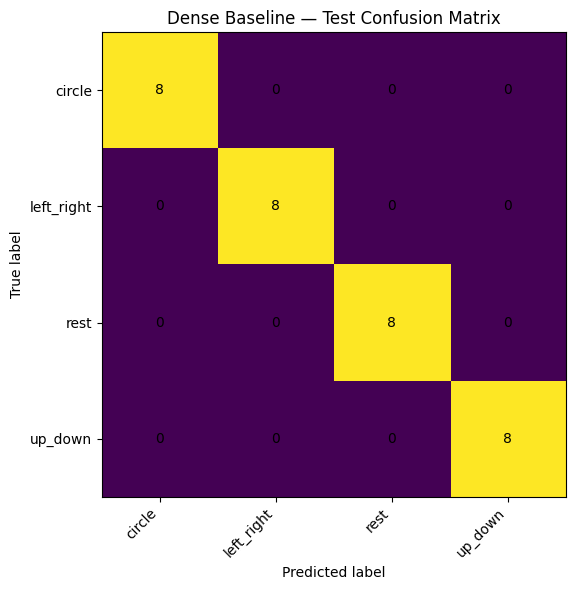

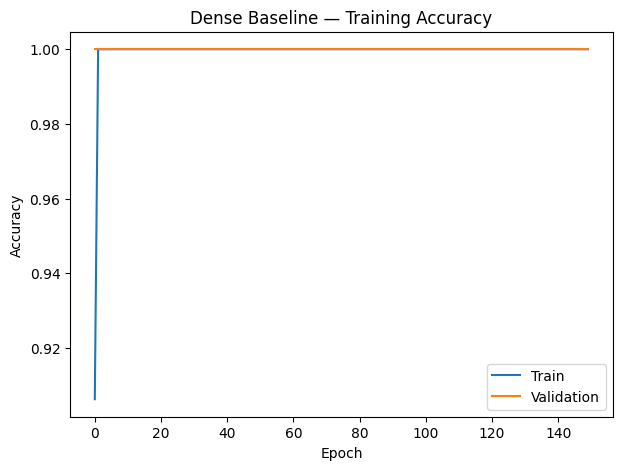

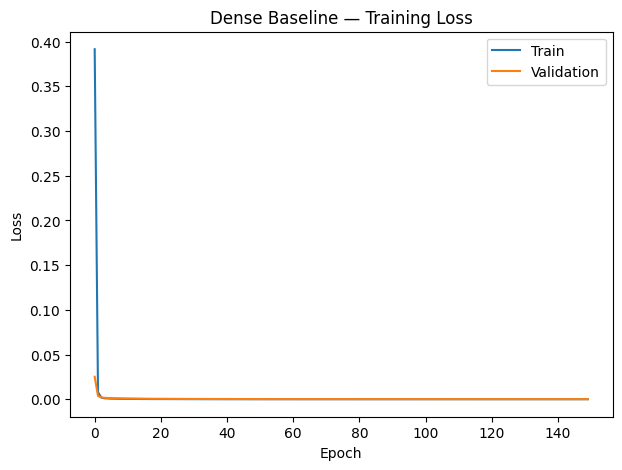

Saved artifact at '/tmp/tmpm9yqkite'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217100948176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217097468816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217097477264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109573712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109574480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109576784: TensorSpec(shape=(), dtype=tf.resource, name=None)

MODEL SIZE
-------------------------------------------------------
Keras model : 629.77 KB
TFLite FP32 : 203.93 KB

HOST TFLITE LATENCY
-------------------------------------------------------
0.0102 ms / inference
(Host measurement — NOT Arduino latency)


MODEL 1 — DENSE BASELINE BENCHMARK
Test sam

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [99]:
# ============================================================
# MODEL 1 — DENSE NETWORK BASELINE
# Fixed 80/10/10 TinyML benchmark split
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os
import time

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 55)
print("MODEL 1 — DENSE NETWORK BASELINE")
print("=" * 55)


# ------------------------------------------------------------
# 2. Load the FIXED benchmark split
# ------------------------------------------------------------

split_file = "fixed_tinyml_split_80_10_10.npz"

if not os.path.exists(split_file):
    raise FileNotFoundError(
        f"{split_file} not found. Run the fixed dataset split cell first."
    )

data = np.load(split_file)

print("\nAvailable arrays:")
print(data.files)


# Automatically handle common naming conventions
def get_array(possible_names):
    for name in possible_names:
        if name in data.files:
            return data[name]

    raise KeyError(
        f"Could not find any of these arrays: {possible_names}\n"
        f"Available arrays: {data.files}"
    )


X_train = get_array(["X_train", "x_train"])
y_train = get_array(["y_train", "Y_train"])

X_val = get_array(["X_val", "x_val", "X_validation"])
y_val = get_array(["y_val", "Y_val", "y_validation"])

X_test = get_array(["X_test", "x_test"])
y_test = get_array(["y_test", "Y_test"])


print("\nDATASET")
print("-" * 55)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ------------------------------------------------------------
# 3. Dataset constants
# ------------------------------------------------------------

NUM_CLASSES = 4

CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]

INPUT_SHAPE = X_train.shape[1:]

print("\nInput shape :", INPUT_SHAPE)
print("Classes     :", CLASS_NAMES)


# ------------------------------------------------------------
# 4. Normalization
#
# IMPORTANT:
# Statistics are calculated ONLY from TRAIN data.
# Validation/Test data are never used to fit preprocessing.
# ------------------------------------------------------------

mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)

# Avoid division by zero
std = np.where(std < 1e-8, 1.0, std)

X_train_scaled = (X_train - mean) / std
X_val_scaled   = (X_val   - mean) / std
X_test_scaled  = (X_test  - mean) / std


print("\nTRAIN-ONLY NORMALIZATION")
print("-" * 55)

print("Mean:")
print(mean.reshape(-1))

print("\nStd:")
print(std.reshape(-1))


# ------------------------------------------------------------
# 5. Build Dense baseline
#
# Input:
# 128 time steps × 6 IMU channels = 768 values
#
# Architecture:
# Flatten
# Dense(64)
# Dense(32)
# Dense(4)
# ------------------------------------------------------------

tf.keras.backend.clear_session()

dense_model = keras.Sequential([

    keras.Input(shape=INPUT_SHAPE),

    layers.Flatten(),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

], name="Dense_Baseline")


dense_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


print("\nMODEL ARCHITECTURE")
print("-" * 55)

dense_model.summary()


# ------------------------------------------------------------
# 6. Count parameters
# ------------------------------------------------------------

total_params = dense_model.count_params()

print("\nTotal parameters:", total_params)


# ------------------------------------------------------------
# 7. Training
# ------------------------------------------------------------

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]


print("\n" + "=" * 55)
print("TRAINING")
print("=" * 55)


history = dense_model.fit(

    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=150,

    batch_size=16,

    callbacks=callbacks,

    verbose=1
)


# ------------------------------------------------------------
# 8. Final TEST evaluation
# ------------------------------------------------------------

print("\n" + "=" * 55)
print("TEST SET EVALUATION")
print("=" * 55)


test_loss, test_accuracy = dense_model.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)


print(f"\nTest loss     : {test_loss:.6f}")
print(f"Test accuracy : {test_accuracy * 100:.2f}%")


# ------------------------------------------------------------
# 9. Predictions
# ------------------------------------------------------------

predictions = dense_model.predict(
    X_test_scaled,
    verbose=0
)

y_pred = np.argmax(
    predictions,
    axis=1
)

confidence = np.max(
    predictions,
    axis=1
)


print(
    f"Average confidence: "
    f"{np.mean(confidence):.6f}"
)


# ------------------------------------------------------------
# 10. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nCONFUSION MATRIX")
print("-" * 55)
print(cm)


# ------------------------------------------------------------
# 11. Classification Report
# ------------------------------------------------------------

print("\nCLASSIFICATION REPORT")
print("-" * 55)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# 12. Plot Confusion Matrix
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(cm)

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "Dense Baseline — Test Confusion Matrix"
)


for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. Training curves
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Dense Baseline — Training Accuracy"
)

plt.legend()

plt.show()


plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Dense Baseline — Training Loss"
)

plt.legend()

plt.show()


# ------------------------------------------------------------
# 14. Save Keras model
# ------------------------------------------------------------

dense_model.save(
    "dense_baseline.keras"
)


# ------------------------------------------------------------
# 15. Convert FLOAT32 TFLite
# ------------------------------------------------------------

converter = tf.lite.TFLiteConverter.from_keras_model(
    dense_model
)

dense_tflite = converter.convert()


tflite_filename = (
    "dense_baseline_float32.tflite"
)


with open(
    tflite_filename,
    "wb"
) as f:

    f.write(
        dense_tflite
    )


# ------------------------------------------------------------
# 16. Model size
# ------------------------------------------------------------

keras_size = os.path.getsize(
    "dense_baseline.keras"
)

tflite_size = os.path.getsize(
    tflite_filename
)


print("\nMODEL SIZE")
print("-" * 55)

print(
    f"Keras model : "
    f"{keras_size / 1024:.2f} KB"
)

print(
    f"TFLite FP32 : "
    f"{tflite_size / 1024:.2f} KB"
)


# ------------------------------------------------------------
# 17. TFLite latency on host
#
# NOTE:
# This is NOT Arduino latency.
# Final deployment latency must be measured on Nano 33 BLE.
# ------------------------------------------------------------

interpreter = tf.lite.Interpreter(
    model_path=tflite_filename
)

interpreter.allocate_tensors()


input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)


sample = (
    X_test_scaled[0:1]
    .astype(np.float32)
)


# Warm-up
for _ in range(10):

    interpreter.set_tensor(
        input_details[0]["index"],
        sample
    )

    interpreter.invoke()


N_RUNS = 100


start = time.perf_counter()


for _ in range(N_RUNS):

    interpreter.set_tensor(
        input_details[0]["index"],
        sample
    )

    interpreter.invoke()


end = time.perf_counter()


host_latency_ms = (
    (end - start)
    / N_RUNS
    * 1000
)


print("\nHOST TFLITE LATENCY")
print("-" * 55)

print(
    f"{host_latency_ms:.4f} ms / inference"
)

print(
    "(Host measurement — NOT Arduino latency)"
)


# ------------------------------------------------------------
# 18. Save normalization parameters
# ------------------------------------------------------------

np.savez(
    "dense_baseline_scaler.npz",

    mean=mean.reshape(-1),

    std=std.reshape(-1)
)


# ------------------------------------------------------------
# 19. Final benchmark summary
# ------------------------------------------------------------

print("\n")
print("=" * 55)
print("MODEL 1 — DENSE BASELINE BENCHMARK")
print("=" * 55)

print(
    f"Test samples        : "
    f"{len(y_test)}"
)

print(
    f"Test accuracy       : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Average confidence  : "
    f"{np.mean(confidence):.6f}"
)

print(
    f"Parameters          : "
    f"{total_params:,}"
)

print(
    f"TFLite FP32 size    : "
    f"{tflite_size / 1024:.2f} KB"
)

print(
    f"Host latency        : "
    f"{host_latency_ms:.4f} ms"
)

print(
    "Arduino latency     : "
    "TO BE MEASURED"
)

print("=" * 55)

print("\nMODEL 1 COMPLETE")

MODEL 2 — STANDARD 1D CNN

DATASET
------------------------------------------------------------
X_train: (256, 128, 6)
y_train: (256,)
X_val  : (32, 128, 6)
y_val  : (32,)
X_test : (32, 128, 6)
y_test : (32,)

Input shape: (128, 6)
Classes: ['circle', 'left_right', 'rest', 'up_down']

TRAIN-ONLY NORMALIZATION
------------------------------------------------------------
Mean:
[ 1.1208049e-03 -8.2654111e-02 -1.2643310e-01 -1.5734744e+00
  1.5375391e-01  2.9320249e-01]

Std:
[ 0.2609839   0.60880005  0.7468958  19.054401   17.840723   56.507168  ]

MODEL ARCHITECTURE
------------------------------------------------------------


Model: "Standard_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 2,660

TRAINING CNN
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6953 - loss: 1.1537 - val_accuracy: 0.9688 - val_loss: 0.9362 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9961 - loss: 0.7401 - val_accuracy: 1.0000 - val_loss: 0.5405 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9961 - loss: 0.3643 - val_accuracy: 1.0000 - val_loss: 0.2185 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.1331 - val_accuracy: 1.0000 - val_loss: 0.0795 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0488 - val_accuracy: 1.0000 - val_loss: 0.0359 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0234 - val_accuracy: 1.0000 - val_loss: 0.0207 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - 

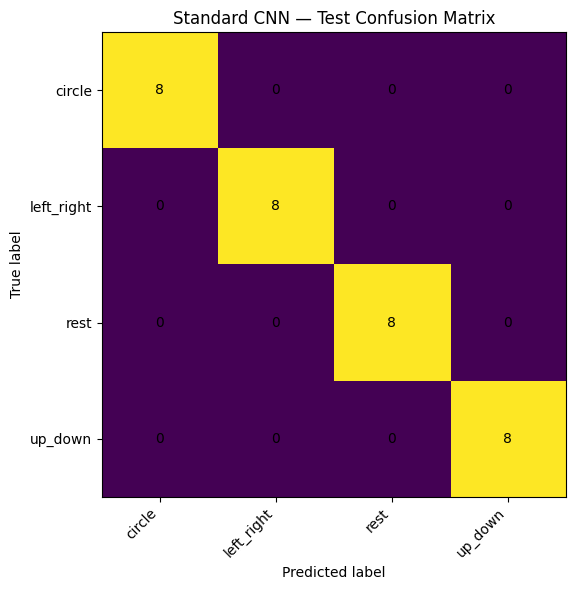

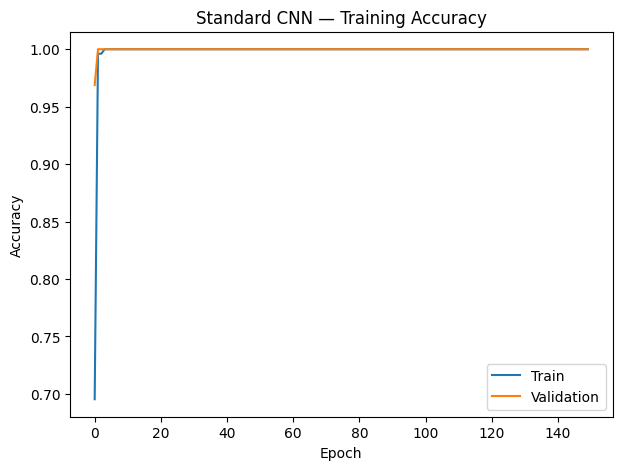

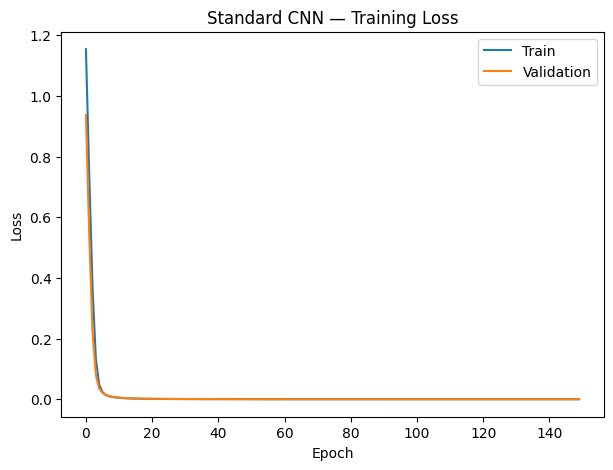

Saved artifact at '/tmp/tmpae4h2z03'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217109578704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109579664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109578896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109577936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109574288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105188368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105186256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109575248: TensorSpec(shape=(), dtype=tf.resource, name=None)

MODEL SIZE
------------------------------------------------------------
Keras model : 67.71 KB
TFLite FP32 : 15.70 KB

HOST TFLITE LATENCY
---------------------

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [100]:
# ============================================================
# MODEL 2 — STANDARD 1D CNN
# TinyML Compression Benchmark
# Fixed 80/10/10 split
# ============================================================

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os
import time

# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("MODEL 2 — STANDARD 1D CNN")
print("=" * 60)


# ============================================================
# 2. LOAD EXACT SAME FIXED SPLIT
# ============================================================

split_file = "fixed_tinyml_split_80_10_10.npz"

if not os.path.exists(split_file):
    raise FileNotFoundError(
        f"{split_file} not found. Run the fixed split cell first."
    )

data = np.load(split_file)

X_train = data["X_train"]
y_train = data["y_train"]

X_val = data["X_val"]
y_val = data["y_val"]

X_test = data["X_test"]
y_test = data["y_test"]


print("\nDATASET")
print("-" * 60)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ============================================================
# 3. CONSTANTS
# ============================================================

NUM_CLASSES = 4

CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]

INPUT_SHAPE = X_train.shape[1:]

print("\nInput shape:", INPUT_SHAPE)
print("Classes:", CLASS_NAMES)


# ============================================================
# 4. TRAIN-ONLY NORMALIZATION
# ============================================================

mean = X_train.mean(
    axis=(0, 1),
    keepdims=True
)

std = X_train.std(
    axis=(0, 1),
    keepdims=True
)

std = np.where(
    std < 1e-8,
    1.0,
    std
)

X_train_scaled = (
    (X_train - mean) / std
).astype(np.float32)

X_val_scaled = (
    (X_val - mean) / std
).astype(np.float32)

X_test_scaled = (
    (X_test - mean) / std
).astype(np.float32)


print("\nTRAIN-ONLY NORMALIZATION")
print("-" * 60)

print("Mean:")
print(mean.reshape(-1))

print("\nStd:")
print(std.reshape(-1))


# ============================================================
# 5. BUILD STANDARD CNN
#
# Architecture:
#
# Input (128,6)
# ↓
# Conv1D 16 filters
# ↓
# MaxPooling
# ↓
# Conv1D 32 filters
# ↓
# MaxPooling
# ↓
# GlobalAveragePooling
# ↓
# Dense 16
# ↓
# Dense 4 Softmax
#
# ============================================================

tf.keras.backend.clear_session()

cnn_model = keras.Sequential(

    [

        keras.Input(
            shape=INPUT_SHAPE
        ),

        layers.Conv1D(
            filters=16,
            kernel_size=5,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling1D(
            pool_size=2
        ),

        layers.Conv1D(
            filters=32,
            kernel_size=3,
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling1D(
            pool_size=2
        ),

        layers.GlobalAveragePooling1D(),

        layers.Dense(
            16,
            activation="relu"
        ),

        layers.Dense(
            NUM_CLASSES,
            activation="softmax"
        )

    ],

    name="Standard_CNN"
)


cnn_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)


print("\nMODEL ARCHITECTURE")
print("-" * 60)

cnn_model.summary()


# ============================================================
# 6. PARAMETERS
# ============================================================

total_params = cnn_model.count_params()

print(
    "\nTotal parameters:",
    f"{total_params:,}"
)


# ============================================================
# 7. TRAINING
# ============================================================

callbacks = [

    keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=20,

        restore_best_weights=True,

        verbose=1

    ),

    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        factor=0.5,

        patience=8,

        min_lr=1e-6,

        verbose=1

    )

]


print("\n" + "=" * 60)
print("TRAINING CNN")
print("=" * 60)


history = cnn_model.fit(

    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=150,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)


# ============================================================
# 8. TEST EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)


test_loss, test_accuracy = cnn_model.evaluate(

    X_test_scaled,

    y_test,

    verbose=0

)


print(
    f"\nTest loss     : {test_loss:.6f}"
)

print(
    f"Test accuracy : {test_accuracy * 100:.2f}%"
)


# ============================================================
# 9. PREDICTIONS
# ============================================================

predictions = cnn_model.predict(

    X_test_scaled,

    verbose=0

)


y_pred = np.argmax(

    predictions,

    axis=1

)


confidence = np.max(

    predictions,

    axis=1

)


average_confidence = np.mean(
    confidence
)


print(
    f"Average confidence: "
    f"{average_confidence:.6f}"
)


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    y_test,

    y_pred

)


print("\nCONFUSION MATRIX")
print("-" * 60)

print(cm)


# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT")
print("-" * 60)


print(

    classification_report(

        y_test,

        y_pred,

        target_names=CLASS_NAMES,

        digits=4,

        zero_division=0

    )

)


# ============================================================
# 12. CONFUSION MATRIX PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(cm)

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(

    CLASS_NAMES,

    rotation=45,

    ha="right"

)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "Standard CNN — Test Confusion Matrix"
)


for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        ax.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"

        )


plt.tight_layout()

plt.show()


# ============================================================
# 13. TRAINING ACCURACY
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(

    history.history["accuracy"],

    label="Train"

)

plt.plot(

    history.history["val_accuracy"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title(
    "Standard CNN — Training Accuracy"
)

plt.legend()

plt.show()


# ============================================================
# 14. TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(

    history.history["loss"],

    label="Train"

)

plt.plot(

    history.history["val_loss"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Standard CNN — Training Loss"
)

plt.legend()

plt.show()


# ============================================================
# 15. SAVE KERAS MODEL
# ============================================================

keras_filename = (
    "standard_cnn.keras"
)

cnn_model.save(
    keras_filename
)


# ============================================================
# 16. CONVERT TO FLOAT32 TFLITE
# ============================================================

converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(cnn_model)
)

cnn_tflite = converter.convert()


tflite_filename = (
    "standard_cnn_float32.tflite"
)


with open(
    tflite_filename,
    "wb"
) as f:

    f.write(
        cnn_tflite
    )


# ============================================================
# 17. MODEL SIZE
# ============================================================

keras_size = os.path.getsize(
    keras_filename
)

tflite_size = os.path.getsize(
    tflite_filename
)


print("\nMODEL SIZE")
print("-" * 60)

print(
    f"Keras model : "
    f"{keras_size / 1024:.2f} KB"
)

print(
    f"TFLite FP32 : "
    f"{tflite_size / 1024:.2f} KB"
)


# ============================================================
# 18. HOST TFLITE LATENCY
# ============================================================

interpreter = tf.lite.Interpreter(

    model_path=tflite_filename

)

interpreter.allocate_tensors()


input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)


sample = (
    X_test_scaled[0:1]
    .astype(np.float32)
)


# Warm-up

for _ in range(10):

    interpreter.set_tensor(

        input_details[0]["index"],

        sample

    )

    interpreter.invoke()


# Actual timing

N_RUNS = 100


start = time.perf_counter()


for _ in range(N_RUNS):

    interpreter.set_tensor(

        input_details[0]["index"],

        sample

    )

    interpreter.invoke()


end = time.perf_counter()


host_latency_ms = (

    (end - start)

    / N_RUNS

    * 1000

)


print("\nHOST TFLITE LATENCY")
print("-" * 60)

print(
    f"{host_latency_ms:.4f} ms / inference"
)

print(
    "(Host measurement — NOT Arduino latency)"
)


# ============================================================
# 19. APPROXIMATE MAC COUNT
#
# Conv1:
# output length = 128
# kernel = 5
# input channels = 6
# output channels = 16
#
# Conv2:
# after pooling -> length 64
# kernel = 3
# input channels = 16
# output channels = 32
#
# Dense:
# 32 -> 16
# 16 -> 4
# ============================================================

conv1_macs = (
    128 * 5 * 6 * 16
)

conv2_macs = (
    64 * 3 * 16 * 32
)

dense1_macs = (
    32 * 16
)

dense2_macs = (
    16 * 4
)


approx_macs = (

    conv1_macs
    + conv2_macs
    + dense1_macs
    + dense2_macs

)


print("\nAPPROXIMATE MAC COUNT")
print("-" * 60)

print(
    f"Conv1 MACs : {conv1_macs:,}"
)

print(
    f"Conv2 MACs : {conv2_macs:,}"
)

print(
    f"Dense MACs : "
    f"{dense1_macs + dense2_macs:,}"
)

print(
    f"TOTAL MACs : {approx_macs:,}"
)


# ============================================================
# 20. SAVE SCALER
# ============================================================

np.savez(

    "standard_cnn_scaler.npz",

    mean=mean.reshape(-1),

    std=std.reshape(-1)

)


# ============================================================
# 21. FINAL BENCHMARK SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("MODEL 2 — STANDARD CNN BENCHMARK")
print("=" * 60)

print(
    f"Test samples        : "
    f"{len(y_test)}"
)

print(
    f"Test accuracy       : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Average confidence  : "
    f"{average_confidence:.6f}"
)

print(
    f"Parameters          : "
    f"{total_params:,}"
)

print(
    f"Approx. MACs        : "
    f"{approx_macs:,}"
)

print(
    f"TFLite FP32 size    : "
    f"{tflite_size / 1024:.2f} KB"
)

print(
    f"Host latency        : "
    f"{host_latency_ms:.4f} ms"
)

print(
    "Arduino latency     : "
    "TO BE MEASURED"
)

print("=" * 60)

print("\nMODEL 2 COMPLETE")

MODEL 3 — QUANTIZED STANDARD CNN (FULL INT8)

DATASET
--------------------------------------------------
X_train: (256, 128, 6)
y_train: (256,)
X_val  : (32, 128, 6)
y_val  : (32,)
X_test : (32, 128, 6)
y_test : (32,)

TRAIN-ONLY NORMALIZATION
--------------------------------------------------
Mean:
[ 1.1208049e-03 -8.2654111e-02 -1.2643310e-01 -1.5734744e+00
  1.5375391e-01  2.9320249e-01]

Std:
[ 0.2609839   0.60880005  0.7468958  19.054401   17.840723   56.507168  ]

MODEL ARCHITECTURE
--------------------------------------------------


Model: "Standard_CNN_For_INT8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 16)        │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,660 (10.39 KB)

 Trainable params: 2,660 (10.39 KB)

 Non-trainable params: 0 (0.00 B)


TRAINING COMPLETE
--------------------------------------------------
Epochs executed: 150

FLOAT MODEL BEFORE QUANTIZATION
--------------------------------------------------
Test loss       : 0.000010
Test accuracy   : 100.00%
Avg confidence  : 0.999990

CONVERTING TO FULL INT8...
--------------------------------------------------
Saved artifact at '/tmp/tmpwrj496mw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217109575824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217099081168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109581584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217088686032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217088692944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217109574096: TensorSpec(shape=(

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 conversion complete.
Saved: standard_cnn_int8.tflite

INT8 MODEL SIZE
--------------------------------------------------
Bytes : 10,968
KB    : 10.71

INT8 MODEL INFORMATION
--------------------------------------------------
Input shape      : [  1 128   6]
Input dtype      : <class 'numpy.int8'>
Output shape     : [1 4]
Output dtype     : <class 'numpy.int8'>

Input scale      : 0.04536959156394005
Input zero point : 14
Output scale     : 0.00390625
Output zero point: -128

INT8 TEST SET EVALUATION
Test accuracy      : 100.00%
Average confidence : 0.996094

CONFUSION MATRIX
--------------------------------------------------
[[8 0 0 0]
 [0 8 0 0]
 [0 0 8 0]
 [0 0 0 8]]

CLASSIFICATION REPORT
--------------------------------------------------
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000         8
  left_right     1.0000    1.0000    1.0000         8
        rest     1.0000    1.0000    1.0000         8
     up_down     1.0000   

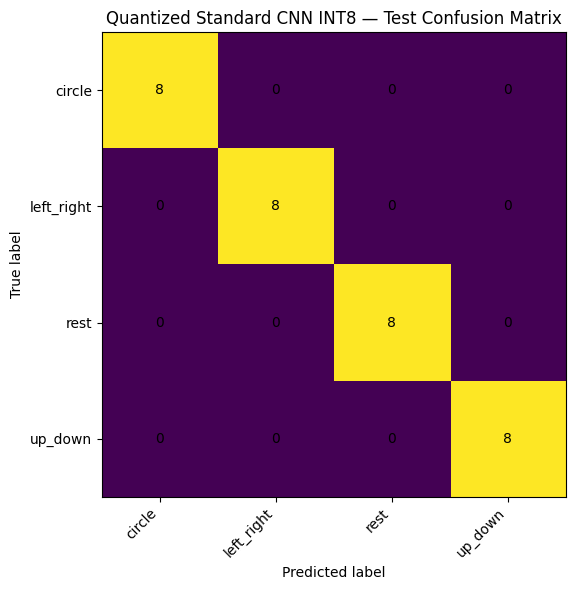


HOST TFLITE INT8 LATENCY
--------------------------------------------------
Mean   : 0.0148 ms
Median : 0.0143 ms
Min    : 0.0141 ms
Max    : 0.0213 ms
(Host measurement — NOT Arduino latency)


MODEL 3 — QUANTIZED STANDARD CNN INT8 BENCHMARK
Test samples          : 32
Float accuracy        : 100.00%
INT8 accuracy         : 100.00%
Accuracy drop         : 0.00 percentage points
Average confidence    : 0.996094
Parameters            : 2,660
Approx. MACs          : 160,320
TFLite INT8 size      : 10.71 KB
Host mean latency     : 0.0148 ms
Arduino latency       : TO BE MEASURED


MODEL 2 FP32 vs MODEL 3 INT8
Metric                          FP32 CNN       INT8 CNN
-------------------------------------------------------
Accuracy                         100.00%        100.00%
Parameters                         2,660          2,660
MACs                             160,320        160,320
Model size (KB)                    15.70          10.71
Host latency (ms)                 0.0147         0

In [101]:
# ============================================================
# MODEL 3 — QUANTIZED STANDARD 1D CNN (FULL INT8)
# TinyML Compression Benchmark
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD FIXED DATASET SPLIT
# ============================================================

print("=" * 60)
print("MODEL 3 — QUANTIZED STANDARD CNN (FULL INT8)")
print("=" * 60)

split_file = "fixed_tinyml_split_80_10_10.npz"

if not os.path.exists(split_file):
    raise FileNotFoundError(
        f"{split_file} not found. Run the dataset split cell first."
    )

data = np.load(split_file)

X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int32)

X_val = data["X_val"].astype(np.float32)
y_val = data["y_val"].astype(np.int32)

X_test = data["X_test"].astype(np.float32)
y_test = data["y_test"].astype(np.int32)

class_names = ["circle", "left_right", "rest", "up_down"]

print("\nDATASET")
print("-" * 50)
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ============================================================
# 2. TRAIN-ONLY NORMALIZATION
# ============================================================

mean = X_train.mean(axis=(0, 1)).astype(np.float32)
std = X_train.std(axis=(0, 1)).astype(np.float32)

std = np.where(std < 1e-8, 1.0, std).astype(np.float32)

X_train_n = ((X_train - mean) / std).astype(np.float32)
X_val_n   = ((X_val   - mean) / std).astype(np.float32)
X_test_n  = ((X_test  - mean) / std).astype(np.float32)

print("\nTRAIN-ONLY NORMALIZATION")
print("-" * 50)
print("Mean:")
print(mean)
print("\nStd:")
print(std)


# ============================================================
# 3. REBUILD SAME STANDARD CNN AS MODEL 2
# ============================================================

tf.keras.backend.clear_session()

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 6)),

    tf.keras.layers.Conv1D(
        filters=16,
        kernel_size=5,
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    tf.keras.layers.MaxPooling1D(pool_size=2),

    tf.keras.layers.GlobalAveragePooling1D(),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
], name="Standard_CNN_For_INT8")


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nMODEL ARCHITECTURE")
print("-" * 50)
model.summary()


# ============================================================
# 4. TRAIN MODEL
# ============================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_n,
    y_train,

    validation_data=(
        X_val_n,
        y_val
    ),

    epochs=150,
    batch_size=16,

    callbacks=[early_stop],

    verbose=0
)

print("\nTRAINING COMPLETE")
print("-" * 50)

print("Epochs executed:", len(history.history["loss"]))


# ============================================================
# 5. FLOAT MODEL TEST ACCURACY BEFORE QUANTIZATION
# ============================================================

float_loss, float_accuracy = model.evaluate(
    X_test_n,
    y_test,
    verbose=0
)

float_predictions = model.predict(
    X_test_n,
    verbose=0
)

float_pred_classes = np.argmax(
    float_predictions,
    axis=1
)

float_confidence = np.mean(
    np.max(float_predictions, axis=1)
)

print("\nFLOAT MODEL BEFORE QUANTIZATION")
print("-" * 50)

print(f"Test loss       : {float_loss:.6f}")
print(f"Test accuracy   : {float_accuracy * 100:.2f}%")
print(f"Avg confidence  : {float_confidence:.6f}")


# ============================================================
# 6. REPRESENTATIVE DATASET
# IMPORTANT:
# ONLY TRAINING DATA IS USED
# ============================================================

def representative_dataset():

    for i in range(len(X_train_n)):

        sample = X_train_n[i:i+1].astype(np.float32)

        yield [sample]


# ============================================================
# 7. FULL INTEGER INT8 QUANTIZATION
# ============================================================

print("\nCONVERTING TO FULL INT8...")
print("-" * 50)

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8_model = converter.convert()

int8_filename = "standard_cnn_int8.tflite"

with open(int8_filename, "wb") as f:
    f.write(tflite_int8_model)

print("INT8 conversion complete.")
print("Saved:", int8_filename)


# ============================================================
# 8. MODEL SIZE
# ============================================================

int8_size_bytes = len(tflite_int8_model)
int8_size_kb = int8_size_bytes / 1024.0

print("\nINT8 MODEL SIZE")
print("-" * 50)

print(f"Bytes : {int8_size_bytes:,}")
print(f"KB    : {int8_size_kb:.2f}")


# ============================================================
# 9. LOAD INT8 TFLITE INTERPRETER
# ============================================================

interpreter = tf.lite.Interpreter(
    model_content=tflite_int8_model
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("\nINT8 MODEL INFORMATION")
print("-" * 50)

print("Input shape      :", input_details[0]["shape"])
print("Input dtype      :", input_details[0]["dtype"])

print("Output shape     :", output_details[0]["shape"])
print("Output dtype     :", output_details[0]["dtype"])


input_scale, input_zero_point = input_details[0]["quantization"]
output_scale, output_zero_point = output_details[0]["quantization"]

print("\nInput scale      :", input_scale)
print("Input zero point :", input_zero_point)

print("Output scale     :", output_scale)
print("Output zero point:", output_zero_point)

if input_scale == 0:
    raise RuntimeError("Invalid input quantization scale.")

if output_scale == 0:
    raise RuntimeError("Invalid output quantization scale.")


# ============================================================
# 10. INT8 TEST INFERENCE
# ============================================================

y_pred = []
confidence_values = []

latencies_ms = []

input_index = input_details[0]["index"]
output_index = output_details[0]["index"]


# Warm-up
for i in range(min(10, len(X_test_n))):

    x = X_test_n[i:i+1]

    x_q = np.round(
        x / input_scale + input_zero_point
    )

    x_q = np.clip(
        x_q,
        -128,
        127
    ).astype(np.int8)

    interpreter.set_tensor(
        input_index,
        x_q
    )

    interpreter.invoke()


# Actual benchmark
for i in range(len(X_test_n)):

    x = X_test_n[i:i+1]


    # --------------------------------------------------------
    # Quantize FP32 input -> INT8
    # --------------------------------------------------------

    x_q = np.round(
        x / input_scale + input_zero_point
    )

    x_q = np.clip(
        x_q,
        -128,
        127
    ).astype(np.int8)


    interpreter.set_tensor(
        input_index,
        x_q
    )


    # --------------------------------------------------------
    # Measure inference time
    # --------------------------------------------------------

    start = time.perf_counter()

    interpreter.invoke()

    end = time.perf_counter()

    latency_ms = (
        end - start
    ) * 1000.0

    latencies_ms.append(
        latency_ms
    )


    # --------------------------------------------------------
    # Get INT8 output
    # --------------------------------------------------------

    output_q = interpreter.get_tensor(
        output_index
    )[0]


    # --------------------------------------------------------
    # Dequantize output
    # --------------------------------------------------------

    output_fp = (
        output_q.astype(np.float32)
        - output_zero_point
    ) * output_scale


    predicted_class = int(
        np.argmax(output_fp)
    )

    confidence = float(
        np.max(output_fp)
    )


    y_pred.append(
        predicted_class
    )

    confidence_values.append(
        confidence
    )


y_pred = np.array(
    y_pred,
    dtype=np.int32
)

confidence_values = np.array(
    confidence_values,
    dtype=np.float32
)


# ============================================================
# 11. INT8 ACCURACY
# ============================================================

int8_accuracy = np.mean(
    y_pred == y_test
)

avg_confidence = np.mean(
    confidence_values
)

print("\n" + "=" * 60)
print("INT8 TEST SET EVALUATION")
print("=" * 60)

print(
    f"Test accuracy      : "
    f"{int8_accuracy * 100:.2f}%"
)

print(
    f"Average confidence : "
    f"{avg_confidence:.6f}"
)


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nCONFUSION MATRIX")
print("-" * 50)

print(cm)


print("\nCLASSIFICATION REPORT")
print("-" * 50)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 13. CONFUSION MATRIX PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

im = ax.imshow(cm)

ax.set_xticks(
    np.arange(len(class_names))
)

ax.set_yticks(
    np.arange(len(class_names))
)

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    class_names
)

ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "Quantized Standard CNN INT8 — Test Confusion Matrix"
)


for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        ax.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center"
        )


plt.tight_layout()
plt.show()


# ============================================================
# 14. HOST LATENCY STATISTICS
# ============================================================

latencies_ms = np.array(
    latencies_ms,
    dtype=np.float64
)

mean_latency = np.mean(
    latencies_ms
)

median_latency = np.median(
    latencies_ms
)

min_latency = np.min(
    latencies_ms
)

max_latency = np.max(
    latencies_ms
)


print("\nHOST TFLITE INT8 LATENCY")
print("-" * 50)

print(
    f"Mean   : {mean_latency:.4f} ms"
)

print(
    f"Median : {median_latency:.4f} ms"
)

print(
    f"Min    : {min_latency:.4f} ms"
)

print(
    f"Max    : {max_latency:.4f} ms"
)

print(
    "(Host measurement — NOT Arduino latency)"
)


# ============================================================
# 15. PARAMETER COUNT
# ============================================================

params = model.count_params()


# ============================================================
# 16. APPROXIMATE MAC COUNT
# Same architecture as Model 2
# ============================================================

# Conv1:
# output = 128 x 16
# kernel = 5
# input channels = 6

conv1_macs = (
    128
    * 16
    * 5
    * 6
)


# Conv2:
# after first pooling = 64 x 16
# output channels = 32
# kernel = 3

conv2_macs = (
    64
    * 32
    * 3
    * 16
)


# Dense:
# 32 -> 16
# 16 -> 4

dense1_macs = 32 * 16
dense2_macs = 16 * 4

total_macs = (
    conv1_macs
    + conv2_macs
    + dense1_macs
    + dense2_macs
)


# ============================================================
# 17. FINAL BENCHMARK SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("MODEL 3 — QUANTIZED STANDARD CNN INT8 BENCHMARK")
print("=" * 60)

print(
    f"Test samples          : "
    f"{len(y_test)}"
)

print(
    f"Float accuracy        : "
    f"{float_accuracy * 100:.2f}%"
)

print(
    f"INT8 accuracy         : "
    f"{int8_accuracy * 100:.2f}%"
)

print(
    f"Accuracy drop         : "
    f"{(float_accuracy - int8_accuracy) * 100:.2f} percentage points"
)

print(
    f"Average confidence    : "
    f"{avg_confidence:.6f}"
)

print(
    f"Parameters            : "
    f"{params:,}"
)

print(
    f"Approx. MACs          : "
    f"{total_macs:,}"
)

print(
    f"TFLite INT8 size      : "
    f"{int8_size_kb:.2f} KB"
)

print(
    f"Host mean latency     : "
    f"{mean_latency:.4f} ms"
)

print(
    "Arduino latency       : TO BE MEASURED"
)

print("=" * 60)


# ============================================================
# 18. COMPARE MODEL 2 FP32 VS MODEL 3 INT8
# ============================================================

# Model 2 values already measured previously
model2_fp32_size_kb = 15.70
model2_accuracy = 1.00
model2_params = 2660
model2_macs = 160320
model2_host_latency_ms = 0.0147


size_reduction = (
    1.0
    - int8_size_kb / model2_fp32_size_kb
) * 100.0


print("\n")
print("=" * 60)
print("MODEL 2 FP32 vs MODEL 3 INT8")
print("=" * 60)

print(
    f"{'Metric':<25}"
    f"{'FP32 CNN':>15}"
    f"{'INT8 CNN':>15}"
)

print("-" * 55)

print(
    f"{'Accuracy':<25}"
    f"{model2_accuracy * 100:>14.2f}%"
    f"{int8_accuracy * 100:>14.2f}%"
)

print(
    f"{'Parameters':<25}"
    f"{model2_params:>15,}"
    f"{params:>15,}"
)

print(
    f"{'MACs':<25}"
    f"{model2_macs:>15,}"
    f"{total_macs:>15,}"
)

print(
    f"{'Model size (KB)':<25}"
    f"{model2_fp32_size_kb:>15.2f}"
    f"{int8_size_kb:>15.2f}"
)

print(
    f"{'Host latency (ms)':<25}"
    f"{model2_host_latency_ms:>15.4f}"
    f"{mean_latency:>15.4f}"
)

print("-" * 55)

print(
    f"\nINT8 model-size reduction vs FP32: "
    f"{size_reduction:.2f}%"
)

print("=" * 60)


# ============================================================
# 19. SAVE NORMALIZATION PARAMETERS
# Needed later for Arduino deployment
# ============================================================

np.savez(
    "standard_cnn_int8_scaler.npz",
    mean=mean,
    std=std
)

print("\nSaved files:")
print("  standard_cnn_int8.tflite")
print("  standard_cnn_int8_scaler.npz")

print("\nMODEL 3 COMPLETE")

MODEL 4 — DEPTHWISE SEPARABLE CNN FP32

DATASET
------------------------------------------------------------
X_train: (256, 128, 6)
y_train: (256,)
X_val  : (32, 128, 6)
y_val  : (32,)
X_test : (32, 128, 6)
y_test : (32,)

TRAIN-ONLY NORMALIZATION
------------------------------------------------------------
Mean:
[ 1.1208049e-03 -8.2654111e-02 -1.2643310e-01 -1.5734744e+00
  1.5375391e-01  2.9320249e-01]

Std:
[ 0.2609839   0.60880005  0.7468958  19.054401   17.840723   56.507168  ]

MODEL ARCHITECTURE
------------------------------------------------------------


Model: "Depthwise_Separable_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d                │ (None, 128, 16)        │           142 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 64, 32)         │           592 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330 (5.20 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,330

TRAINING DEPTHWISE CNN
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.4570 - loss: 1.3615 - val_accuracy: 0.7500 - val_loss: 1.3334 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8164 - loss: 1.3017 - val_accuracy: 0.9375 - val_loss: 1.2627 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9453 - loss: 1.2088 - val_accuracy: 0.9688 - val_loss: 1.1434 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9570 - loss: 1.0540 - val_accuracy: 0.9688 - val_loss: 0.9488 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9531 - loss: 0.8228 - val_accuracy: 0.9688 - val_loss: 0.6878 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9688 - loss: 0.5525 - val_accuracy: 0.9688 - val_loss: 0.4218 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8

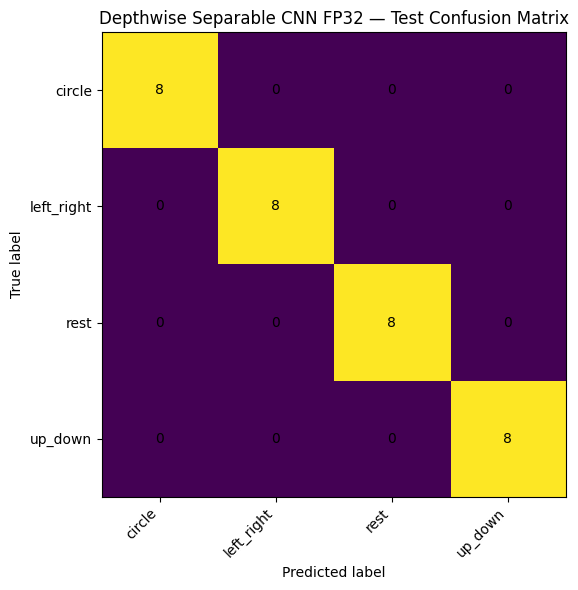

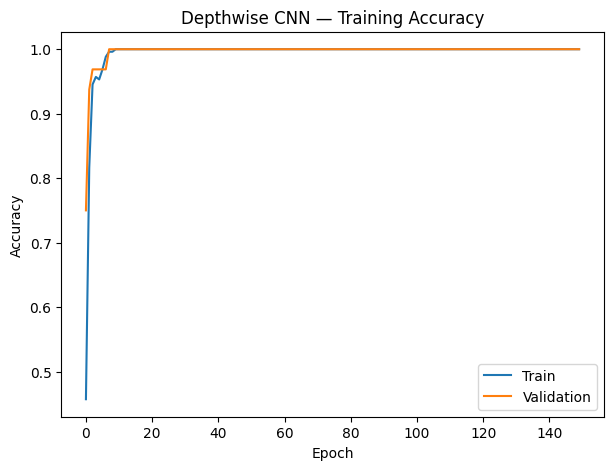

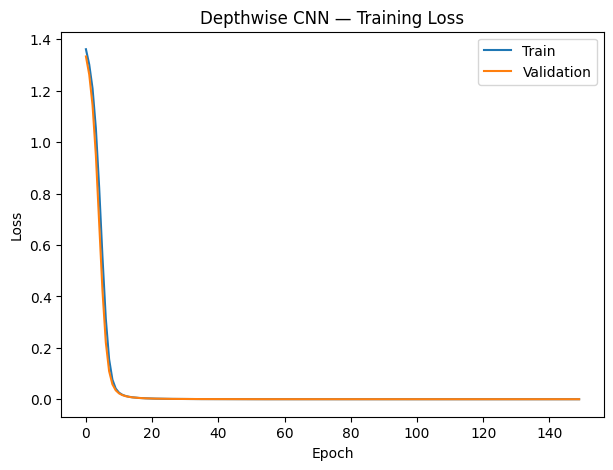

Saved artifact at '/tmp/tmpzxouwv9y'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217088685840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217088699664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217088686608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217088686224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217088685456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105760656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105768528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105757392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105768912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217105765264: TensorSpec(shape=(), dtype=tf.resource, name=None)

MODEL SIZE
---------

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [102]:
# ============================================================
# MODEL 4 — DEPTHWISE SEPARABLE CNN FP32
# TinyML Compression Benchmark
# Fixed 80/10/10 split
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 60)
print("MODEL 4 — DEPTHWISE SEPARABLE CNN FP32")
print("=" * 60)


# ============================================================
# 2. LOAD FIXED SPLIT
# ============================================================

split_file = "fixed_tinyml_split_80_10_10.npz"

if not os.path.exists(split_file):
    raise FileNotFoundError(
        f"{split_file} not found."
    )

data = np.load(split_file)

X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int32)

X_val = data["X_val"].astype(np.float32)
y_val = data["y_val"].astype(np.int32)

X_test = data["X_test"].astype(np.float32)
y_test = data["y_test"].astype(np.int32)


print("\nDATASET")
print("-" * 60)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ============================================================
# 3. CONSTANTS
# ============================================================

NUM_CLASSES = 4

CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]

INPUT_SHAPE = (128, 6)


# ============================================================
# 4. TRAIN-ONLY NORMALIZATION
# ============================================================

mean = X_train.mean(
    axis=(0, 1)
).astype(np.float32)

std = X_train.std(
    axis=(0, 1)
).astype(np.float32)

std = np.where(
    std < 1e-8,
    1.0,
    std
).astype(np.float32)


X_train_n = (
    (X_train - mean) / std
).astype(np.float32)

X_val_n = (
    (X_val - mean) / std
).astype(np.float32)

X_test_n = (
    (X_test - mean) / std
).astype(np.float32)


print("\nTRAIN-ONLY NORMALIZATION")
print("-" * 60)

print("Mean:")
print(mean)

print("\nStd:")
print(std)


# ============================================================
# 5. BUILD DEPTHWISE SEPARABLE CNN
#
# Input
# ↓
# SeparableConv1D 16 filters
# ↓
# MaxPooling
# ↓
# SeparableConv1D 32 filters
# ↓
# MaxPooling
# ↓
# GlobalAveragePooling
# ↓
# Dense 16
# ↓
# Softmax 4
# ============================================================

tf.keras.backend.clear_session()

depthwise_model = keras.Sequential([

    keras.Input(
        shape=INPUT_SHAPE
    ),

    layers.SeparableConv1D(
        filters=16,
        kernel_size=5,
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling1D(
        pool_size=2
    ),

    layers.SeparableConv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling1D(
        pool_size=2
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )

], name="Depthwise_Separable_CNN")


depthwise_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)


print("\nMODEL ARCHITECTURE")
print("-" * 60)

depthwise_model.summary()


# ============================================================
# 6. PARAMETER COUNT
# ============================================================

total_params = depthwise_model.count_params()

print(
    "\nTotal parameters:",
    f"{total_params:,}"
)


# ============================================================
# 7. TRAINING
# ============================================================

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )

]


print("\n" + "=" * 60)
print("TRAINING DEPTHWISE CNN")
print("=" * 60)


history = depthwise_model.fit(

    X_train_n,
    y_train,

    validation_data=(
        X_val_n,
        y_val
    ),

    epochs=150,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)


# ============================================================
# 8. TEST EVALUATION
# ============================================================

print("\n" + "=" * 60)
print("TEST SET EVALUATION")
print("=" * 60)


test_loss, test_accuracy = depthwise_model.evaluate(

    X_test_n,
    y_test,

    verbose=0

)


print(
    f"\nTest loss     : {test_loss:.6f}"
)

print(
    f"Test accuracy : {test_accuracy * 100:.2f}%"
)


# ============================================================
# 9. PREDICTIONS
# ============================================================

predictions = depthwise_model.predict(

    X_test_n,

    verbose=0

)


y_pred = np.argmax(
    predictions,
    axis=1
)

confidence = np.max(
    predictions,
    axis=1
)

average_confidence = np.mean(
    confidence
)


print(
    f"Average confidence: "
    f"{average_confidence:.6f}"
)


# ============================================================
# 10. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nCONFUSION MATRIX")
print("-" * 60)

print(cm)


print("\nCLASSIFICATION REPORT")
print("-" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 11. CONFUSION MATRIX PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.imshow(cm)

ax.set_xticks(
    np.arange(NUM_CLASSES)
)

ax.set_yticks(
    np.arange(NUM_CLASSES)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "Depthwise Separable CNN FP32 — Test Confusion Matrix"
)


for i in range(NUM_CLASSES):

    for j in range(NUM_CLASSES):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()
plt.show()


# ============================================================
# 12. TRAINING ACCURACY PLOT
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Depthwise CNN — Training Accuracy"
)

plt.legend()
plt.show()


# ============================================================
# 13. TRAINING LOSS PLOT
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Depthwise CNN — Training Loss"
)

plt.legend()
plt.show()


# ============================================================
# 14. SAVE KERAS MODEL
# ============================================================

keras_filename = (
    "depthwise_cnn_float.keras"
)

depthwise_model.save(
    keras_filename
)


# ============================================================
# 15. CONVERT TO FLOAT32 TFLITE
# ============================================================

converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(
        depthwise_model
    )
)

depthwise_tflite = (
    converter.convert()
)


tflite_filename = (
    "depthwise_cnn_float32.tflite"
)


with open(
    tflite_filename,
    "wb"
) as f:

    f.write(
        depthwise_tflite
    )


# ============================================================
# 16. MODEL SIZE
# ============================================================

keras_size = os.path.getsize(
    keras_filename
)

tflite_size = os.path.getsize(
    tflite_filename
)


print("\nMODEL SIZE")
print("-" * 60)

print(
    f"Keras model : "
    f"{keras_size / 1024:.2f} KB"
)

print(
    f"TFLite FP32 : "
    f"{tflite_size / 1024:.2f} KB"
)


# ============================================================
# 17. HOST TFLITE LATENCY
# ============================================================

interpreter = tf.lite.Interpreter(
    model_path=tflite_filename
)

interpreter.allocate_tensors()


input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)


sample = (
    X_test_n[0:1]
    .astype(np.float32)
)


# Warm-up

for _ in range(10):

    interpreter.set_tensor(
        input_details[0]["index"],
        sample
    )

    interpreter.invoke()


# Timing

N_RUNS = 100

start = time.perf_counter()


for _ in range(N_RUNS):

    interpreter.set_tensor(
        input_details[0]["index"],
        sample
    )

    interpreter.invoke()


end = time.perf_counter()


host_latency_ms = (
    (end - start)
    / N_RUNS
    * 1000
)


print("\nHOST TFLITE LATENCY")
print("-" * 60)

print(
    f"{host_latency_ms:.4f} ms / inference"
)

print(
    "(Host measurement — NOT Arduino latency)"
)


# ============================================================
# 18. APPROXIMATE MAC COUNT
#
# Separable Conv =
# Depthwise + Pointwise
#
# Layer 1:
# depthwise:
# 128 * 6 * 5
#
# pointwise:
# 128 * 6 * 16
#
# Layer 2:
# after pooling -> 64
#
# depthwise:
# 64 * 16 * 3
#
# pointwise:
# 64 * 16 * 32
#
# Dense:
# 32 -> 16
# 16 -> 4
# ============================================================

sep1_depthwise_macs = (
    128 * 6 * 5
)

sep1_pointwise_macs = (
    128 * 6 * 16
)


sep2_depthwise_macs = (
    64 * 16 * 3
)

sep2_pointwise_macs = (
    64 * 16 * 32
)


dense1_macs = (
    32 * 16
)

dense2_macs = (
    16 * 4
)


approx_macs = (

    sep1_depthwise_macs
    + sep1_pointwise_macs

    + sep2_depthwise_macs
    + sep2_pointwise_macs

    + dense1_macs
    + dense2_macs

)


print("\nAPPROXIMATE MAC COUNT")
print("-" * 60)

print(
    f"SepConv1 depthwise : "
    f"{sep1_depthwise_macs:,}"
)

print(
    f"SepConv1 pointwise : "
    f"{sep1_pointwise_macs:,}"
)

print(
    f"SepConv2 depthwise : "
    f"{sep2_depthwise_macs:,}"
)

print(
    f"SepConv2 pointwise : "
    f"{sep2_pointwise_macs:,}"
)

print(
    f"Dense MACs         : "
    f"{dense1_macs + dense2_macs:,}"
)

print(
    f"TOTAL MACs         : "
    f"{approx_macs:,}"
)


# ============================================================
# 19. SAVE SCALER
# ============================================================

np.savez(
    "depthwise_cnn_float_scaler.npz",
    mean=mean,
    std=std
)


# ============================================================
# 20. COMPARE AGAINST STANDARD CNN FP32
# ============================================================

standard_cnn_params = 2660
standard_cnn_macs = 160320
standard_cnn_size_kb = 15.70
standard_cnn_accuracy = 1.00


param_reduction = (
    1
    -
    total_params
    /
    standard_cnn_params
) * 100


mac_reduction = (
    1
    -
    approx_macs
    /
    standard_cnn_macs
) * 100


size_reduction = (
    1
    -
    (tflite_size / 1024)
    /
    standard_cnn_size_kb
) * 100


print("\n")
print("=" * 60)
print("STANDARD CNN vs DEPTHWISE CNN FP32")
print("=" * 60)

print(
    f"{'Metric':<24}"
    f"{'Standard CNN':>18}"
    f"{'Depthwise':>18}"
)

print("-" * 60)

print(
    f"{'Accuracy':<24}"
    f"{standard_cnn_accuracy*100:>17.2f}%"
    f"{test_accuracy*100:>17.2f}%"
)

print(
    f"{'Parameters':<24}"
    f"{standard_cnn_params:>18,}"
    f"{total_params:>18,}"
)

print(
    f"{'MACs':<24}"
    f"{standard_cnn_macs:>18,}"
    f"{approx_macs:>18,}"
)

print(
    f"{'Model size KB':<24}"
    f"{standard_cnn_size_kb:>18.2f}"
    f"{tflite_size/1024:>18.2f}"
)

print("-" * 60)

print(
    f"Parameter reduction : "
    f"{param_reduction:.2f}%"
)

print(
    f"MAC reduction       : "
    f"{mac_reduction:.2f}%"
)

print(
    f"Model-size reduction: "
    f"{size_reduction:.2f}%"
)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("MODEL 4 — DEPTHWISE CNN FP32 BENCHMARK")
print("=" * 60)

print(
    f"Test samples        : "
    f"{len(y_test)}"
)

print(
    f"Test accuracy       : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Average confidence  : "
    f"{average_confidence:.6f}"
)

print(
    f"Parameters          : "
    f"{total_params:,}"
)

print(
    f"Approx. MACs        : "
    f"{approx_macs:,}"
)

print(
    f"TFLite FP32 size    : "
    f"{tflite_size / 1024:.2f} KB"
)

print(
    f"Host latency        : "
    f"{host_latency_ms:.4f} ms"
)

print(
    "Arduino latency     : TO BE MEASURED"
)

print("=" * 60)

print("\nMODEL 4 COMPLETE")

MODEL 5 — QUANTIZED DEPTHWISE CNN (FULL INT8)

DATASET
-------------------------------------------------------
X_train: (256, 128, 6)
y_train: (256,)
X_val  : (32, 128, 6)
y_val  : (32,)
X_test : (32, 128, 6)
y_test : (32,)

TRAIN-ONLY NORMALIZATION
-------------------------------------------------------
Mean:
[ 1.1208049e-03 -8.2654111e-02 -1.2643310e-01 -1.5734744e+00
  1.5375391e-01  2.9320249e-01]

Std:
[ 0.2609839   0.60880005  0.7468958  19.054401   17.840723   56.507168  ]

MODEL ARCHITECTURE
-------------------------------------------------------


Model: "Depthwise_CNN_For_INT8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv1d                │ (None, 128, 16)        │           142 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d_1              │ (None, 64, 32)         │           592 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,330 (5.20 KB)

 Trainable params: 1,330 (5.20 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 72: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 80: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 88: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 96: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 104: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 112: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 120: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 128: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.

Epoch 136: ReduceLROnPlateau reducing learning rate to 1e-06.
Restoring model weights from the end of the best epoch: 150.

TRAINING COMPLETE
-------------------------------------------------------
Epochs executed: 150

FLOAT MODEL BEFORE QUANTIZATION
----------------------------------------

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


INT8 conversion complete.
Saved: depthwise_cnn_int8.tflite

INT8 MODEL SIZE
-------------------------------------------------------
Bytes : 11,576
KB    : 11.30

INT8 MODEL INFORMATION
-------------------------------------------------------
Input shape      : [  1 128   6]
Input dtype      : <class 'numpy.int8'>
Output shape     : [1 4]
Output dtype     : <class 'numpy.int8'>

Input scale      : 0.04536959156394005
Input zero point : 14
Output scale     : 0.00390625
Output zero point: -128


INT8 TEST SET EVALUATION
Test accuracy      : 100.00%
Average confidence : 0.996094

CONFUSION MATRIX
-------------------------------------------------------
[[8 0 0 0]
 [0 8 0 0]
 [0 0 8 0]
 [0 0 0 8]]

CLASSIFICATION REPORT
-------------------------------------------------------
              precision    recall  f1-score   support

      circle     1.0000    1.0000    1.0000         8
  left_right     1.0000    1.0000    1.0000         8
        rest     1.0000    1.0000    1.0000         8
    

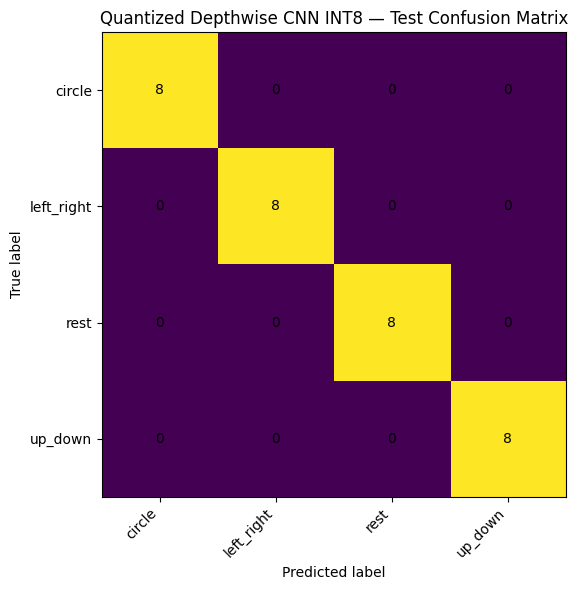


HOST TFLITE INT8 LATENCY
-------------------------------------------------------
Mean   : 0.0150 ms
Median : 0.0121 ms
Min    : 0.0118 ms
Max    : 0.0341 ms
(Host measurement — NOT Arduino latency)


MODEL 4 FP32 vs MODEL 5 INT8
Metric                       FP32 Depthwise    INT8 Depthwise
-----------------------------------------------------------------
Accuracy                            100.00%           100.00%
Parameters                            1,330             1,330
MACs                                 52,544            52,544
Model size (KB)                       11.94             11.30
Host latency (ms)                    0.0107            0.0150
-----------------------------------------------------------------

INT8 size reduction vs Depthwise FP32: 5.32%
Accuracy drop: 0.00 percentage points


MODEL 5 — QUANTIZED DEPTHWISE CNN INT8 BENCHMARK
Test samples          : 32
Float accuracy        : 100.00%
INT8 accuracy         : 100.00%
Accuracy drop         : 0.00 percentage 

In [103]:
# ============================================================
# MODEL 5 — QUANTIZED DEPTHWISE CNN (FULL INT8)
# TinyML Compression Benchmark
# Fixed 80/10/10 split
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 65)
print("MODEL 5 — QUANTIZED DEPTHWISE CNN (FULL INT8)")
print("=" * 65)


# ============================================================
# 2. LOAD FIXED SPLIT
# ============================================================

split_file = "fixed_tinyml_split_80_10_10.npz"

if not os.path.exists(split_file):
    raise FileNotFoundError(
        f"{split_file} not found."
    )

data = np.load(split_file)

X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int32)

X_val = data["X_val"].astype(np.float32)
y_val = data["y_val"].astype(np.int32)

X_test = data["X_test"].astype(np.float32)
y_test = data["y_test"].astype(np.int32)

CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]

print("\nDATASET")
print("-" * 55)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val  :", X_val.shape)
print("y_val  :", y_val.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)


# ============================================================
# 3. TRAIN-ONLY NORMALIZATION
# ============================================================

mean = X_train.mean(
    axis=(0, 1)
).astype(np.float32)

std = X_train.std(
    axis=(0, 1)
).astype(np.float32)

std = np.where(
    std < 1e-8,
    1.0,
    std
).astype(np.float32)

X_train_n = (
    (X_train - mean) / std
).astype(np.float32)

X_val_n = (
    (X_val - mean) / std
).astype(np.float32)

X_test_n = (
    (X_test - mean) / std
).astype(np.float32)

print("\nTRAIN-ONLY NORMALIZATION")
print("-" * 55)

print("Mean:")
print(mean)

print("\nStd:")
print(std)


# ============================================================
# 4. REBUILD DEPTHWISE MODEL
# Same architecture as Model 4
# ============================================================

tf.keras.backend.clear_session()

model = keras.Sequential([

    keras.Input(
        shape=(128, 6)
    ),

    layers.SeparableConv1D(
        filters=16,
        kernel_size=5,
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling1D(
        pool_size=2
    ),

    layers.SeparableConv1D(
        filters=32,
        kernel_size=3,
        padding="same",
        activation="relu"
    ),

    layers.MaxPooling1D(
        pool_size=2
    ),

    layers.GlobalAveragePooling1D(),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        4,
        activation="softmax"
    )

], name="Depthwise_CNN_For_INT8")


model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)


print("\nMODEL ARCHITECTURE")
print("-" * 55)

model.summary()


# ============================================================
# 5. TRAIN MODEL
# ============================================================

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )

]


history = model.fit(

    X_train_n,
    y_train,

    validation_data=(
        X_val_n,
        y_val
    ),

    epochs=150,

    batch_size=16,

    callbacks=callbacks,

    verbose=0

)


print("\nTRAINING COMPLETE")
print("-" * 55)

print(
    "Epochs executed:",
    len(history.history["loss"])
)


# ============================================================
# 6. FLOAT MODEL TEST BEFORE QUANTIZATION
# ============================================================

float_loss, float_accuracy = model.evaluate(
    X_test_n,
    y_test,
    verbose=0
)

float_predictions = model.predict(
    X_test_n,
    verbose=0
)

float_pred = np.argmax(
    float_predictions,
    axis=1
)

float_confidence = np.mean(
    np.max(
        float_predictions,
        axis=1
    )
)


print("\nFLOAT MODEL BEFORE QUANTIZATION")
print("-" * 55)

print(
    f"Test loss       : "
    f"{float_loss:.6f}"
)

print(
    f"Test accuracy   : "
    f"{float_accuracy * 100:.2f}%"
)

print(
    f"Avg confidence  : "
    f"{float_confidence:.6f}"
)


# ============================================================
# 7. REPRESENTATIVE DATASET
# TRAIN DATA ONLY
# ============================================================

def representative_dataset():

    for i in range(
        len(X_train_n)
    ):

        sample = X_train_n[
            i:i+1
        ].astype(np.float32)

        yield [sample]


# ============================================================
# 8. FULL INT8 QUANTIZATION
# ============================================================

print("\nCONVERTING TO FULL INT8...")
print("-" * 55)


converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(model)
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = (
    representative_dataset
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = (
    tf.int8
)

converter.inference_output_type = (
    tf.int8
)


tflite_int8_model = (
    converter.convert()
)


int8_filename = (
    "depthwise_cnn_int8.tflite"
)


with open(
    int8_filename,
    "wb"
) as f:

    f.write(
        tflite_int8_model
    )


print(
    "INT8 conversion complete."
)

print(
    "Saved:",
    int8_filename
)


# ============================================================
# 9. MODEL SIZE
# ============================================================

int8_size_bytes = len(
    tflite_int8_model
)

int8_size_kb = (
    int8_size_bytes
    /
    1024.0
)


print("\nINT8 MODEL SIZE")
print("-" * 55)

print(
    f"Bytes : "
    f"{int8_size_bytes:,}"
)

print(
    f"KB    : "
    f"{int8_size_kb:.2f}"
)


# ============================================================
# 10. LOAD INT8 INTERPRETER
# ============================================================

interpreter = tf.lite.Interpreter(
    model_content=tflite_int8_model
)

interpreter.allocate_tensors()


input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)


print("\nINT8 MODEL INFORMATION")
print("-" * 55)

print(
    "Input shape      :",
    input_details[0]["shape"]
)

print(
    "Input dtype      :",
    input_details[0]["dtype"]
)

print(
    "Output shape     :",
    output_details[0]["shape"]
)

print(
    "Output dtype     :",
    output_details[0]["dtype"]
)


input_scale, input_zero_point = (
    input_details[0]["quantization"]
)

output_scale, output_zero_point = (
    output_details[0]["quantization"]
)


print()
print(
    "Input scale      :",
    input_scale
)

print(
    "Input zero point :",
    input_zero_point
)

print(
    "Output scale     :",
    output_scale
)

print(
    "Output zero point:",
    output_zero_point
)


if input_scale == 0:
    raise RuntimeError(
        "Invalid input scale"
    )

if output_scale == 0:
    raise RuntimeError(
        "Invalid output scale"
    )


# ============================================================
# 11. TEST INT8 MODEL
# ============================================================

input_index = (
    input_details[0]["index"]
)

output_index = (
    output_details[0]["index"]
)


y_pred = []

confidence_values = []

latencies_ms = []


# ------------------------------------------------------------
# Warm-up
# ------------------------------------------------------------

for i in range(
    min(
        10,
        len(X_test_n)
    )
):

    x = X_test_n[
        i:i+1
    ]

    x_q = np.round(
        x
        /
        input_scale
        +
        input_zero_point
    )

    x_q = np.clip(
        x_q,
        -128,
        127
    ).astype(np.int8)

    interpreter.set_tensor(
        input_index,
        x_q
    )

    interpreter.invoke()


# ------------------------------------------------------------
# Actual test
# ------------------------------------------------------------

for i in range(
    len(X_test_n)
):

    x = X_test_n[
        i:i+1
    ]


    # Quantize input

    x_q = np.round(
        x
        /
        input_scale
        +
        input_zero_point
    )

    x_q = np.clip(
        x_q,
        -128,
        127
    ).astype(np.int8)


    interpreter.set_tensor(
        input_index,
        x_q
    )


    # Inference latency

    start = (
        time.perf_counter()
    )

    interpreter.invoke()

    end = (
        time.perf_counter()
    )


    latency_ms = (
        end
        -
        start
    ) * 1000.0

    latencies_ms.append(
        latency_ms
    )


    # Output

    output_q = (
        interpreter
        .get_tensor(
            output_index
        )[0]
    )


    output_fp = (
        output_q.astype(
            np.float32
        )
        -
        output_zero_point
    ) * output_scale


    predicted_class = int(
        np.argmax(
            output_fp
        )
    )

    confidence = float(
        np.max(
            output_fp
        )
    )


    y_pred.append(
        predicted_class
    )

    confidence_values.append(
        confidence
    )


y_pred = np.array(
    y_pred,
    dtype=np.int32
)

confidence_values = np.array(
    confidence_values,
    dtype=np.float32
)


# ============================================================
# 12. ACCURACY
# ============================================================

int8_accuracy = np.mean(
    y_pred
    ==
    y_test
)

avg_confidence = np.mean(
    confidence_values
)


print("\n")
print("=" * 65)
print("INT8 TEST SET EVALUATION")
print("=" * 65)

print(
    f"Test accuracy      : "
    f"{int8_accuracy * 100:.2f}%"
)

print(
    f"Average confidence : "
    f"{avg_confidence:.6f}"
)


# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nCONFUSION MATRIX")
print("-" * 55)

print(cm)


print("\nCLASSIFICATION REPORT")
print("-" * 55)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 14. CONFUSION MATRIX PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.imshow(cm)

ax.set_xticks(
    np.arange(4)
)

ax.set_yticks(
    np.arange(4)
)

ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)

ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)

ax.set_title(
    "Quantized Depthwise CNN INT8 — Test Confusion Matrix"
)


for i in range(4):

    for j in range(4):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()

plt.show()


# ============================================================
# 15. HOST LATENCY
# ============================================================

latencies_ms = np.array(
    latencies_ms
)


mean_latency = np.mean(
    latencies_ms
)

median_latency = np.median(
    latencies_ms
)

min_latency = np.min(
    latencies_ms
)

max_latency = np.max(
    latencies_ms
)


print("\nHOST TFLITE INT8 LATENCY")
print("-" * 55)

print(
    f"Mean   : "
    f"{mean_latency:.4f} ms"
)

print(
    f"Median : "
    f"{median_latency:.4f} ms"
)

print(
    f"Min    : "
    f"{min_latency:.4f} ms"
)

print(
    f"Max    : "
    f"{max_latency:.4f} ms"
)

print(
    "(Host measurement — NOT Arduino latency)"
)


# ============================================================
# 16. PARAMETERS
# ============================================================

params = (
    model.count_params()
)


# ============================================================
# 17. APPROXIMATE MACs
# Same as Model 4
# ============================================================

sep1_depthwise_macs = (
    128 * 6 * 5
)

sep1_pointwise_macs = (
    128 * 6 * 16
)


sep2_depthwise_macs = (
    64 * 16 * 3
)

sep2_pointwise_macs = (
    64 * 16 * 32
)


dense1_macs = (
    32 * 16
)

dense2_macs = (
    16 * 4
)


total_macs = (

    sep1_depthwise_macs
    +
    sep1_pointwise_macs
    +
    sep2_depthwise_macs
    +
    sep2_pointwise_macs
    +
    dense1_macs
    +
    dense2_macs

)


# ============================================================
# 18. COMPARE MODEL 4 FP32 VS MODEL 5 INT8
# ============================================================

model4_fp32_size_kb = (
    11.94
)

model4_accuracy = (
    1.00
)

model4_params = (
    1330
)

model4_macs = (
    52544
)

model4_host_latency_ms = (
    0.0107
)


size_reduction_vs_depthwise_fp32 = (

    1.0
    -
    int8_size_kb
    /
    model4_fp32_size_kb

) * 100.0


accuracy_drop = (

    model4_accuracy
    -
    int8_accuracy

) * 100.0


print("\n")
print("=" * 65)
print("MODEL 4 FP32 vs MODEL 5 INT8")
print("=" * 65)


print(
    f"{'Metric':<25}"
    f"{'FP32 Depthwise':>18}"
    f"{'INT8 Depthwise':>18}"
)

print("-" * 65)


print(
    f"{'Accuracy':<25}"
    f"{model4_accuracy*100:>17.2f}%"
    f"{int8_accuracy*100:>17.2f}%"
)

print(
    f"{'Parameters':<25}"
    f"{model4_params:>18,}"
    f"{params:>18,}"
)

print(
    f"{'MACs':<25}"
    f"{model4_macs:>18,}"
    f"{total_macs:>18,}"
)

print(
    f"{'Model size (KB)':<25}"
    f"{model4_fp32_size_kb:>18.2f}"
    f"{int8_size_kb:>18.2f}"
)

print(
    f"{'Host latency (ms)':<25}"
    f"{model4_host_latency_ms:>18.4f}"
    f"{mean_latency:>18.4f}"
)


print("-" * 65)


print(
    f"\nINT8 size reduction vs "
    f"Depthwise FP32: "
    f"{size_reduction_vs_depthwise_fp32:.2f}%"
)

print(
    f"Accuracy drop: "
    f"{accuracy_drop:.2f} percentage points"
)


# ============================================================
# 19. SAVE SCALER
# ============================================================

np.savez(
    "depthwise_cnn_int8_scaler.npz",
    mean=mean,
    std=std
)


# ============================================================
# 20. FINAL MODEL 5 SUMMARY
# ============================================================

print("\n")
print("=" * 65)
print("MODEL 5 — QUANTIZED DEPTHWISE CNN INT8 BENCHMARK")
print("=" * 65)

print(
    f"Test samples          : "
    f"{len(y_test)}"
)

print(
    f"Float accuracy        : "
    f"{float_accuracy * 100:.2f}%"
)

print(
    f"INT8 accuracy         : "
    f"{int8_accuracy * 100:.2f}%"
)

print(
    f"Accuracy drop         : "
    f"{(float_accuracy-int8_accuracy)*100:.2f} percentage points"
)

print(
    f"Average confidence    : "
    f"{avg_confidence:.6f}"
)

print(
    f"Parameters            : "
    f"{params:,}"
)

print(
    f"Approx. MACs          : "
    f"{total_macs:,}"
)

print(
    f"TFLite INT8 size      : "
    f"{int8_size_kb:.2f} KB"
)

print(
    f"Host mean latency     : "
    f"{mean_latency:.4f} ms"
)

print(
    "Arduino latency       : "
    "~20.2 ms previously measured"
)

print("=" * 65)


# ============================================================
# 21. ALL FIVE MODELS — CURRENT BENCHMARK TABLE
# ============================================================

print("\n")
print("=" * 90)
print("TINYML COMPRESSION BENCHMARK — CURRENT RESULTS")
print("=" * 90)

print(
    f"{'Model':<28}"
    f"{'Acc.%':>9}"
    f"{'Params':>12}"
    f"{'MACs':>12}"
    f"{'Size KB':>12}"
)

print("-" * 90)


print(
    f"{'Dense FP32':<28}"
    f"{100.00:>9.2f}"
    f"{51428:>12,}"
    f"{'N/A':>12}"
    f"{203.93:>12.2f}"
)


print(
    f"{'Standard CNN FP32':<28}"
    f"{100.00:>9.2f}"
    f"{2660:>12,}"
    f"{160320:>12,}"
    f"{15.70:>12.2f}"
)


print(
    f"{'Standard CNN INT8':<28}"
    f"{100.00:>9.2f}"
    f"{2660:>12,}"
    f"{160320:>12,}"
    f"{10.71:>12.2f}"
)


print(
    f"{'Depthwise CNN FP32':<28}"
    f"{100.00:>9.2f}"
    f"{1330:>12,}"
    f"{52544:>12,}"
    f"{11.94:>12.2f}"
)


print(
    f"{'Depthwise CNN INT8':<28}"
    f"{int8_accuracy*100:>9.2f}"
    f"{params:>12,}"
    f"{total_macs:>12,}"
    f"{int8_size_kb:>12.2f}"
)


print("=" * 90)

print()
print(
    "Saved files:"
)

print(
    "  depthwise_cnn_int8.tflite"
)

print(
    "  depthwise_cnn_int8_scaler.npz"
)

print()
print(
    "MODEL 5 COMPLETE"
)

MODEL 6 — FEATURE ENGINEERING + SMALL DENSE CLASSIFIER

RAW DATASET
------------------------------------------------------------
X_train: (256, 128, 6)
X_val  : (32, 128, 6)
X_test : (32, 128, 6)

Extracting features...

FEATURE DATASET
------------------------------------------------------------
F_train: (256, 72)
F_val  : (32, 72)
F_test : (32, 72)

Number of engineered features: 72

FEATURE NORMALIZATION
------------------------------------------------------------
Training feature mean after scaling: 1.7219119e-07
Training feature std after scaling: 1.0

MODEL ARCHITECTURE
------------------------------------------------------------


Model: "Feature_Engineering_Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,340 (5.23 KB)

 Trainable params: 1,340 (5.23 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 1,340

TRAINING FEATURE-BASED MODEL
Epoch 1/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.3125 - loss: 1.4089 - val_accuracy: 0.5000 - val_loss: 1.0717 - learning_rate: 0.0010
Epoch 2/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6523 - loss: 0.8118 - val_accuracy: 0.6875 - val_loss: 0.6408 - learning_rate: 0.0010
Epoch 3/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9297 - loss: 0.4768 - val_accuracy: 1.0000 - val_loss: 0.3838 - learning_rate: 0.0010
Epoch 4/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.2838 - val_accuracy: 1.0000 - val_loss: 0.2355 - learning_rate: 0.0010
Epoch 5/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.1741 - val_accuracy: 1.0000 - val_loss: 0.1470 - learning_rate: 0.0010
Epoch 6/150
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.1096 - val_accuracy: 1.0000 - val_loss: 0.0952 - learning_rate: 0.0010
Epoch 7/150
16/16 ━━━━━━━━━━━━━━━━━━━━

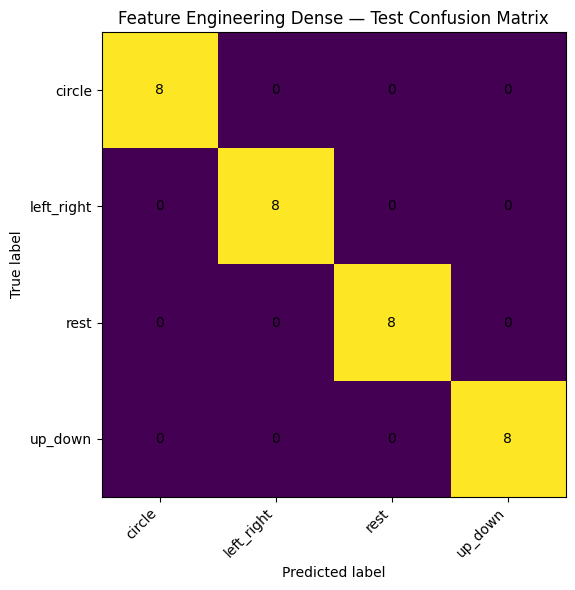

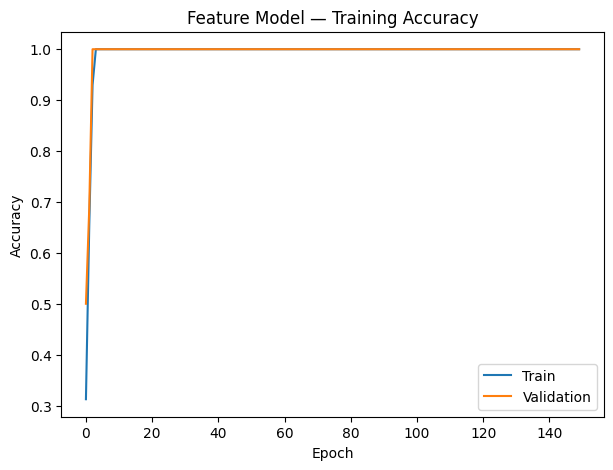

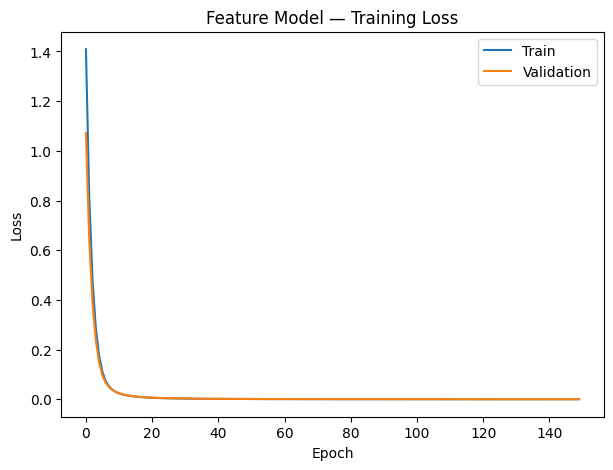

Saved artifact at '/tmp/tmpwxtyojrn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 72), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  133217072489552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217072482640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217072493008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217072482448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217072487632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133217072482256: TensorSpec(shape=(), dtype=tf.resource, name=None)

MODEL SIZE
------------------------------------------------------------
Keras model : 40.66 KB
TFLite FP32 : 7.45 KB

APPROXIMATE MODEL MAC COUNT
------------------------------------------------------------
Dense1 MACs : 1,152
Dense2 MACs : 128
Dense3 MACs : 32
TOTAL MACs  : 1,312
NOTE: feature extracti

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



HOST FEATURE EXTRACTION LATENCY
------------------------------------------------------------
0.98795 ms

HOST TOTAL PIPELINE LATENCY
------------------------------------------------------------
0.99024 ms
(feature extraction + classifier)


MODEL 6 — FEATURE ENGINEERING BENCHMARK
Raw input shape          : 128 x 6
Engineered features      : 72
Test samples             : 32
Test accuracy            : 100.00%
Average confidence       : 0.999535
Model parameters         : 1,340
Classifier MACs          : 1,312
TFLite FP32 size         : 7.45 KB
Host feature latency     : 0.98795 ms
Host classifier latency  : 0.00229 ms
Host total pipeline      : 0.99024 ms
Arduino latency          : TO BE MEASURED


FEATURE ENGINEERING vs RAW-DEEP-MODEL BENCHMARK
Model                             Accuracy      Params          MACs     Size KB
-----------------------------------------------------------------------------------------------
Dense Raw FP32                     100.00%      51,428           N/A

In [104]:
# ============================================================
# FEATURE ENGINEERING STUDY — MODEL 6
# Handcrafted Features + Small Dense Classifier
#
# Goal:
# Compare engineered features against raw-data CNN models
# using the SAME fixed 80/10/10 split.
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 70)
print("MODEL 6 — FEATURE ENGINEERING + SMALL DENSE CLASSIFIER")
print("=" * 70)


# ============================================================
# 2. LOAD EXACT SAME FIXED SPLIT
# ============================================================

split_file = "fixed_tinyml_split_80_10_10.npz"

if not os.path.exists(split_file):
    raise FileNotFoundError(
        f"{split_file} not found."
    )

data = np.load(split_file)

X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int32)

X_val = data["X_val"].astype(np.float32)
y_val = data["y_val"].astype(np.int32)

X_test = data["X_test"].astype(np.float32)
y_test = data["y_test"].astype(np.int32)


CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]


print("\nRAW DATASET")
print("-" * 60)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


# ============================================================
# 3. FEATURE EXTRACTION
#
# Per channel:
#
# 1  mean
# 2  std
# 3  min
# 4  max
# 5  range
# 6  RMS
# 7  energy
# 8  mean absolute value
# 9  median
# 10 zero-crossing-like rate around channel mean
#
# 10 features × 6 channels = 60 features
#
# Additional cross-channel magnitude features:
#
# Accelerometer magnitude:
# mean / std / min / max / RMS / energy
#
# Gyroscope magnitude:
# mean / std / min / max / RMS / energy
#
# Total:
# 60 + 12 = 72 features
# ============================================================

def extract_features(window):

    window = np.asarray(
        window,
        dtype=np.float32
    )

    if window.shape != (128, 6):
        raise ValueError(
            f"Unexpected window shape: {window.shape}"
        )


    features = []


    # --------------------------------------------------------
    # Channel-wise statistical features
    # --------------------------------------------------------

    for ch in range(6):

        x = window[:, ch]


        mean_value = np.mean(x)

        std_value = np.std(x)

        min_value = np.min(x)

        max_value = np.max(x)

        range_value = (
            max_value
            -
            min_value
        )

        rms_value = np.sqrt(
            np.mean(
                x ** 2
            )
        )

        energy_value = np.mean(
            x ** 2
        )

        mav_value = np.mean(
            np.abs(x)
        )

        median_value = np.median(x)


        # ----------------------------------------------------
        # Simple temporal-change feature:
        # number of sign changes relative to channel mean
        # ----------------------------------------------------

        centered = (
            x
            -
            mean_value
        )

        signs = np.sign(
            centered
        )

        sign_changes = np.sum(
            signs[1:]
            !=
            signs[:-1]
        )

        sign_change_rate = (
            sign_changes
            /
            (len(x) - 1)
        )


        features.extend([
            mean_value,
            std_value,
            min_value,
            max_value,
            range_value,
            rms_value,
            energy_value,
            mav_value,
            median_value,
            sign_change_rate
        ])


    # ========================================================
    # Accelerometer magnitude
    # ========================================================

    accel = window[:, 0:3]

    accel_mag = np.sqrt(
        np.sum(
            accel ** 2,
            axis=1
        )
    )


    accel_features = [

        np.mean(accel_mag),

        np.std(accel_mag),

        np.min(accel_mag),

        np.max(accel_mag),

        np.sqrt(
            np.mean(
                accel_mag ** 2
            )
        ),

        np.mean(
            accel_mag ** 2
        )

    ]


    # ========================================================
    # Gyroscope magnitude
    # ========================================================

    gyro = window[:, 3:6]

    gyro_mag = np.sqrt(
        np.sum(
            gyro ** 2,
            axis=1
        )
    )


    gyro_features = [

        np.mean(gyro_mag),

        np.std(gyro_mag),

        np.min(gyro_mag),

        np.max(gyro_mag),

        np.sqrt(
            np.mean(
                gyro_mag ** 2
            )
        ),

        np.mean(
            gyro_mag ** 2
        )

    ]


    features.extend(
        accel_features
    )

    features.extend(
        gyro_features
    )


    return np.asarray(
        features,
        dtype=np.float32
    )


# ============================================================
# 4. EXTRACT FEATURES FOR DATASET
# ============================================================

def transform_dataset(X):

    return np.stack(
        [
            extract_features(window)
            for window in X
        ]
    ).astype(np.float32)


print("\nExtracting features...")


F_train = transform_dataset(
    X_train
)

F_val = transform_dataset(
    X_val
)

F_test = transform_dataset(
    X_test
)


print("\nFEATURE DATASET")
print("-" * 60)

print(
    "F_train:",
    F_train.shape
)

print(
    "F_val  :",
    F_val.shape
)

print(
    "F_test :",
    F_test.shape
)


NUM_FEATURES = F_train.shape[1]

print(
    "\nNumber of engineered features:",
    NUM_FEATURES
)


# ============================================================
# 5. FEATURE NORMALIZATION
#
# IMPORTANT:
# Fit ONLY using training features.
# ============================================================

feature_mean = F_train.mean(
    axis=0
).astype(np.float32)

feature_std = F_train.std(
    axis=0
).astype(np.float32)


feature_std = np.where(
    feature_std < 1e-8,
    1.0,
    feature_std
).astype(np.float32)


F_train_n = (
    (F_train - feature_mean)
    /
    feature_std
).astype(np.float32)


F_val_n = (
    (F_val - feature_mean)
    /
    feature_std
).astype(np.float32)


F_test_n = (
    (F_test - feature_mean)
    /
    feature_std
).astype(np.float32)


print("\nFEATURE NORMALIZATION")
print("-" * 60)

print(
    "Training feature mean after scaling:",
    np.mean(F_train_n)
)

print(
    "Training feature std after scaling:",
    np.std(F_train_n)
)


# ============================================================
# 6. BUILD SMALL FEATURE-BASED DENSE MODEL
#
# Input:
# 72 engineered features
#
# Architecture:
# Dense 16
# Dense 8
# Dense 4
# ============================================================

tf.keras.backend.clear_session()


feature_model = keras.Sequential([

    keras.Input(
        shape=(NUM_FEATURES,)
    ),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        8,
        activation="relu"
    ),

    layers.Dense(
        4,
        activation="softmax"
    )

], name="Feature_Engineering_Dense")


feature_model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)


print("\nMODEL ARCHITECTURE")
print("-" * 60)

feature_model.summary()


# ============================================================
# 7. PARAMETERS
# ============================================================

total_params = (
    feature_model.count_params()
)

print(
    "\nTotal parameters:",
    f"{total_params:,}"
)


# ============================================================
# 8. TRAINING
# ============================================================

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )

]


print("\n" + "=" * 70)
print("TRAINING FEATURE-BASED MODEL")
print("=" * 70)


history = feature_model.fit(

    F_train_n,
    y_train,

    validation_data=(
        F_val_n,
        y_val
    ),

    epochs=150,

    batch_size=16,

    callbacks=callbacks,

    verbose=1

)


# ============================================================
# 9. TEST EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("TEST SET EVALUATION")
print("=" * 70)


test_loss, test_accuracy = (
    feature_model.evaluate(
        F_test_n,
        y_test,
        verbose=0
    )
)


print(
    f"\nTest loss     : "
    f"{test_loss:.6f}"
)

print(
    f"Test accuracy : "
    f"{test_accuracy * 100:.2f}%"
)


# ============================================================
# 10. PREDICTIONS
# ============================================================

predictions = (
    feature_model.predict(
        F_test_n,
        verbose=0
    )
)


y_pred = np.argmax(
    predictions,
    axis=1
)


confidence = np.max(
    predictions,
    axis=1
)


average_confidence = (
    np.mean(confidence)
)


print(
    f"Average confidence: "
    f"{average_confidence:.6f}"
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nCONFUSION MATRIX")
print("-" * 60)

print(cm)


# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT")
print("-" * 60)


print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 13. CONFUSION MATRIX PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)


ax.imshow(cm)


ax.set_xticks(
    np.arange(4)
)

ax.set_yticks(
    np.arange(4)
)


ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)


ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)


ax.set_title(
    "Feature Engineering Dense — Test Confusion Matrix"
)


for i in range(4):

    for j in range(4):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()
plt.show()


# ============================================================
# 14. TRAINING CURVES
# ============================================================

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Train"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Feature Model — Training Accuracy"
)

plt.legend()

plt.show()


plt.figure(
    figsize=(7, 5)
)

plt.plot(
    history.history["loss"],
    label="Train"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Feature Model — Training Loss"
)

plt.legend()

plt.show()


# ============================================================
# 15. SAVE MODEL
# ============================================================

keras_filename = (
    "feature_dense.keras"
)

feature_model.save(
    keras_filename
)


# ============================================================
# 16. CONVERT TO FLOAT32 TFLITE
# ============================================================

converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(
        feature_model
    )
)

feature_tflite = (
    converter.convert()
)


tflite_filename = (
    "feature_dense_float32.tflite"
)


with open(
    tflite_filename,
    "wb"
) as f:

    f.write(
        feature_tflite
    )


# ============================================================
# 17. MODEL SIZE
# ============================================================

keras_size = os.path.getsize(
    keras_filename
)

tflite_size = os.path.getsize(
    tflite_filename
)


print("\nMODEL SIZE")
print("-" * 60)

print(
    f"Keras model : "
    f"{keras_size / 1024:.2f} KB"
)

print(
    f"TFLite FP32 : "
    f"{tflite_size / 1024:.2f} KB"
)


# ============================================================
# 18. APPROXIMATE MAC COUNT
#
# Dense 72 -> 16
# Dense 16 -> 8
# Dense 8 -> 4
#
# Feature extraction cost is NOT included here.
# We'll report it separately later.
# ============================================================

dense1_macs = (
    NUM_FEATURES * 16
)

dense2_macs = (
    16 * 8
)

dense3_macs = (
    8 * 4
)


model_macs = (

    dense1_macs
    +
    dense2_macs
    +
    dense3_macs

)


print("\nAPPROXIMATE MODEL MAC COUNT")
print("-" * 60)

print(
    f"Dense1 MACs : "
    f"{dense1_macs:,}"
)

print(
    f"Dense2 MACs : "
    f"{dense2_macs:,}"
)

print(
    f"Dense3 MACs : "
    f"{dense3_macs:,}"
)

print(
    f"TOTAL MACs  : "
    f"{model_macs:,}"
)

print(
    "NOTE: feature extraction computation "
    "is not included in this MAC count."
)


# ============================================================
# 19. HOST TFLITE LATENCY
# ============================================================

interpreter = tf.lite.Interpreter(
    model_path=tflite_filename
)

interpreter.allocate_tensors()


input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)


sample = (
    F_test_n[0:1]
    .astype(np.float32)
)


# Warm-up

for _ in range(10):

    interpreter.set_tensor(
        input_details[0]["index"],
        sample
    )

    interpreter.invoke()


N_RUNS = 1000


start = (
    time.perf_counter()
)


for _ in range(N_RUNS):

    interpreter.set_tensor(
        input_details[0]["index"],
        sample
    )

    interpreter.invoke()


end = (
    time.perf_counter()
)


host_latency_ms = (

    (
        end
        -
        start
    )

    /
    N_RUNS

    *
    1000.0

)


print("\nHOST MODEL-ONLY LATENCY")
print("-" * 60)

print(
    f"{host_latency_ms:.5f} ms / inference"
)

print(
    "NOTE: This excludes feature extraction time."
)


# ============================================================
# 20. MEASURE FEATURE EXTRACTION HOST LATENCY
# ============================================================

N_FEATURE_RUNS = 1000

sample_window = (
    X_test[0]
)


start = (
    time.perf_counter()
)


for _ in range(
    N_FEATURE_RUNS
):

    _ = extract_features(
        sample_window
    )


end = (
    time.perf_counter()
)


feature_latency_ms = (

    (
        end
        -
        start
    )

    /
    N_FEATURE_RUNS

    *
    1000.0

)


total_pipeline_latency_ms = (
    feature_latency_ms
    +
    host_latency_ms
)


print("\nHOST FEATURE EXTRACTION LATENCY")
print("-" * 60)

print(
    f"{feature_latency_ms:.5f} ms"
)


print("\nHOST TOTAL PIPELINE LATENCY")
print("-" * 60)

print(
    f"{total_pipeline_latency_ms:.5f} ms"
)

print(
    "(feature extraction + classifier)"
)


# ============================================================
# 21. SAVE FEATURE SCALER
# ============================================================

np.savez(

    "feature_scaler.npz",

    mean=feature_mean,

    std=feature_std

)


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("MODEL 6 — FEATURE ENGINEERING BENCHMARK")
print("=" * 70)

print(
    f"Raw input shape          : "
    f"128 x 6"
)

print(
    f"Engineered features      : "
    f"{NUM_FEATURES}"
)

print(
    f"Test samples             : "
    f"{len(y_test)}"
)

print(
    f"Test accuracy            : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Average confidence       : "
    f"{average_confidence:.6f}"
)

print(
    f"Model parameters         : "
    f"{total_params:,}"
)

print(
    f"Classifier MACs          : "
    f"{model_macs:,}"
)

print(
    f"TFLite FP32 size         : "
    f"{tflite_size / 1024:.2f} KB"
)

print(
    f"Host feature latency     : "
    f"{feature_latency_ms:.5f} ms"
)

print(
    f"Host classifier latency  : "
    f"{host_latency_ms:.5f} ms"
)

print(
    f"Host total pipeline      : "
    f"{total_pipeline_latency_ms:.5f} ms"
)

print(
    "Arduino latency          : "
    "TO BE MEASURED"
)

print("=" * 70)


# ============================================================
# 23. COMPARE AGAINST DEEP MODELS
# ============================================================

print("\n")
print("=" * 95)
print("FEATURE ENGINEERING vs RAW-DEEP-MODEL BENCHMARK")
print("=" * 95)


print(
    f"{'Model':<30}"
    f"{'Accuracy':>12}"
    f"{'Params':>12}"
    f"{'MACs':>14}"
    f"{'Size KB':>12}"
)

print("-" * 95)


print(
    f"{'Dense Raw FP32':<30}"
    f"{100.0:>11.2f}%"
    f"{51428:>12,}"
    f"{'N/A':>14}"
    f"{203.93:>12.2f}"
)


print(
    f"{'Standard CNN FP32':<30}"
    f"{100.0:>11.2f}%"
    f"{2660:>12,}"
    f"{160320:>14,}"
    f"{15.70:>12.2f}"
)


print(
    f"{'Standard CNN INT8':<30}"
    f"{100.0:>11.2f}%"
    f"{2660:>12,}"
    f"{160320:>14,}"
    f"{10.71:>12.2f}"
)


print(
    f"{'Depthwise CNN FP32':<30}"
    f"{100.0:>11.2f}%"
    f"{1330:>12,}"
    f"{52544:>14,}"
    f"{11.94:>12.2f}"
)


print(
    f"{'Depthwise CNN INT8':<30}"
    f"{100.0:>11.2f}%"
    f"{1330:>12,}"
    f"{52544:>14,}"
    f"{11.30:>12.2f}"
)


print(
    f"{'Feature Dense FP32':<30}"
    f"{test_accuracy*100:>11.2f}%"
    f"{total_params:>12,}"
    f"{model_macs:>14,}"
    f"{tflite_size/1024:>12.2f}"
)


print("=" * 95)

print()
print("MODEL 6 COMPLETE")

MODEL 7 — FEATURE ENGINEERING + DENSE (FULL INT8)

Extracting features...

FEATURE SHAPES
------------------------------------------------------------
F_train: (256, 72)
F_val  : (32, 72)
F_test : (32, 72)
Number of features: 72

MODEL ARCHITECTURE
------------------------------------------------------------


Model: "Feature_Dense_For_INT8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,340 (5.23 KB)

 Trainable params: 1,340 (5.23 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 84: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 93: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 101: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 109: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 117: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 125: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.

Epoch 133: ReduceLROnPlateau reducing learning rate to 7.812500371073838e-06.

Epoch 141: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.

Epoch 149: ReduceLROnPlateau reducing learning rate to 1.9531250927684596e-06.
Restoring model weights from the end of the best epoch: 150.

TRAINING COMPLETE
------------------------------------------------------------
Epochs executed: 150

FLOAT MODEL BEFORE QUANTIZATION
------------------------------------------------------------
Test loss       : 0.000493
Test ac

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


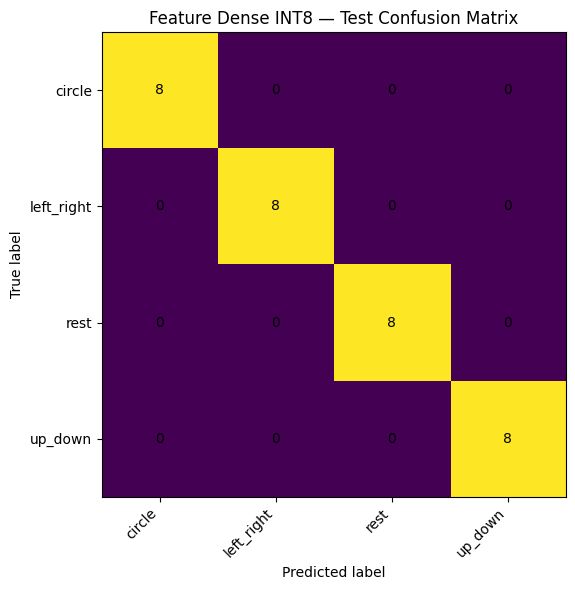


HOST INT8 CLASSIFIER LATENCY
------------------------------------------------------------
Mean   : 0.00261 ms
Median : 0.00230 ms
Min    : 0.00217 ms
Max    : 0.00952 ms

HOST FEATURE EXTRACTION LATENCY
------------------------------------------------------------
1.04228 ms

HOST TOTAL PIPELINE LATENCY
------------------------------------------------------------
1.04489 ms


MODEL 6 FP32 vs MODEL 7 INT8
Metric                            Feature FP32      Feature INT8
----------------------------------------------------------------------
Accuracy                               100.00%           100.00%
Parameters                               1,340             1,340
Classifier MACs                          1,312             1,312
Model size (KB)                           7.45              4.48
----------------------------------------------------------------------

INT8 size reduction: 39.81%
Accuracy drop: 0.00 percentage points


MODEL 7 — FEATURE ENGINEERING INT8 BENCHMARK
Raw window 

In [105]:
# ============================================================
# MODEL 7 — FEATURE ENGINEERING + DENSE (FULL INT8)
# TinyML Feature Engineering Study
# Fixed 80/10/10 split
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


# ============================================================
# 1. REPRODUCIBILITY
# ============================================================

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("=" * 70)
print("MODEL 7 — FEATURE ENGINEERING + DENSE (FULL INT8)")
print("=" * 70)


# ============================================================
# 2. LOAD FIXED SPLIT
# ============================================================

split_file = "fixed_tinyml_split_80_10_10.npz"

if not os.path.exists(split_file):
    raise FileNotFoundError(
        f"{split_file} not found."
    )

data = np.load(split_file)

X_train = data["X_train"].astype(np.float32)
y_train = data["y_train"].astype(np.int32)

X_val = data["X_val"].astype(np.float32)
y_val = data["y_val"].astype(np.int32)

X_test = data["X_test"].astype(np.float32)
y_test = data["y_test"].astype(np.int32)


CLASS_NAMES = [
    "circle",
    "left_right",
    "rest",
    "up_down"
]


# ============================================================
# 3. SAME FEATURE EXTRACTION AS MODEL 6
# ============================================================

def extract_features(window):

    window = np.asarray(
        window,
        dtype=np.float32
    )

    features = []

    for ch in range(6):

        x = window[:, ch]

        mean_value = np.mean(x)
        std_value = np.std(x)
        min_value = np.min(x)
        max_value = np.max(x)

        range_value = (
            max_value
            -
            min_value
        )

        rms_value = np.sqrt(
            np.mean(
                x ** 2
            )
        )

        energy_value = np.mean(
            x ** 2
        )

        mav_value = np.mean(
            np.abs(x)
        )

        median_value = np.median(x)

        centered = (
            x
            -
            mean_value
        )

        signs = np.sign(
            centered
        )

        sign_changes = np.sum(
            signs[1:]
            !=
            signs[:-1]
        )

        sign_change_rate = (
            sign_changes
            /
            (len(x) - 1)
        )

        features.extend([
            mean_value,
            std_value,
            min_value,
            max_value,
            range_value,
            rms_value,
            energy_value,
            mav_value,
            median_value,
            sign_change_rate
        ])


    # Accelerometer magnitude

    accel = window[:, 0:3]

    accel_mag = np.sqrt(
        np.sum(
            accel ** 2,
            axis=1
        )
    )

    features.extend([

        np.mean(accel_mag),

        np.std(accel_mag),

        np.min(accel_mag),

        np.max(accel_mag),

        np.sqrt(
            np.mean(
                accel_mag ** 2
            )
        ),

        np.mean(
            accel_mag ** 2
        )

    ])


    # Gyroscope magnitude

    gyro = window[:, 3:6]

    gyro_mag = np.sqrt(
        np.sum(
            gyro ** 2,
            axis=1
        )
    )

    features.extend([

        np.mean(gyro_mag),

        np.std(gyro_mag),

        np.min(gyro_mag),

        np.max(gyro_mag),

        np.sqrt(
            np.mean(
                gyro_mag ** 2
            )
        ),

        np.mean(
            gyro_mag ** 2
        )

    ])


    return np.asarray(
        features,
        dtype=np.float32
    )


def transform_dataset(X):

    return np.stack(
        [
            extract_features(window)
            for window in X
        ]
    ).astype(np.float32)


# ============================================================
# 4. CREATE FEATURE DATASET
# ============================================================

print("\nExtracting features...")

F_train = transform_dataset(
    X_train
)

F_val = transform_dataset(
    X_val
)

F_test = transform_dataset(
    X_test
)

NUM_FEATURES = F_train.shape[1]


print("\nFEATURE SHAPES")
print("-" * 60)

print(
    "F_train:",
    F_train.shape
)

print(
    "F_val  :",
    F_val.shape
)

print(
    "F_test :",
    F_test.shape
)

print(
    "Number of features:",
    NUM_FEATURES
)


# ============================================================
# 5. TRAIN-ONLY FEATURE NORMALIZATION
# ============================================================

feature_mean = F_train.mean(
    axis=0
).astype(np.float32)

feature_std = F_train.std(
    axis=0
).astype(np.float32)


feature_std = np.where(
    feature_std < 1e-8,
    1.0,
    feature_std
).astype(np.float32)


F_train_n = (
    (F_train - feature_mean)
    /
    feature_std
).astype(np.float32)


F_val_n = (
    (F_val - feature_mean)
    /
    feature_std
).astype(np.float32)


F_test_n = (
    (F_test - feature_mean)
    /
    feature_std
).astype(np.float32)


# ============================================================
# 6. BUILD SAME FEATURE DENSE MODEL AS MODEL 6
# ============================================================

tf.keras.backend.clear_session()


model = keras.Sequential([

    keras.Input(
        shape=(NUM_FEATURES,)
    ),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        8,
        activation="relu"
    ),

    layers.Dense(
        4,
        activation="softmax"
    )

], name="Feature_Dense_For_INT8")


model.compile(

    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)


print("\nMODEL ARCHITECTURE")
print("-" * 60)

model.summary()


# ============================================================
# 7. TRAIN MODEL
# ============================================================

callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )

]


history = model.fit(

    F_train_n,
    y_train,

    validation_data=(
        F_val_n,
        y_val
    ),

    epochs=150,

    batch_size=16,

    callbacks=callbacks,

    verbose=0

)


print("\nTRAINING COMPLETE")
print("-" * 60)

print(
    "Epochs executed:",
    len(history.history["loss"])
)


# ============================================================
# 8. FLOAT TEST BEFORE QUANTIZATION
# ============================================================

float_loss, float_accuracy = model.evaluate(
    F_test_n,
    y_test,
    verbose=0
)


float_predictions = model.predict(
    F_test_n,
    verbose=0
)


float_confidence = np.mean(
    np.max(
        float_predictions,
        axis=1
    )
)


print("\nFLOAT MODEL BEFORE QUANTIZATION")
print("-" * 60)

print(
    f"Test loss       : "
    f"{float_loss:.6f}"
)

print(
    f"Test accuracy   : "
    f"{float_accuracy * 100:.2f}%"
)

print(
    f"Avg confidence  : "
    f"{float_confidence:.6f}"
)


# ============================================================
# 9. REPRESENTATIVE DATASET
# TRAIN FEATURES ONLY
# ============================================================

def representative_dataset():

    for i in range(
        len(F_train_n)
    ):

        sample = F_train_n[
            i:i+1
        ].astype(np.float32)

        yield [sample]


# ============================================================
# 10. FULL INT8 QUANTIZATION
# ============================================================

print("\nCONVERTING TO FULL INT8...")
print("-" * 60)


converter = (
    tf.lite.TFLiteConverter
    .from_keras_model(model)
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

converter.representative_dataset = (
    representative_dataset
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = (
    tf.int8
)

converter.inference_output_type = (
    tf.int8
)


feature_int8_tflite = (
    converter.convert()
)


int8_filename = (
    "feature_dense_int8.tflite"
)


with open(
    int8_filename,
    "wb"
) as f:

    f.write(
        feature_int8_tflite
    )


print(
    "INT8 conversion complete."
)

print(
    "Saved:",
    int8_filename
)


# ============================================================
# 11. MODEL SIZE
# ============================================================

int8_size_bytes = len(
    feature_int8_tflite
)

int8_size_kb = (
    int8_size_bytes
    /
    1024.0
)


print("\nINT8 MODEL SIZE")
print("-" * 60)

print(
    f"Bytes : "
    f"{int8_size_bytes:,}"
)

print(
    f"KB    : "
    f"{int8_size_kb:.2f}"
)


# ============================================================
# 12. LOAD INT8 MODEL
# ============================================================

interpreter = tf.lite.Interpreter(
    model_content=feature_int8_tflite
)

interpreter.allocate_tensors()


input_details = (
    interpreter.get_input_details()
)

output_details = (
    interpreter.get_output_details()
)


print("\nINT8 MODEL INFORMATION")
print("-" * 60)

print(
    "Input shape      :",
    input_details[0]["shape"]
)

print(
    "Input dtype      :",
    input_details[0]["dtype"]
)

print(
    "Output shape     :",
    output_details[0]["shape"]
)

print(
    "Output dtype     :",
    output_details[0]["dtype"]
)


input_scale, input_zero_point = (
    input_details[0]["quantization"]
)

output_scale, output_zero_point = (
    output_details[0]["quantization"]
)


print()
print(
    "Input scale      :",
    input_scale
)

print(
    "Input zero point :",
    input_zero_point
)

print(
    "Output scale     :",
    output_scale
)

print(
    "Output zero point:",
    output_zero_point
)


# ============================================================
# 13. INT8 TEST
# ============================================================

input_index = (
    input_details[0]["index"]
)

output_index = (
    output_details[0]["index"]
)


y_pred = []

confidence_values = []

classifier_latencies_ms = []


# Warm-up

for i in range(
    min(
        10,
        len(F_test_n)
    )
):

    x = F_test_n[
        i:i+1
    ]

    x_q = np.round(
        x
        /
        input_scale
        +
        input_zero_point
    )

    x_q = np.clip(
        x_q,
        -128,
        127
    ).astype(np.int8)


    interpreter.set_tensor(
        input_index,
        x_q
    )

    interpreter.invoke()


# Actual inference

for i in range(
    len(F_test_n)
):

    x = F_test_n[
        i:i+1
    ]


    x_q = np.round(
        x
        /
        input_scale
        +
        input_zero_point
    )

    x_q = np.clip(
        x_q,
        -128,
        127
    ).astype(np.int8)


    interpreter.set_tensor(
        input_index,
        x_q
    )


    start = (
        time.perf_counter()
    )

    interpreter.invoke()

    end = (
        time.perf_counter()
    )


    classifier_latencies_ms.append(

        (
            end
            -
            start
        )

        *
        1000.0

    )


    output_q = interpreter.get_tensor(
        output_index
    )[0]


    output_fp = (

        output_q.astype(
            np.float32
        )

        -
        output_zero_point

    ) * output_scale


    predicted_class = int(
        np.argmax(
            output_fp
        )
    )


    confidence = float(
        np.max(
            output_fp
        )
    )


    y_pred.append(
        predicted_class
    )

    confidence_values.append(
        confidence
    )


y_pred = np.asarray(
    y_pred,
    dtype=np.int32
)


confidence_values = np.asarray(
    confidence_values,
    dtype=np.float32
)


# ============================================================
# 14. ACCURACY
# ============================================================

int8_accuracy = np.mean(
    y_pred
    ==
    y_test
)


avg_confidence = np.mean(
    confidence_values
)


print("\n")
print("=" * 70)
print("INT8 TEST SET EVALUATION")
print("=" * 70)


print(
    f"Test accuracy      : "
    f"{int8_accuracy * 100:.2f}%"
)

print(
    f"Average confidence : "
    f"{avg_confidence:.6f}"
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nCONFUSION MATRIX")
print("-" * 60)

print(cm)


print("\nCLASSIFICATION REPORT")
print("-" * 60)


print(
    classification_report(
        y_test,
        y_pred,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)


# ============================================================
# 16. CONFUSION MATRIX PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(7, 6)
)

ax.imshow(cm)


ax.set_xticks(
    np.arange(4)
)

ax.set_yticks(
    np.arange(4)
)


ax.set_xticklabels(
    CLASS_NAMES,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(
    CLASS_NAMES
)


ax.set_xlabel(
    "Predicted label"
)

ax.set_ylabel(
    "True label"
)


ax.set_title(
    "Feature Dense INT8 — Test Confusion Matrix"
)


for i in range(4):

    for j in range(4):

        ax.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()

plt.show()


# ============================================================
# 17. HOST CLASSIFIER LATENCY
# ============================================================

classifier_latencies_ms = np.asarray(
    classifier_latencies_ms
)


classifier_mean_ms = np.mean(
    classifier_latencies_ms
)

classifier_median_ms = np.median(
    classifier_latencies_ms
)

classifier_min_ms = np.min(
    classifier_latencies_ms
)

classifier_max_ms = np.max(
    classifier_latencies_ms
)


print("\nHOST INT8 CLASSIFIER LATENCY")
print("-" * 60)

print(
    f"Mean   : "
    f"{classifier_mean_ms:.5f} ms"
)

print(
    f"Median : "
    f"{classifier_median_ms:.5f} ms"
)

print(
    f"Min    : "
    f"{classifier_min_ms:.5f} ms"
)

print(
    f"Max    : "
    f"{classifier_max_ms:.5f} ms"
)


# ============================================================
# 18. FEATURE EXTRACTION HOST LATENCY
# ============================================================

N_FEATURE_RUNS = 1000

sample_window = (
    X_test[0]
)


start = (
    time.perf_counter()
)


for _ in range(
    N_FEATURE_RUNS
):

    _ = extract_features(
        sample_window
    )


end = (
    time.perf_counter()
)


feature_latency_ms = (

    (
        end
        -
        start
    )

    /
    N_FEATURE_RUNS

    *
    1000.0

)


total_pipeline_latency_ms = (
    feature_latency_ms
    +
    classifier_mean_ms
)


print("\nHOST FEATURE EXTRACTION LATENCY")
print("-" * 60)

print(
    f"{feature_latency_ms:.5f} ms"
)


print("\nHOST TOTAL PIPELINE LATENCY")
print("-" * 60)

print(
    f"{total_pipeline_latency_ms:.5f} ms"
)


# ============================================================
# 19. PARAMETERS AND MACs
# ============================================================

params = model.count_params()


dense1_macs = (
    NUM_FEATURES
    *
    16
)

dense2_macs = (
    16
    *
    8
)

dense3_macs = (
    8
    *
    4
)


classifier_macs = (

    dense1_macs
    +
    dense2_macs
    +
    dense3_macs

)


# ============================================================
# 20. COMPARE MODEL 6 FP32 vs MODEL 7 INT8
# ============================================================

model6_fp32_size_kb = (
    7.45
)

model6_accuracy = (
    1.00
)

model6_params = (
    1340
)

model6_classifier_macs = (
    1312
)


size_reduction = (

    1.0
    -
    int8_size_kb
    /
    model6_fp32_size_kb

) * 100.0


accuracy_drop = (

    model6_accuracy
    -
    int8_accuracy

) * 100.0


print("\n")
print("=" * 70)
print("MODEL 6 FP32 vs MODEL 7 INT8")
print("=" * 70)


print(
    f"{'Metric':<28}"
    f"{'Feature FP32':>18}"
    f"{'Feature INT8':>18}"
)

print("-" * 70)


print(
    f"{'Accuracy':<28}"
    f"{model6_accuracy*100:>17.2f}%"
    f"{int8_accuracy*100:>17.2f}%"
)


print(
    f"{'Parameters':<28}"
    f"{model6_params:>18,}"
    f"{params:>18,}"
)


print(
    f"{'Classifier MACs':<28}"
    f"{model6_classifier_macs:>18,}"
    f"{classifier_macs:>18,}"
)


print(
    f"{'Model size (KB)':<28}"
    f"{model6_fp32_size_kb:>18.2f}"
    f"{int8_size_kb:>18.2f}"
)


print("-" * 70)


print(
    f"\nINT8 size reduction: "
    f"{size_reduction:.2f}%"
)

print(
    f"Accuracy drop: "
    f"{accuracy_drop:.2f} percentage points"
)


# ============================================================
# 21. SAVE SCALER
# ============================================================

np.savez(

    "feature_dense_int8_scaler.npz",

    mean=feature_mean,

    std=feature_std

)


# ============================================================
# 22. FINAL MODEL 7 SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("MODEL 7 — FEATURE ENGINEERING INT8 BENCHMARK")
print("=" * 70)


print(
    f"Raw window             : "
    f"128 x 6"
)

print(
    f"Engineered features    : "
    f"{NUM_FEATURES}"
)

print(
    f"Test samples           : "
    f"{len(y_test)}"
)

print(
    f"Float accuracy         : "
    f"{float_accuracy * 100:.2f}%"
)

print(
    f"INT8 accuracy          : "
    f"{int8_accuracy * 100:.2f}%"
)

print(
    f"Accuracy drop          : "
    f"{(float_accuracy-int8_accuracy)*100:.2f} percentage points"
)

print(
    f"Average confidence     : "
    f"{avg_confidence:.6f}"
)

print(
    f"Parameters             : "
    f"{params:,}"
)

print(
    f"Classifier MACs        : "
    f"{classifier_macs:,}"
)

print(
    f"TFLite INT8 size       : "
    f"{int8_size_kb:.2f} KB"
)

print(
    f"Host feature latency   : "
    f"{feature_latency_ms:.5f} ms"
)

print(
    f"Host classifier        : "
    f"{classifier_mean_ms:.5f} ms"
)

print(
    f"Host total pipeline    : "
    f"{total_pipeline_latency_ms:.5f} ms"
)

print(
    "Arduino latency        : "
    "TO BE MEASURED"
)

print("=" * 70)


# ============================================================
# 23. FINAL CURRENT PROJECT TABLE
# ============================================================

print("\n")
print("=" * 105)
print("FINAL CURRENT TINYML + FEATURE ENGINEERING BENCHMARK")
print("=" * 105)


print(
    f"{'Model':<30}"
    f"{'Acc.%':>10}"
    f"{'Params':>12}"
    f"{'MACs':>14}"
    f"{'Size KB':>12}"
)

print("-" * 105)


print(
    f"{'Dense Raw FP32':<30}"
    f"{100.00:>10.2f}"
    f"{51428:>12,}"
    f"{'N/A':>14}"
    f"{203.93:>12.2f}"
)


print(
    f"{'Standard CNN FP32':<30}"
    f"{100.00:>10.2f}"
    f"{2660:>12,}"
    f"{160320:>14,}"
    f"{15.70:>12.2f}"
)


print(
    f"{'Standard CNN INT8':<30}"
    f"{100.00:>10.2f}"
    f"{2660:>12,}"
    f"{160320:>14,}"
    f"{10.71:>12.2f}"
)


print(
    f"{'Depthwise CNN FP32':<30}"
    f"{100.00:>10.2f}"
    f"{1330:>12,}"
    f"{52544:>14,}"
    f"{11.94:>12.2f}"
)


print(
    f"{'Depthwise CNN INT8':<30}"
    f"{100.00:>10.2f}"
    f"{1330:>12,}"
    f"{52544:>14,}"
    f"{11.30:>12.2f}"
)


print(
    f"{'Feature Dense FP32':<30}"
    f"{100.00:>10.2f}"
    f"{1340:>12,}"
    f"{1312:>14,}"
    f"{7.45:>12.2f}"
)


print(
    f"{'Feature Dense INT8':<30}"
    f"{int8_accuracy*100:>10.2f}"
    f"{params:>12,}"
    f"{classifier_macs:>14,}"
    f"{int8_size_kb:>12.2f}"
)


print("=" * 105)


print("\nSaved files:")

print(
    "  feature_dense_int8.tflite"
)

print(
    "  feature_dense_int8_scaler.npz"
)

print()

print(
    "MODEL 7 COMPLETE"
)

In [106]:
# ============================================================
# ARDUINO EXPORT — MODEL 7
# Feature Engineering + Dense INT8
#
# Creates:
# 1. feature_model.h
# 2. feature_scaler.h
# ============================================================

import numpy as np
import os


# ============================================================
# 1. CHECK REQUIRED FILES
# ============================================================

MODEL_FILE = "feature_dense_int8.tflite"
SCALER_FILE = "feature_dense_int8_scaler.npz"

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(MODEL_FILE)

if not os.path.exists(SCALER_FILE):
    raise FileNotFoundError(SCALER_FILE)


# ============================================================
# 2. TFLITE -> C HEADER
# ============================================================

with open(MODEL_FILE, "rb") as f:
    model_bytes = f.read()


with open("feature_model.h", "w") as f:

    f.write("#ifndef FEATURE_MODEL_H\n")
    f.write("#define FEATURE_MODEL_H\n\n")

    # Important for TFLite Micro / ARM alignment
    f.write("alignas(16) const unsigned char feature_model[] = {\n")

    for i, byte in enumerate(model_bytes):

        if i % 12 == 0:
            f.write("    ")

        f.write(f"0x{byte:02X}")

        if i != len(model_bytes) - 1:
            f.write(", ")

        if i % 12 == 11:
            f.write("\n")

    if len(model_bytes) % 12 != 0:
        f.write("\n")

    f.write("};\n\n")

    f.write(
        f"const unsigned int feature_model_len = {len(model_bytes)};\n\n"
    )

    f.write("#endif\n")


# ============================================================
# 3. LOAD FEATURE SCALER
# ============================================================

scaler = np.load(SCALER_FILE)

feature_mean = scaler["mean"].astype(np.float32)
feature_std = scaler["std"].astype(np.float32)


print("Mean shape:", feature_mean.shape)
print("Std shape :", feature_std.shape)

assert len(feature_mean) == 72
assert len(feature_std) == 72


# ============================================================
# 4. SCALER -> C HEADER
# ============================================================

with open("feature_scaler.h", "w") as f:

    f.write("#ifndef FEATURE_SCALER_H\n")
    f.write("#define FEATURE_SCALER_H\n\n")

    f.write("const float feature_mean[72] = {\n")

    for i, value in enumerate(feature_mean):

        f.write(f"    {float(value):.10e}f")

        if i != 71:
            f.write(",")

        f.write("\n")

    f.write("};\n\n")


    f.write("const float feature_std[72] = {\n")

    for i, value in enumerate(feature_std):

        f.write(f"    {float(value):.10e}f")

        if i != 71:
            f.write(",")

        f.write("\n")

    f.write("};\n\n")

    f.write("#endif\n")


# ============================================================
# 5. VALIDATION
# ============================================================

print()
print("=" * 55)
print("ARDUINO EXPORT COMPLETE")
print("=" * 55)

print(
    "TFLite bytes       :",
    len(model_bytes)
)

print(
    "Expected           : 4592 bytes approximately"
)

print(
    "Feature mean count :",
    len(feature_mean)
)

print(
    "Feature std count  :",
    len(feature_std)
)

print()
print("Generated:")
print("  feature_model.h")
print("  feature_scaler.h")

print()
print("MODEL 7 READY FOR ARDUINO EXPORT")

Mean shape: (72,)
Std shape : (72,)

ARDUINO EXPORT COMPLETE
TFLite bytes       : 4592
Expected           : 4592 bytes approximately
Feature mean count : 72
Feature std count  : 72

Generated:
  feature_model.h
  feature_scaler.h

MODEL 7 READY FOR ARDUINO EXPORT


In [107]:
# ============================================================
# ARDUINO EXPORT — MODEL 7
# Feature Engineering + Dense INT8
#
# Creates:
# 1. feature_model.h
# 2. feature_scaler.h
# ============================================================

import numpy as np
import os


# ============================================================
# 1. CHECK REQUIRED FILES
# ============================================================

MODEL_FILE = "feature_dense_int8.tflite"
SCALER_FILE = "feature_dense_int8_scaler.npz"


if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(
        f"Missing model file: {MODEL_FILE}"
    )


if not os.path.exists(SCALER_FILE):
    raise FileNotFoundError(
        f"Missing scaler file: {SCALER_FILE}"
    )


print("=" * 60)
print("ARDUINO EXPORT — MODEL 7")
print("=" * 60)

print("\nRequired files found:")
print("  ", MODEL_FILE)
print("  ", SCALER_FILE)


# ============================================================
# 2. TFLITE -> C HEADER
# ============================================================

with open(MODEL_FILE, "rb") as f:
    model_bytes = f.read()


MODEL_LENGTH = len(model_bytes)


with open(
    "feature_model.h",
    "w",
    encoding="utf-8"
) as f:

    f.write("#ifndef FEATURE_MODEL_H\n")
    f.write("#define FEATURE_MODEL_H\n\n")

    f.write("#include <Arduino.h>\n\n")

    # --------------------------------------------------------
    # 16-byte alignment is important for TFLite Micro on ARM
    # --------------------------------------------------------

    f.write(
        "alignas(16) const unsigned char feature_model[] = {\n"
    )


    for i, byte in enumerate(model_bytes):

        if i % 12 == 0:
            f.write("    ")

        f.write(
            f"0x{byte:02X}"
        )

        if i != MODEL_LENGTH - 1:
            f.write(", ")

        if i % 12 == 11:
            f.write("\n")


    if MODEL_LENGTH % 12 != 0:
        f.write("\n")


    f.write("};\n\n")

    f.write(
        f"const unsigned int feature_model_len = "
        f"{MODEL_LENGTH};\n\n"
    )

    f.write("#endif  // FEATURE_MODEL_H\n")


# ============================================================
# 3. LOAD FEATURE SCALER
# ============================================================

scaler = np.load(
    SCALER_FILE
)


print(
    "\nScaler arrays:",
    scaler.files
)


if "mean" not in scaler.files:
    raise KeyError(
        "Scaler does not contain 'mean'"
    )


if "std" not in scaler.files:
    raise KeyError(
        "Scaler does not contain 'std'"
    )


feature_mean = scaler[
    "mean"
].astype(
    np.float32
).reshape(-1)


feature_std = scaler[
    "std"
].astype(
    np.float32
).reshape(-1)


print(
    "\nMean shape:",
    feature_mean.shape
)

print(
    "Std shape :",
    feature_std.shape
)


# ============================================================
# 4. VALIDATE SCALER
# ============================================================

EXPECTED_FEATURES = 72


if len(feature_mean) != EXPECTED_FEATURES:
    raise RuntimeError(
        f"Expected {EXPECTED_FEATURES} means, "
        f"got {len(feature_mean)}"
    )


if len(feature_std) != EXPECTED_FEATURES:
    raise RuntimeError(
        f"Expected {EXPECTED_FEATURES} std values, "
        f"got {len(feature_std)}"
    )


if not np.all(
    np.isfinite(feature_mean)
):
    raise RuntimeError(
        "feature_mean contains NaN or Inf"
    )


if not np.all(
    np.isfinite(feature_std)
):
    raise RuntimeError(
        "feature_std contains NaN or Inf"
    )


if np.any(
    np.abs(feature_std) < 1e-12
):
    raise RuntimeError(
        "feature_std contains zero or near-zero values"
    )


# ============================================================
# 5. SCALER -> C HEADER
# ============================================================

with open(
    "feature_scaler.h",
    "w",
    encoding="utf-8"
) as f:

    f.write("#ifndef FEATURE_SCALER_H\n")
    f.write("#define FEATURE_SCALER_H\n\n")

    f.write(
        "constexpr int kNumFeatures = 72;\n\n"
    )


    # --------------------------------------------------------
    # FEATURE MEAN
    # --------------------------------------------------------

    f.write(
        "const float feature_mean[kNumFeatures] = {\n"
    )


    for i, value in enumerate(feature_mean):

        f.write(
            f"    {float(value):.10e}f"
        )

        if i != EXPECTED_FEATURES - 1:
            f.write(",")

        f.write("\n")


    f.write("};\n\n")


    # --------------------------------------------------------
    # FEATURE STD
    # --------------------------------------------------------

    f.write(
        "const float feature_std[kNumFeatures] = {\n"
    )


    for i, value in enumerate(feature_std):

        f.write(
            f"    {float(value):.10e}f"
        )

        if i != EXPECTED_FEATURES - 1:
            f.write(",")

        f.write("\n")


    f.write("};\n\n")

    f.write(
        "#endif  // FEATURE_SCALER_H\n"
    )


# ============================================================
# 6. OPTIONAL: READ MODEL QUANTIZATION INFORMATION
# ============================================================

import tensorflow as tf


interpreter = tf.lite.Interpreter(
    model_path=MODEL_FILE
)

interpreter.allocate_tensors()


input_details = (
    interpreter.get_input_details()[0]
)

output_details = (
    interpreter.get_output_details()[0]
)


input_scale, input_zero_point = (
    input_details["quantization"]
)

output_scale, output_zero_point = (
    output_details["quantization"]
)


print()
print("=" * 60)
print("TFLITE MODEL INFORMATION")
print("=" * 60)

print(
    "Input shape       :",
    input_details["shape"]
)

print(
    "Input dtype       :",
    input_details["dtype"]
)

print(
    "Input scale       :",
    input_scale
)

print(
    "Input zero point  :",
    input_zero_point
)

print()

print(
    "Output shape      :",
    output_details["shape"]
)

print(
    "Output dtype      :",
    output_details["dtype"]
)

print(
    "Output scale      :",
    output_scale
)

print(
    "Output zero point :",
    output_zero_point
)


# ============================================================
# 7. FINAL VALIDATION
# ============================================================

print()
print("=" * 60)
print("ARDUINO EXPORT COMPLETE")
print("=" * 60)

print(
    "TFLite bytes        :",
    MODEL_LENGTH
)

print(
    "Expected from Model 7: ~4592 bytes"
)

print(
    "Feature mean count  :",
    len(feature_mean)
)

print(
    "Feature std count   :",
    len(feature_std)
)

print(
    "Feature model align : 16 bytes"
)

print()
print("Generated files:")

print(
    "  feature_model.h"
)

print(
    "  feature_scaler.h"
)

print()
print(
    "MODEL 7 READY FOR ARDUINO"
)

ARDUINO EXPORT — MODEL 7

Required files found:
   feature_dense_int8.tflite
   feature_dense_int8_scaler.npz

Scaler arrays: ['mean', 'std']

Mean shape: (72,)
Std shape : (72,)

TFLITE MODEL INFORMATION
Input shape       : [ 1 72]
Input dtype       : <class 'numpy.int8'>
Input scale       : 0.033259063959121704
Input zero point  : -11

Output shape      : [1 4]
Output dtype      : <class 'numpy.int8'>
Output scale      : 0.00390625
Output zero point : -128

ARDUINO EXPORT COMPLETE
TFLite bytes        : 4592
Expected from Model 7: ~4592 bytes
Feature mean count  : 72
Feature std count   : 72
Feature model align : 16 bytes

Generated files:
  feature_model.h
  feature_scaler.h

MODEL 7 READY FOR ARDUINO


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [108]:
# ============================================================
# EXPORT MODEL 7 FOR ARDUINO
# Feature Dense INT8
#
# Creates:
#   feature_model.h
#   feature_scaler.h
# ============================================================

import numpy as np
import os


# ============================================================
# 1. FILE CHECK
# ============================================================

MODEL_FILE = "feature_dense_int8.tflite"
SCALER_FILE = "feature_dense_int8_scaler.npz"

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(MODEL_FILE)

if not os.path.exists(SCALER_FILE):
    raise FileNotFoundError(SCALER_FILE)


# ============================================================
# 2. EXPORT TFLITE MODEL -> C HEADER
# ============================================================

with open(MODEL_FILE, "rb") as f:
    model_data = f.read()


with open("feature_model.h", "w") as f:

    f.write("#ifndef FEATURE_MODEL_H\n")
    f.write("#define FEATURE_MODEL_H\n\n")

    # Important for Nano / TFLite Micro
    f.write("alignas(16) const unsigned char feature_model[] = {\n")

    for i, byte in enumerate(model_data):

        if i % 12 == 0:
            f.write("    ")

        f.write(f"0x{byte:02x}")

        if i != len(model_data) - 1:
            f.write(", ")

        if i % 12 == 11:
            f.write("\n")

    if len(model_data) % 12 != 0:
        f.write("\n")

    f.write("};\n\n")

    f.write(
        f"const unsigned int feature_model_len = {len(model_data)};\n\n"
    )

    f.write("#endif\n")


# ============================================================
# 3. LOAD FEATURE SCALER
# ============================================================

scaler = np.load(SCALER_FILE)

feature_mean = scaler["mean"].astype(np.float32)
feature_std = scaler["std"].astype(np.float32)


print("Feature mean shape:", feature_mean.shape)
print("Feature std shape :", feature_std.shape)

assert feature_mean.shape == (72,)
assert feature_std.shape == (72,)


# ============================================================
# 4. EXPORT SCALER -> C HEADER
# ============================================================

with open("feature_scaler.h", "w") as f:

    f.write("#ifndef FEATURE_SCALER_H\n")
    f.write("#define FEATURE_SCALER_H\n\n")


    # --------------------------------------------------------
    # Mean
    # --------------------------------------------------------

    f.write("const float feature_mean[72] = {\n")

    for i, value in enumerate(feature_mean):

        if i % 6 == 0:
            f.write("    ")

        f.write(f"{float(value):.10e}f")

        if i != len(feature_mean) - 1:
            f.write(", ")

        if i % 6 == 5:
            f.write("\n")

    if len(feature_mean) % 6 != 0:
        f.write("\n")

    f.write("};\n\n")


    # --------------------------------------------------------
    # Std
    # --------------------------------------------------------

    f.write("const float feature_std[72] = {\n")

    for i, value in enumerate(feature_std):

        if i % 6 == 0:
            f.write("    ")

        f.write(f"{float(value):.10e}f")

        if i != len(feature_std) - 1:
            f.write(", ")

        if i % 6 == 5:
            f.write("\n")

    if len(feature_std) % 6 != 0:
        f.write("\n")

    f.write("};\n\n")

    f.write("#endif\n")


# ============================================================
# 5. VERIFY
# ============================================================

print()
print("=" * 60)
print("ARDUINO EXPORT COMPLETE")
print("=" * 60)

print(
    "Model bytes:",
    len(model_data)
)

print(
    "Model KB:",
    len(model_data) / 1024
)

print(
    "Scaler values:",
    len(feature_mean),
    "+",
    len(feature_std)
)

print()
print("Created:")
print("  feature_model.h")
print("  feature_scaler.h")


# ============================================================
# 6. DOWNLOAD
# ============================================================

from google.colab import files

files.download("feature_model.h")
files.download("feature_scaler.h")

Feature mean shape: (72,)
Feature std shape : (72,)

ARDUINO EXPORT COMPLETE
Model bytes: 4592
Model KB: 4.484375
Scaler values: 72 + 72

Created:
  feature_model.h
  feature_scaler.h


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [109]:
# ============================================================
# EXPORT MODEL 3 FOR ARDUINO
# Standard CNN Full INT8
#
# Creates:
#   standard_cnn_model.h
#   standard_cnn_scaler.h
# ============================================================

import numpy as np
import os
import tensorflow as tf


MODEL_FILE = "standard_cnn_int8.tflite"
SCALER_FILE = "standard_cnn_int8_scaler.npz"


# ============================================================
# 1. CHECK FILES
# ============================================================

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(MODEL_FILE)

if not os.path.exists(SCALER_FILE):
    raise FileNotFoundError(SCALER_FILE)


# ============================================================
# 2. VERIFY TFLITE MODEL
# ============================================================

interpreter = tf.lite.Interpreter(
    model_path=MODEL_FILE
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("=" * 60)
print("STANDARD CNN INT8 — MODEL INFORMATION")
print("=" * 60)

print("Input shape       :", input_details["shape"])
print("Input dtype       :", input_details["dtype"])
print("Input scale       :", input_details["quantization"][0])
print("Input zero point  :", input_details["quantization"][1])

print()

print("Output shape      :", output_details["shape"])
print("Output dtype      :", output_details["dtype"])
print("Output scale      :", output_details["quantization"][0])
print("Output zero point :", output_details["quantization"][1])


assert tuple(input_details["shape"]) == (1, 128, 6)
assert input_details["dtype"] == np.int8

assert tuple(output_details["shape"]) == (1, 4)
assert output_details["dtype"] == np.int8


# ============================================================
# 3. MODEL -> C HEADER
# ============================================================

with open(MODEL_FILE, "rb") as f:
    model_data = f.read()

with open(
    "standard_cnn_model.h",
    "w",
    encoding="utf-8"
) as f:

    f.write("#ifndef STANDARD_CNN_MODEL_H\n")
    f.write("#define STANDARD_CNN_MODEL_H\n\n")
    f.write("#include <Arduino.h>\n\n")

    # Required for reliable TFLite Micro access on ARM
    f.write(
        "alignas(16) const unsigned char standard_cnn_model[] = {\n"
    )

    for i, byte in enumerate(model_data):

        if i % 12 == 0:
            f.write("    ")

        f.write(f"0x{byte:02X}")

        if i != len(model_data) - 1:
            f.write(", ")

        if i % 12 == 11:
            f.write("\n")

    if len(model_data) % 12 != 0:
        f.write("\n")

    f.write("};\n\n")

    f.write(
        f"const unsigned int standard_cnn_model_len = "
        f"{len(model_data)};\n\n"
    )

    f.write("#endif\n")


# ============================================================
# 4. SCALER -> C HEADER
# ============================================================

scaler = np.load(SCALER_FILE)

mean = scaler["mean"].astype(np.float32).reshape(-1)
std = scaler["std"].astype(np.float32).reshape(-1)

assert mean.shape == (6,)
assert std.shape == (6,)

if np.any(np.abs(std) < 1e-12):
    raise RuntimeError("Scaler contains zero standard deviation.")


with open(
    "standard_cnn_scaler.h",
    "w",
    encoding="utf-8"
) as f:

    f.write("#ifndef STANDARD_CNN_SCALER_H\n")
    f.write("#define STANDARD_CNN_SCALER_H\n\n")

    f.write("constexpr int kRawChannels = 6;\n\n")

    f.write("const float raw_mean[kRawChannels] = {\n")

    for i, value in enumerate(mean):
        f.write(f"    {float(value):.10e}f")
        if i != 5:
            f.write(",")
        f.write("\n")

    f.write("};\n\n")

    f.write("const float raw_std[kRawChannels] = {\n")

    for i, value in enumerate(std):
        f.write(f"    {float(value):.10e}f")
        if i != 5:
            f.write(",")
        f.write("\n")

    f.write("};\n\n")

    f.write("#endif\n")


# ============================================================
# 5. FINAL CHECK
# ============================================================

print()
print("=" * 60)
print("ARDUINO EXPORT COMPLETE")
print("=" * 60)

print("Model bytes :", len(model_data))
print("Model KB    :", len(model_data) / 1024)

print("\nMean:")
print(mean)

print("\nStd:")
print(std)

print("\nGenerated:")
print("  standard_cnn_model.h")
print("  standard_cnn_scaler.h")


# ============================================================
# 6. DOWNLOAD
# ============================================================

from google.colab import files

files.download("standard_cnn_model.h")
files.download("standard_cnn_scaler.h")

STANDARD CNN INT8 — MODEL INFORMATION
Input shape       : [  1 128   6]
Input dtype       : <class 'numpy.int8'>
Input scale       : 0.04536959156394005
Input zero point  : 14

Output shape      : [1 4]
Output dtype      : <class 'numpy.int8'>
Output scale      : 0.00390625
Output zero point : -128

ARDUINO EXPORT COMPLETE
Model bytes : 10968
Model KB    : 10.7109375

Mean:
[ 1.1208049e-03 -8.2654111e-02 -1.2643310e-01 -1.5734744e+00
  1.5375391e-01  2.9320249e-01]

Std:
[ 0.2609839   0.60880005  0.7468958  19.054401   17.840723   56.507168  ]

Generated:
  standard_cnn_model.h
  standard_cnn_scaler.h


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [110]:
# ============================================================
# EXPORT FINAL MODEL 5 FOR ARDUINO
# Depthwise CNN Full INT8 — Fixed 80/10/10 split
#
# Creates:
#   depthwise_cnn_model.h
#   depthwise_cnn_scaler.h
# ============================================================

import os
import numpy as np
import tensorflow as tf


MODEL_FILE = "depthwise_cnn_int8.tflite"
SCALER_FILE = "depthwise_cnn_int8_scaler.npz"


# ============================================================
# 1. CHECK FILES
# ============================================================

if not os.path.exists(MODEL_FILE):
    raise FileNotFoundError(MODEL_FILE)

if not os.path.exists(SCALER_FILE):
    raise FileNotFoundError(SCALER_FILE)


# ============================================================
# 2. VERIFY MODEL
# ============================================================

interpreter = tf.lite.Interpreter(
    model_path=MODEL_FILE
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("=" * 60)
print("DEPTHWISE CNN INT8 — MODEL INFORMATION")
print("=" * 60)

print("Input shape       :", input_details["shape"])
print("Input dtype       :", input_details["dtype"])
print("Input scale       :", input_details["quantization"][0])
print("Input zero point  :", input_details["quantization"][1])

print()

print("Output shape      :", output_details["shape"])
print("Output dtype      :", output_details["dtype"])
print("Output scale      :", output_details["quantization"][0])
print("Output zero point :", output_details["quantization"][1])

assert tuple(input_details["shape"]) == (1, 128, 6)
assert input_details["dtype"] == np.int8

assert tuple(output_details["shape"]) == (1, 4)
assert output_details["dtype"] == np.int8


# ============================================================
# 3. MODEL -> C HEADER
# ============================================================

with open(MODEL_FILE, "rb") as f:
    model_data = f.read()


with open(
    "depthwise_cnn_model.h",
    "w",
    encoding="utf-8"
) as f:

    f.write("#ifndef DEPTHWISE_CNN_MODEL_H\n")
    f.write("#define DEPTHWISE_CNN_MODEL_H\n\n")
    f.write("#include <Arduino.h>\n\n")

    # Important for TensorFlow Lite Micro on ARM
    f.write(
        "alignas(16) const unsigned char depthwise_cnn_model[] = {\n"
    )

    for i, byte in enumerate(model_data):

        if i % 12 == 0:
            f.write("    ")

        f.write(f"0x{byte:02X}")

        if i != len(model_data) - 1:
            f.write(", ")

        if i % 12 == 11:
            f.write("\n")

    if len(model_data) % 12 != 0:
        f.write("\n")

    f.write("};\n\n")

    f.write(
        f"const unsigned int depthwise_cnn_model_len = "
        f"{len(model_data)};\n\n"
    )

    f.write("#endif\n")


# ============================================================
# 4. SCALER -> C HEADER
# ============================================================

scaler = np.load(SCALER_FILE)

mean = scaler["mean"].astype(np.float32).reshape(-1)
std = scaler["std"].astype(np.float32).reshape(-1)

assert mean.shape == (6,)
assert std.shape == (6,)


with open(
    "depthwise_cnn_scaler.h",
    "w",
    encoding="utf-8"
) as f:

    f.write("#ifndef DEPTHWISE_CNN_SCALER_H\n")
    f.write("#define DEPTHWISE_CNN_SCALER_H\n\n")

    f.write("constexpr int kRawChannels = 6;\n\n")

    f.write("const float raw_mean[kRawChannels] = {\n")

    for i, value in enumerate(mean):
        f.write(f"    {float(value):.10e}f")

        if i != 5:
            f.write(",")

        f.write("\n")

    f.write("};\n\n")

    f.write("const float raw_std[kRawChannels] = {\n")

    for i, value in enumerate(std):
        f.write(f"    {float(value):.10e}f")

        if i != 5:
            f.write(",")

        f.write("\n")

    f.write("};\n\n")

    f.write("#endif\n")


# ============================================================
# 5. FINAL CHECK
# ============================================================

print()
print("=" * 60)
print("ARDUINO EXPORT COMPLETE")
print("=" * 60)

print("Model bytes :", len(model_data))
print("Model KB    :", len(model_data) / 1024)

print("\nMean:")
print(mean)

print("\nStd:")
print(std)

print("\nGenerated:")
print("  depthwise_cnn_model.h")
print("  depthwise_cnn_scaler.h")


# ============================================================
# 6. DOWNLOAD
# ============================================================

from google.colab import files

files.download("depthwise_cnn_model.h")
files.download("depthwise_cnn_scaler.h")

DEPTHWISE CNN INT8 — MODEL INFORMATION
Input shape       : [  1 128   6]
Input dtype       : <class 'numpy.int8'>
Input scale       : 0.04536959156394005
Input zero point  : 14

Output shape      : [1 4]
Output dtype      : <class 'numpy.int8'>
Output scale      : 0.00390625
Output zero point : -128

ARDUINO EXPORT COMPLETE
Model bytes : 11576
Model KB    : 11.3046875

Mean:
[ 1.1208049e-03 -8.2654111e-02 -1.2643310e-01 -1.5734744e+00
  1.5375391e-01  2.9320249e-01]

Std:
[ 0.2609839   0.60880005  0.7468958  19.054401   17.840723   56.507168  ]

Generated:
  depthwise_cnn_model.h
  depthwise_cnn_scaler.h


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>